# Applied AI in Business
## AI-Powered Customer Segmentation and Marketing Strategy

**Institution:** SSBM Geneva  
**Program:** Master of Business Administration (MBA)  
**Course:** Applied AI in Business  

**Student:** Dave Jesus Dalcin da Anunciação  
**Student ID:** 93315  

---

### Project Overview

**Dataset:** Online Retail – UCI Machine Learning Repository  
**Data Preparation & AI:** Python / Jupyter  
**Analytical Approach:** RFM Customer Segmentation and Unsupervised Machine Learning
**Decision Support System:** Google Data Studio
**Interactive Dashboard:** [Open the Google Data Studio Dashboard](https://datastudio.google.com/reporting/324f4900-d9ae-4bcd-a2e3-67e738de0c4f/page/K105F)

### Project Objective

This is the Final Assignment for the Applied AI in Business course. The objective is to develop an AI-powered decision support system that identifies commercially meaningful customer segments and supports targeted marketing decisions for an online retailer.

# 1. Data Loading and Initial Inspection

This section imports the libraries required for the initial analysis and loads the original UCI Online Retail dataset. The raw dataset is preserved without modification to ensure that all subsequent data preparation steps remain reproducible.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from matplotlib.ticker import FuncFormatter
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
data_path = Path("../data/Online-Retail.xlsx")

print(f"Dataset path: {data_path}")
print(f"File exists: {data_path.exists()}")

Dataset path: ../data/Online-Retail.xlsx
File exists: True


In [3]:
df_raw = pd.read_excel(data_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [4]:
rows, columns = df_raw.shape

print(f"Number of rows: {rows:,}")
print(f"Number of columns: {columns}")

Number of rows: 541,909
Number of columns: 8


In [5]:
df_raw.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# 2. Data Quality Assessment

Before preparing the data for customer segmentation, the quality and structure of the raw dataset are assessed. This includes data types, missing values, duplicate records, cancellations, and potentially invalid transaction values.

No records are removed at this stage. The purpose of this assessment is to identify data quality issues and define transparent and reproducible cleaning rules before the AI analysis.

## 2.1 Data Types and Completeness

In [6]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


## 2.2 Missing Values

In [7]:
missing_values = pd.DataFrame({
    "Missing Values": df_raw.isnull().sum(),
    "Missing Percentage": (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})

missing_values

,Missing Values,Missing Percentage
InvoiceNo,0,0.00
StockCode,0,0.00
Description,1454,0.27
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
CustomerID,135080,24.93
Country,0,0.00


## 2.3 Duplicate Records

In [8]:
duplicate_count = df_raw.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df_raw)) * 100

print(f"Exact duplicate rows: {duplicate_count:,}")
print(f"Percentage of dataset: {duplicate_percentage:.2f}%")

Exact duplicate rows: 5,268
Percentage of dataset: 0.97%


## 2.4 Cancellation Transactions

In [9]:
cancellation_mask = df_raw["InvoiceNo"].astype(str).str.startswith("C")

cancellation_count = cancellation_mask.sum()
cancellation_percentage = (cancellation_count / len(df_raw)) * 100

print(f"Cancellation records: {cancellation_count:,}")
print(f"Percentage of dataset: {cancellation_percentage:.2f}%")

Cancellation records: 9,288
Percentage of dataset: 1.71%


## 2.5 Potentially Invalid Transaction Values

In [10]:
non_positive_quantity = (df_raw["Quantity"] <= 0).sum()
non_positive_price = (df_raw["UnitPrice"] <= 0).sum()

print(f"Records with Quantity <= 0: {non_positive_quantity:,}")
print(f"Records with UnitPrice <= 0: {non_positive_price:,}")

Records with Quantity <= 0: 10,624
Records with UnitPrice <= 0: 2,517


## 2.6 Numerical Data Summary

The numerical variables are examined to identify their ranges, distributions, and potentially unusual values before defining any cleaning or outlier treatment rules.

In [11]:
df_raw[["Quantity", "UnitPrice"]].describe()

,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


## 2.7 Transaction Date Range

In [12]:
print(f"Earliest transaction: {df_raw['InvoiceDate'].min()}")
print(f"Latest transaction: {df_raw['InvoiceDate'].max()}")
print(f"Time span: {(df_raw['InvoiceDate'].max() - df_raw['InvoiceDate'].min()).days} days")

Earliest transaction: 2010-12-01 08:26:00
Latest transaction: 2011-12-09 12:50:00
Time span: 373 days


## 2.8 Dataset Cardinality

In [13]:
print(f"Unique invoices: {df_raw['InvoiceNo'].nunique():,}")
print(f"Unique products: {df_raw['StockCode'].nunique():,}")
print(f"Unique customers: {df_raw['CustomerID'].nunique():,}")
print(f"Unique countries: {df_raw['Country'].nunique():,}")

Unique invoices: 25,900
Unique products: 4,070
Unique customers: 4,372
Unique countries: 38


## 2.9 Categorical Data Consistency

In [14]:
categorical_columns = ["InvoiceNo", "StockCode", "Description", "Country"]

for column in categorical_columns:
    blank_count = (
        df_raw[column]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )
    
    print(f"{column}: {blank_count:,} blank values")

InvoiceNo: 0 blank values
StockCode: 0 blank values
Description: 1,454 blank values
Country: 0 blank values


# 3. Data Quality Issue Investigation

The issues identified during the initial data quality assessment are investigated before any records are removed. The objective is to distinguish genuine data quality problems from legitimate business events, such as cancellations, returns, adjustments, or high-value transactions.

This investigation provides the basis for transparent and reproducible data cleaning rules.

## 3.1 Missing Customer Identification

Customer identification is essential for customer-level segmentation because transactions without a CustomerID cannot be reliably associated with an individual customer.

Before defining any cleaning rule, records with missing CustomerID are investigated to assess the scale of the issue, the number of affected invoices, transaction characteristics, financial relevance, potential recoverability of customer identity, and geographic distribution. A sample of unidentified transactions is also inspected at record level to better understand their underlying characteristics.

The purpose of this investigation is to determine whether these records can be reliably used for customer-level modelling or whether their inclusion would require unsupported assumptions about customer identity.

### 3.1.1 Scale of Missing Customer Identification

The number and proportion of transaction records without a CustomerID are quantified to assess the extent of missing customer identification.

In [15]:
missing_customer_df = df_raw[df_raw["CustomerID"].isna()].copy()

missing_customer_count = len(missing_customer_df)
missing_customer_percentage = missing_customer_count / len(df_raw) * 100

print(f"Records without CustomerID: {missing_customer_count:,}")
print(f"Percentage of raw dataset: {missing_customer_percentage:.2f}%")

Records without CustomerID: 135,080
Percentage of raw dataset: 24.93%


### 3.1.2 Affected Invoices

The number of unique invoices associated with missing CustomerID records is examined to distinguish transaction-line volume from the number of affected orders.

In [16]:
missing_customer_invoices = missing_customer_df["InvoiceNo"].nunique()

total_invoices = df_raw["InvoiceNo"].nunique()

missing_invoice_percentage = (
    missing_customer_invoices / total_invoices * 100
)

print(f"Unique invoices without CustomerID: {missing_customer_invoices:,}")
print(f"Total unique invoices: {total_invoices:,}")
print(f"Percentage of invoices affected: {missing_invoice_percentage:.2f}%")

Unique invoices without CustomerID: 3,710
Total unique invoices: 25,900
Percentage of invoices affected: 14.32%


### 3.1.3 Transaction Characteristics

Transactions without CustomerID are examined to determine whether they predominantly represent purchases, cancellations, or negative-quantity transactions.

In [17]:
missing_customer_cancellations = (
    missing_customer_df["InvoiceNo"]
    .astype(str)
    .str.startswith("C")
    .sum()
)

missing_customer_positive_quantity = (
    missing_customer_df["Quantity"] > 0
).sum()

missing_customer_negative_quantity = (
    missing_customer_df["Quantity"] < 0
).sum()

missing_customer_zero_quantity = (
    missing_customer_df["Quantity"] == 0
).sum()

print(f"Cancellation records without CustomerID: {missing_customer_cancellations:,}")
print(f"Positive Quantity records: {missing_customer_positive_quantity:,}")
print(f"Negative Quantity records: {missing_customer_negative_quantity:,}")
print(f"Zero Quantity records: {missing_customer_zero_quantity:,}")

Cancellation records without CustomerID: 383
Positive Quantity records: 133,361
Negative Quantity records: 1,719
Zero Quantity records: 0


### 3.1.4 Financial Relevance

The positive transaction value associated with unidentified customers is estimated to assess the commercial relevance of records that cannot be used for individual customer segmentation.

Only records with positive Quantity and UnitPrice are considered in this calculation to avoid mixing valid purchase value with cancellations, returns, or non-positive price records.

In [18]:
missing_customer_df["Revenue"] = (
    missing_customer_df["Quantity"] *
    missing_customer_df["UnitPrice"]
)

positive_missing_customer = missing_customer_df[
    (missing_customer_df["Quantity"] > 0) &
    (missing_customer_df["UnitPrice"] > 0)
].copy()

missing_customer_positive_revenue = (
    positive_missing_customer["Revenue"].sum()
)

print(
    f"Positive transaction value without CustomerID: "
    f"£{missing_customer_positive_revenue:,.2f}"
)

Positive transaction value without CustomerID: £1,755,276.64


### 3.1.5 Customer ID Recoverability

Invoices are examined to determine whether unidentified transaction lines coexist with identified customer records within the same invoice.

If both identified and unidentified records exist within the same invoice, customer identity may potentially be recoverable. If not, assigning a CustomerID would require assumptions or imputation that cannot be directly supported by the transaction data.

In [19]:
invoice_customer_status = (
    df_raw.groupby("InvoiceNo")["CustomerID"]
    .agg(
        total_rows="size",
        identified_rows=lambda x: x.notna().sum(),
        missing_rows=lambda x: x.isna().sum()
    )
)

mixed_customer_invoices = invoice_customer_status[
    (invoice_customer_status["identified_rows"] > 0) &
    (invoice_customer_status["missing_rows"] > 0)
]

print(
    f"Invoices containing both identified and unidentified customer records: "
    f"{len(mixed_customer_invoices):,}"
)

Invoices containing both identified and unidentified customer records: 0


### 3.1.6 Record-Level Inspection

A sample of transactions without CustomerID is inspected to identify recurring transaction patterns, product descriptions, or administrative records that may help explain the missing customer identification.

In [20]:
missing_customer_df[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "CustomerID",
        "Country"
    ]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1447,536544,21790,VINTAGE SNAP CARDS,9,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1448,536544,21791,VINTAGE HEADS AND TAILS CARD GAME,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1449,536544,21801,CHRISTMAS TREE DECORATION WITH BELL,10,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1450,536544,21802,CHRISTMAS TREE HEART DECORATION,9,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1451,536544,21803,CHRISTMAS TREE STAR DECORATION,11,2010-12-01 14:32:00,0.43,NaN,United Kingdom


### 3.1.7 Geographic Distribution

The geographic distribution of transactions without CustomerID is examined to determine whether missing customer identification is concentrated in specific markets.

In [21]:
missing_customer_country = (
    missing_customer_df["Country"]
    .value_counts()
    .head(10)
    .to_frame(name="Records")
)

missing_customer_country["Percentage"] = (
    missing_customer_country["Records"]
    / len(missing_customer_df)
    * 100
).round(2)

missing_customer_country

,Records,Percentage
Country,,
United Kingdom,133600,98.90
EIRE,711,0.53
Hong Kong,288,0.21
Unspecified,202,0.15
Switzerland,125,0.09
France,66,0.05
Israel,47,0.03
Portugal,39,0.03
Bahrain,2,0.00


### 3.1.8 Investigation Finding

Missing customer identification affects 135,080 transaction records (24.93% of the raw dataset) across 3,710 invoices. Most of these records represent positive-quantity transactions, with approximately £1.76 million in positive transaction value, indicating that missing CustomerID does not necessarily represent invalid commercial activity.

However, no invoices were found containing both identified and unidentified customer records. Therefore, customer identity cannot be reliably recovered from other transaction lines within the same invoice. Assigning CustomerIDs to these records would require unsupported assumptions or imputation.

For customer-level segmentation, transactions without CustomerID should therefore be excluded because they cannot be reliably associated with an individual customer. This exclusion applies specifically to customer-level modelling and should not be interpreted as evidence that the underlying transactions are commercially invalid.

Missing customer identification is also strongly concentrated in the United Kingdom, which accounts for 98.90% of unidentified transaction records. This should be considered when interpreting the representativeness of the final customer segmentation.

## 3.2 Missing Product Descriptions

Product descriptions are useful for interpreting purchasing behaviour and may later support product-level analysis within customer segments. The raw dataset contains records where Description is missing, although a StockCode is still present.

Before defining a treatment rule, these records are investigated to determine their relationship with missing customer identification, their transaction characteristics, and whether product descriptions can be reliably recovered from other records sharing the same StockCode.

### 3.2.1 Scale of Missing Product Descriptions

The number and proportion of transaction records without a product description are quantified to assess the scale of the issue.

In [22]:
missing_description_df = df_raw[df_raw["Description"].isna()].copy()

missing_description_count = len(missing_description_df)
missing_description_percentage = (
    missing_description_count / len(df_raw) * 100
)

print(f"Records without Description: {missing_description_count:,}")
print(f"Percentage of raw dataset: {missing_description_percentage:.2f}%")

Records without Description: 1,454
Percentage of raw dataset: 0.27%


### 3.2.2 Relationship with Missing Customer Identification

Missing product descriptions are compared with missing CustomerID records to determine whether both data quality issues occur within the same transactions.

In [23]:
missing_description_and_customer = (
    df_raw["Description"].isna() &
    df_raw["CustomerID"].isna()
).sum()

missing_description_with_customer = (
    df_raw["Description"].isna() &
    df_raw["CustomerID"].notna()
).sum()

print(
    f"Missing Description and missing CustomerID: "
    f"{missing_description_and_customer:,}"
)

print(
    f"Missing Description but CustomerID available: "
    f"{missing_description_with_customer:,}"
)

Missing Description and missing CustomerID: 1,454
Missing Description but CustomerID available: 0


### 3.2.3 Transaction Characteristics

Transactions without product descriptions are examined to determine whether they represent positive purchases, negative-quantity transactions, cancellations, or records with non-positive prices.

In [24]:
missing_description_positive_quantity = (
    missing_description_df["Quantity"] > 0
).sum()

missing_description_negative_quantity = (
    missing_description_df["Quantity"] < 0
).sum()

missing_description_zero_quantity = (
    missing_description_df["Quantity"] == 0
).sum()

missing_description_cancellations = (
    missing_description_df["InvoiceNo"]
    .astype(str)
    .str.startswith("C")
    .sum()
)

missing_description_non_positive_price = (
    missing_description_df["UnitPrice"] <= 0
).sum()

print(f"Positive Quantity records: {missing_description_positive_quantity:,}")
print(f"Negative Quantity records: {missing_description_negative_quantity:,}")
print(f"Zero Quantity records: {missing_description_zero_quantity:,}")
print(f"Cancellation records: {missing_description_cancellations:,}")
print(
    f"Records with UnitPrice <= 0: "
    f"{missing_description_non_positive_price:,}"
)

Positive Quantity records: 592
Negative Quantity records: 862
Zero Quantity records: 0
Cancellation records: 0
Records with UnitPrice <= 0: 1,454


### 3.2.4 Affected Stock Codes

The number of unique StockCodes associated with missing product descriptions is examined to determine whether the issue is concentrated in a small number of product codes or distributed across many products.

In [25]:
missing_description_stockcodes = (
    missing_description_df["StockCode"].nunique()
)

print(
    f"Unique StockCodes associated with missing Description: "
    f"{missing_description_stockcodes:,}"
)

Unique StockCodes associated with missing Description: 960


### 3.2.5 Description Recoverability

StockCodes associated with missing descriptions are compared with identified product records to determine whether a description is available elsewhere in the dataset.

This assessment helps determine whether missing product descriptions could potentially be recovered using existing product information rather than inferred from unsupported assumptions.

In [26]:
missing_stockcodes = set(
    missing_description_df["StockCode"].unique()
)

described_stockcodes = set(
    df_raw.loc[
        df_raw["Description"].notna(),
        "StockCode"
    ].unique()
)

recoverable_stockcodes = (
    missing_stockcodes & described_stockcodes
)

unrecoverable_stockcodes = (
    missing_stockcodes - described_stockcodes
)

print(
    f"StockCodes with Description available elsewhere: "
    f"{len(recoverable_stockcodes):,}"
)

print(
    f"StockCodes with no Description anywhere in dataset: "
    f"{len(unrecoverable_stockcodes):,}"
)

StockCodes with Description available elsewhere: 848
StockCodes with no Description anywhere in dataset: 112


### 3.2.6 Description Consistency

For potentially recoverable StockCodes, the consistency of available product descriptions is assessed. A StockCode associated with multiple descriptions may not support straightforward description recovery without additional assumptions.

In [27]:
description_consistency = (
    df_raw[
        df_raw["StockCode"].isin(recoverable_stockcodes) &
        df_raw["Description"].notna()
    ]
    .groupby("StockCode")["Description"]
    .nunique()
)

single_description_codes = (
    description_consistency == 1
).sum()

multiple_description_codes = (
    description_consistency > 1
).sum()

print(
    f"Recoverable StockCodes with one unique Description: "
    f"{single_description_codes:,}"
)

print(
    f"Recoverable StockCodes with multiple Descriptions: "
    f"{multiple_description_codes:,}"
)

Recoverable StockCodes with one unique Description: 674
Recoverable StockCodes with multiple Descriptions: 174


### 3.2.7 Record-Level Inspection

A sample of records with missing product descriptions is inspected to identify transaction patterns that may help explain why product information is absent.

In [28]:
missing_description_df[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "CustomerID",
        "Country"
    ]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


### 3.2.8 Investigation Finding

Missing product descriptions affect 1,454 records (0.27% of the raw dataset). All of these records also have a missing CustomerID and a non-positive UnitPrice, meaning that none can be directly associated with an identifiable customer or contribute positive transaction value to customer-level purchasing analysis.

Although descriptions are available elsewhere in the dataset for 848 of the 960 affected StockCodes, description recovery is not consistently deterministic. Among these potentially recoverable StockCodes, 674 are associated with a single description, while 174 have multiple descriptions.

Recovering missing descriptions would therefore provide limited analytical value for the customer segmentation objective. Since all affected records already lack CustomerID, they would be excluded from customer-level modelling on the basis of customer identification rather than missing product description alone.

The presence of 862 negative-quantity records without cancellation-coded invoices also indicates that negative quantities require separate investigation before a general transaction cleaning rule is defined.

## 3.3 Cancellations and Negative Quantities

Cancellations and negative quantities require specific investigation because they may represent different types of business events, including cancelled purchases, returns, corrections, or administrative adjustments.

According to the dataset documentation, an InvoiceNo beginning with "C" indicates a cancellation. However, the initial data quality assessment identified more negative-quantity records than cancellation-coded records. The relationship between these conditions is therefore examined before defining any cleaning rule.

The objective is to distinguish completed purchasing activity from transactions that should not contribute to customer purchasing behaviour or monetary value in the subsequent RFM analysis.

### 3.3.1 Scale of Negative Quantities

Negative-quantity transactions are quantified and compared with zero-quantity records to establish the scale of non-positive quantities in the raw dataset.

In [29]:
negative_quantity_df = df_raw[df_raw["Quantity"] < 0].copy()

negative_quantity_count = len(negative_quantity_df)
negative_quantity_percentage = (
    negative_quantity_count / len(df_raw) * 100
)

zero_quantity_count = (df_raw["Quantity"] == 0).sum()

print(f"Records with negative Quantity: {negative_quantity_count:,}")
print(f"Percentage of raw dataset: {negative_quantity_percentage:.2f}%")
print(f"Records with zero Quantity: {zero_quantity_count:,}")

Records with negative Quantity: 10,624
Percentage of raw dataset: 1.96%
Records with zero Quantity: 0


### 3.3.2 Relationship Between Cancellations and Negative Quantities

Cancellation-coded invoices are compared with negative-quantity transactions to determine the degree of overlap between the two conditions and identify negative quantities that are not explicitly recorded as cancellations.

In [30]:
cancellation_mask = (
    df_raw["InvoiceNo"]
    .astype(str)
    .str.startswith("C")
)

negative_quantity_mask = df_raw["Quantity"] < 0

negative_and_cancellation = (
    negative_quantity_mask & cancellation_mask
).sum()

negative_not_cancellation = (
    negative_quantity_mask & ~cancellation_mask
).sum()

cancellation_not_negative = (
    cancellation_mask & ~negative_quantity_mask
).sum()

print(
    f"Negative Quantity and cancellation-coded: "
    f"{negative_and_cancellation:,}"
)

print(
    f"Negative Quantity but not cancellation-coded: "
    f"{negative_not_cancellation:,}"
)

print(
    f"Cancellation-coded but not negative Quantity: "
    f"{cancellation_not_negative:,}"
)

Negative Quantity and cancellation-coded: 9,288
Negative Quantity but not cancellation-coded: 1,336
Cancellation-coded but not negative Quantity: 0


### 3.3.3 Customer Identification

Negative-quantity transactions are compared by customer identification status to determine whether transactions not explicitly marked as cancellations are concentrated among records without CustomerID.

In [31]:
negative_with_customer = (
    negative_quantity_mask &
    df_raw["CustomerID"].notna()
).sum()

negative_without_customer = (
    negative_quantity_mask &
    df_raw["CustomerID"].isna()
).sum()

negative_not_cancellation_with_customer = (
    negative_quantity_mask &
    ~cancellation_mask &
    df_raw["CustomerID"].notna()
).sum()

negative_not_cancellation_without_customer = (
    negative_quantity_mask &
    ~cancellation_mask &
    df_raw["CustomerID"].isna()
).sum()

print(f"Negative Quantity with CustomerID: {negative_with_customer:,}")
print(f"Negative Quantity without CustomerID: {negative_without_customer:,}")

print(
    f"Negative, not cancellation-coded, with CustomerID: "
    f"{negative_not_cancellation_with_customer:,}"
)

print(
    f"Negative, not cancellation-coded, without CustomerID: "
    f"{negative_not_cancellation_without_customer:,}"
)

Negative Quantity with CustomerID: 8,905
Negative Quantity without CustomerID: 1,719
Negative, not cancellation-coded, with CustomerID: 0
Negative, not cancellation-coded, without CustomerID: 1,336


### 3.3.4 Price Characteristics

Unit prices associated with negative-quantity transactions are examined to determine whether cancellation-coded and non-cancellation negative transactions represent financially valued events or zero-value adjustments.

In [32]:
# Identify all negative-quantity transactions
negative_quantity_mask = df_raw["Quantity"] < 0

# Price characteristics of all negative-quantity transactions
negative_positive_price = (
    negative_quantity_mask &
    (df_raw["UnitPrice"] > 0)
).sum()

negative_zero_price = (
    negative_quantity_mask &
    (df_raw["UnitPrice"] == 0)
).sum()

negative_negative_price = (
    negative_quantity_mask &
    (df_raw["UnitPrice"] < 0)
).sum()

print("Price characteristics of all negative-quantity transactions:")
print(f"UnitPrice > 0: {negative_positive_price:,}")
print(f"UnitPrice = 0: {negative_zero_price:,}")
print(f"UnitPrice < 0: {negative_negative_price:,}")

print()

# Create a dataset containing negative quantities
# that are not associated with cancellation-coded invoices
negative_not_cancellation_df = df_raw[
    negative_quantity_mask &
    ~cancellation_mask
].copy()

# Price characteristics of negative quantities without cancellation code
negative_not_cancellation_positive_price = (
    negative_not_cancellation_df["UnitPrice"] > 0
).sum()

negative_not_cancellation_zero_price = (
    negative_not_cancellation_df["UnitPrice"] == 0
).sum()

negative_not_cancellation_negative_price = (
    negative_not_cancellation_df["UnitPrice"] < 0
).sum()

print("Price characteristics of negative quantities without cancellation code:")
print(f"UnitPrice > 0: {negative_not_cancellation_positive_price:,}")
print(f"UnitPrice = 0: {negative_not_cancellation_zero_price:,}")
print(f"UnitPrice < 0: {negative_not_cancellation_negative_price:,}")

Price characteristics of all negative-quantity transactions:
UnitPrice > 0: 9,288
UnitPrice = 0: 1,336
UnitPrice < 0: 0

Price characteristics of negative quantities without cancellation code:
UnitPrice > 0: 0
UnitPrice = 0: 1,336
UnitPrice < 0: 0


### 3.3.5 Record-Level Inspection of Non-Cancellation Negative Quantities

Negative-quantity transactions without a cancellation-coded InvoiceNo are inspected at record level to identify recurring descriptions, pricing patterns, or other characteristics that may explain their business meaning.

In [33]:
negative_not_cancellation_df[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "CustomerID",
        "Country"
    ]
].head(30)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7192,537000,21414,NaN,-22,2010-12-03 15:32:00,0.0,NaN,United Kingdom
7193,537001,21653,NaN,-6,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7195,537003,85126,NaN,-2,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7196,537004,21814,NaN,-30,2010-12-03 15:34:00,0.0,NaN,United Kingdom
7197,537005,21692,NaN,-70,2010-12-03 15:35:00,0.0,NaN,United Kingdom


### 3.3.6 Common Descriptions in Non-Cancellation Negative Transactions

The most frequent descriptions among negative-quantity transactions without a cancellation code are examined to identify recurring operational or administrative patterns.

In [34]:
negative_not_cancellation_df["Description"].value_counts(
    dropna=False
).head(20)

Description
NaN                           862
check                         120
damages                        45
damaged                        42
?                              41
sold as set on dotcom          20
Damaged                        14
thrown away                     9
Unsaleable, destroyed.          9
??                              7
damages?                        5
wet damaged                     5
ebay                            5
smashed                         4
missing                         3
CHECK                           3
wet pallet                      3
Dotcom sales                    2
reverse 21/5/10 adjustment      2
counted                         2
Name: count, dtype: int64

### 3.3.7 Financial Impact

The transaction value associated with negative quantities is examined separately for cancellation-coded and non-cancellation records. This helps assess whether these events materially affect revenue calculations and supports the definition of an appropriate treatment for customer-level monetary analysis.

In [35]:
negative_quantity_df["TransactionValue"] = (
    negative_quantity_df["Quantity"] *
    negative_quantity_df["UnitPrice"]
)

cancellation_negative_value = (
    negative_quantity_df[
        negative_quantity_df["InvoiceNo"]
        .astype(str)
        .str.startswith("C")
    ]["TransactionValue"]
    .sum()
)

non_cancellation_negative_value = (
    negative_quantity_df[
        ~negative_quantity_df["InvoiceNo"]
        .astype(str)
        .str.startswith("C")
    ]["TransactionValue"]
    .sum()
)

print(
    f"Transaction value of cancellation-coded negative quantities: "
    f"£{cancellation_negative_value:,.2f}"
)

print(
    f"Transaction value of non-cancellation negative quantities: "
    f"£{non_cancellation_negative_value:,.2f}"
)

Transaction value of cancellation-coded negative quantities: £-896,812.49
Transaction value of non-cancellation negative quantities: £0.00


### 3.3.8 Investigation Finding

The investigation identified 10,624 negative-quantity records (1.96% of the raw dataset), which can be separated into two distinct groups.

A total of 9,288 records are associated with cancellation-coded invoices. All of these records have negative quantities and positive UnitPrice values, representing approximately £896,812 in negative transaction value. This pattern is consistent with the dataset definition of InvoiceNo values beginning with "C" as cancellations.

The remaining 1,336 negative-quantity records are not cancellation-coded. All have a UnitPrice of zero and a missing CustomerID, resulting in no direct transaction value. Their most frequent descriptions include terms such as "check", "damages", "damaged", "thrown away", "Unsaleable, destroyed.", "missing", and other adjustment-related descriptions. These characteristics are consistent with operational or inventory adjustments rather than completed customer purchases.

For customer-level RFM analysis, neither group should be treated as completed purchasing activity. Cancellation-coded transactions represent reversed or cancelled commercial activity, while the non-cancellation negative-quantity records do not represent identifiable, positively valued customer purchases. Both groups should therefore be excluded when constructing the transaction base used for customer segmentation.

## 3.4 Non-Positive Unit Prices

UnitPrice directly affects the monetary value of each transaction and is therefore particularly important for the subsequent RFM analysis. Transactions with zero or negative prices cannot be interpreted in the same way as standard positively priced purchases.

The initial data quality assessment identified records with non-positive UnitPrice values. Some have already been associated with missing customer identification and operational adjustments, but the complete population requires further investigation.

The objective is to determine whether non-positive prices represent operational records, missing pricing information, special commercial transactions, or other events that should not contribute to customer-level monetary analysis.

### 3.4.1 Scale of Non-Positive Unit Prices

Non-positive UnitPrice records are quantified and separated into zero-price and negative-price transactions to establish the scale and nature of the pricing issue.

In [36]:
non_positive_price_df = df_raw[
    df_raw["UnitPrice"] <= 0
].copy()

non_positive_price_count = len(non_positive_price_df)

non_positive_price_percentage = (
    non_positive_price_count / len(df_raw) * 100
)

zero_price_count = (
    df_raw["UnitPrice"] == 0
).sum()

negative_price_count = (
    df_raw["UnitPrice"] < 0
).sum()

print(f"Records with UnitPrice <= 0: {non_positive_price_count:,}")
print(f"Percentage of raw dataset: {non_positive_price_percentage:.2f}%")
print(f"Records with UnitPrice = 0: {zero_price_count:,}")
print(f"Records with UnitPrice < 0: {negative_price_count:,}")

Records with UnitPrice <= 0: 2,517
Percentage of raw dataset: 0.46%
Records with UnitPrice = 0: 2,515
Records with UnitPrice < 0: 2


### 3.4.2 Customer Identification

Non-positive price records are examined by customer identification status to determine whether they can be associated with individual customers and potentially affect customer-level purchasing behaviour.

In [37]:
non_positive_with_customer = (
    non_positive_price_df["CustomerID"].notna()
).sum()

non_positive_without_customer = (
    non_positive_price_df["CustomerID"].isna()
).sum()

print(
    f"Non-positive UnitPrice records with CustomerID: "
    f"{non_positive_with_customer:,}"
)

print(
    f"Non-positive UnitPrice records without CustomerID: "
    f"{non_positive_without_customer:,}"
)

Non-positive UnitPrice records with CustomerID: 40
Non-positive UnitPrice records without CustomerID: 2,477


### 3.4.3 Quantity Characteristics

Quantity patterns within non-positive price records are examined to distinguish positive-quantity transactions from the negative-quantity operational adjustments identified previously.

In [38]:
non_positive_positive_quantity = (
    non_positive_price_df["Quantity"] > 0
).sum()

non_positive_negative_quantity = (
    non_positive_price_df["Quantity"] < 0
).sum()

non_positive_zero_quantity = (
    non_positive_price_df["Quantity"] == 0
).sum()

print(
    f"Non-positive UnitPrice with positive Quantity: "
    f"{non_positive_positive_quantity:,}"
)

print(
    f"Non-positive UnitPrice with negative Quantity: "
    f"{non_positive_negative_quantity:,}"
)

print(
    f"Non-positive UnitPrice with zero Quantity: "
    f"{non_positive_zero_quantity:,}"
)

Non-positive UnitPrice with positive Quantity: 1,181
Non-positive UnitPrice with negative Quantity: 1,336
Non-positive UnitPrice with zero Quantity: 0


### 3.4.4 Relationship with Previously Identified Data Quality Issues

Non-positive price records are compared with previously identified missing CustomerID, missing Description, and negative-quantity records to determine how much of the pricing issue has already been explained by other data quality patterns.

In [39]:
non_positive_missing_customer = (
    (df_raw["UnitPrice"] <= 0) &
    df_raw["CustomerID"].isna()
).sum()

non_positive_missing_description = (
    (df_raw["UnitPrice"] <= 0) &
    df_raw["Description"].isna()
).sum()

non_positive_negative_quantity = (
    (df_raw["UnitPrice"] <= 0) &
    (df_raw["Quantity"] < 0)
).sum()

non_positive_positive_quantity_with_customer = (
    (df_raw["UnitPrice"] <= 0) &
    (df_raw["Quantity"] > 0) &
    df_raw["CustomerID"].notna()
).sum()

print(
    f"Non-positive price + missing CustomerID: "
    f"{non_positive_missing_customer:,}"
)

print(
    f"Non-positive price + missing Description: "
    f"{non_positive_missing_description:,}"
)

print(
    f"Non-positive price + negative Quantity: "
    f"{non_positive_negative_quantity:,}"
)

print(
    f"Non-positive price + positive Quantity + CustomerID available: "
    f"{non_positive_positive_quantity_with_customer:,}"
)

Non-positive price + missing CustomerID: 2,477
Non-positive price + missing Description: 1,454
Non-positive price + negative Quantity: 1,336
Non-positive price + positive Quantity + CustomerID available: 40


### 3.4.5 Identified Customers with Positive Quantity and Non-Positive Price

Transactions with an identified CustomerID and positive Quantity but a non-positive UnitPrice are isolated for further investigation. These records are particularly relevant because they resemble completed customer transactions but do not contain a positive monetary value.

In [40]:
identified_non_positive_purchase_df = df_raw[
    (df_raw["UnitPrice"] <= 0) &
    (df_raw["Quantity"] > 0) &
    df_raw["CustomerID"].notna()
].copy()

print(
    f"Identified positive-quantity transactions with "
    f"non-positive UnitPrice: "
    f"{len(identified_non_positive_purchase_df):,}"
)

Identified positive-quantity transactions with non-positive UnitPrice: 40


### 3.4.6 Common Descriptions in Identified Non-Positive Price Transactions

The most frequent product descriptions among identified customers with positive quantities and non-positive prices are examined to identify recurring commercial or operational patterns.

In [41]:
identified_non_positive_purchase_df[
    "Description"
].value_counts(dropna=False).head(20)

Description
Manual                                 6
ROUND CAKE TIN VINTAGE GREEN           1
ADVENT CALENDAR GINGHAM SACK           1
REGENCY CAKESTAND 3 TIER               1
PAPER BUNTING RETROSPOT                1
PLASTERS IN TIN SKULLS                 1
ORGANISER WOOD ANTIQUE WHITE           1
FAIRY CAKES NOTEBOOK A6 SIZE           1
CERAMIC BOWL WITH LOVE HEART DESIGN    1
MINI CAKE STAND  HANGING STRAWBERY     1
HEART GARLAND RUSTIC PADDED            1
CHILDS BREAKFAST SET CIRCUS PARADE     1
PARTY BUNTING                          1
SET OF 6 SOLDIER SKITTLES              1
 OVAL WALL MIRROR DIAMANTE             1
JAM MAKING SET WITH JARS               1
SET OF 6 NATIVITY MAGNETS              1
SET OF 2 CERAMIC PAINTED HEARTS        1
SET OF 2 CERAMIC CHRISTMAS REINDEER    1
36 FOIL STAR CAKE CASES                1
Name: count, dtype: int64

### 3.4.7 Invoice and Customer Distribution

The number of unique invoices and customers associated with identified, positive-quantity, non-positive price transactions is examined to determine whether the issue is widespread or concentrated in a limited number of cases.

In [42]:
identified_zero_price_invoices = (
    identified_non_positive_purchase_df["InvoiceNo"].nunique()
)

identified_zero_price_customers = (
    identified_non_positive_purchase_df["CustomerID"].nunique()
)

print(
    f"Unique invoices affected: "
    f"{identified_zero_price_invoices:,}"
)

print(
    f"Unique customers affected: "
    f"{identified_zero_price_customers:,}"
)

Unique invoices affected: 34
Unique customers affected: 31


### 3.4.8 Potential Impact on RFM Analysis

Zero-value transactions may have no direct effect on Monetary value but could still influence Recency or Frequency if treated as completed purchases. Their potential contribution to customer-level transaction counts is therefore assessed before defining the final RFM preparation rule.

In [43]:
total_identified_positive_transactions = df_raw[
    (df_raw["CustomerID"].notna()) &
    (df_raw["Quantity"] > 0)
]["InvoiceNo"].nunique()

zero_price_identified_invoices = (
    identified_non_positive_purchase_df["InvoiceNo"].nunique()
)

zero_price_invoice_percentage = (
    zero_price_identified_invoices /
    total_identified_positive_transactions *
    100
)

print(
    f"Identified positive-quantity invoices: "
    f"{total_identified_positive_transactions:,}"
)

print(
    f"Identified positive-quantity invoices containing "
    f"non-positive price records: "
    f"{zero_price_identified_invoices:,}"
)

print(
    f"Percentage of identified positive-quantity invoices affected: "
    f"{zero_price_invoice_percentage:.2f}%"
)

Identified positive-quantity invoices: 18,536
Identified positive-quantity invoices containing non-positive price records: 34
Percentage of identified positive-quantity invoices affected: 0.18%


### 3.4.9 Negative UnitPrice Investigation

The two records containing a negative UnitPrice are inspected separately because negative pricing differs conceptually from zero-value transactions and may represent financial adjustments rather than standard product purchases.

In [44]:
negative_price_df = df_raw[
    df_raw["UnitPrice"] < 0
].copy()

negative_price_df[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "CustomerID",
        "Country"
    ]
]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


### 3.4.10 Investigation Finding

Non-positive UnitPrice values affect 2,517 records (0.46% of the raw dataset). Most of these records are already associated with other identified data quality or operational patterns: 2,477 have no CustomerID, while 1,336 combine a negative Quantity with a zero UnitPrice and were previously identified as being consistent with operational or inventory adjustments.

Only 40 records combine an identified CustomerID, positive Quantity and a non-positive UnitPrice. These records affect 34 invoices and 31 customers, representing only 0.18% of identified positive-quantity invoices. Their descriptions include both "Manual" entries and standard product descriptions. Although these records may represent free items, promotions, manual adjustments, or other zero-value events, their precise business meaning cannot be established from the available data.

The two records with a negative UnitPrice are explicitly described as "Adjust bad debt". Both have no CustomerID and therefore represent financial adjustments rather than identifiable customer purchases.

For the subsequent RFM analysis, transactions should require a positive UnitPrice. Zero-value transactions provide no positive monetary contribution and their inclusion could influence Frequency or Recency despite not providing clear evidence of a positively valued purchase. Negative-price records represent financial adjustments rather than customer purchasing activity. The exclusion of non-positive prices therefore provides a more consistent transaction base for modelling completed customer purchasing behaviour.

## 3.5 Exact Duplicate Records

Exact duplicate rows require careful investigation in transactional retail data. Although identical records may result from duplicated data entry or data processing, they may also represent legitimate repeated line items within the same invoice.

The dataset does not provide a unique transaction-line identifier that would allow these possibilities to be distinguished directly. Removing duplicate rows without further investigation could therefore alter quantities and transaction values associated with customer purchases.

The objective is to assess the scale, characteristics, and potential financial relevance of exact duplicate records before determining whether deduplication is appropriate for the subsequent customer-level analysis.

### 3.5.1 Scale of Exact Duplicates

Exact duplicate rows are quantified to establish the scale of duplication in the raw dataset. Duplicate rows are defined as records in which all available variables are identical to a preceding record.

In [45]:
duplicate_mask = df_raw.duplicated()

duplicate_count = duplicate_mask.sum()

duplicate_percentage = (
    duplicate_count / len(df_raw) * 100
)

print(f"Exact duplicate rows: {duplicate_count:,}")
print(f"Percentage of raw dataset: {duplicate_percentage:.2f}%")

Exact duplicate rows: 5,268
Percentage of raw dataset: 0.97%


### 3.5.2 Complete Duplicate Groups

All records belonging to duplicate groups, including the first occurrence of each repeated record, are identified to distinguish the number of redundant occurrences from the total number of records involved in duplication.

In [46]:
all_duplicate_mask = df_raw.duplicated(
    keep=False
)

all_duplicate_df = df_raw[
    all_duplicate_mask
].copy()

print(
    f"Records belonging to duplicate groups: "
    f"{len(all_duplicate_df):,}"
)

print(
    f"Duplicate occurrences beyond the first record: "
    f"{duplicate_count:,}"
)

Records belonging to duplicate groups: 10,147
Duplicate occurrences beyond the first record: 5,268


### 3.5.3 Duplicate Group Size

The frequency of repeated identical records is examined to determine whether duplication consists primarily of pairs or includes records repeated multiple times.

In [47]:
duplicate_group_sizes = (
    df_raw
    .groupby(
        list(df_raw.columns),
        dropna=False
    )
    .size()
    .reset_index(name="Occurrences")
)

duplicate_group_sizes = duplicate_group_sizes[
    duplicate_group_sizes["Occurrences"] > 1
].copy()

print(
    f"Number of distinct duplicate groups: "
    f"{len(duplicate_group_sizes):,}"
)

print(
    f"Largest number of identical occurrences: "
    f"{duplicate_group_sizes['Occurrences'].max():,}"
)

duplicate_group_sizes[
    "Occurrences"
].value_counts().sort_index()

Number of distinct duplicate groups: 4,879
Largest number of identical occurrences: 20


Occurrences
2     4588
3      238
4       39
5        5
6        6
8        1
12       1
20       1
Name: count, dtype: int64

### 3.5.4 Customer and Transaction Characteristics

Records belonging to duplicate groups are examined by customer identification, quantity, price, and cancellation status to determine whether duplication is concentrated in completed customer purchases or previously identified operational records.

In [48]:
duplicate_with_customer = (
    all_duplicate_df["CustomerID"].notna()
).sum()

duplicate_without_customer = (
    all_duplicate_df["CustomerID"].isna()
).sum()

duplicate_positive_quantity = (
    all_duplicate_df["Quantity"] > 0
).sum()

duplicate_negative_quantity = (
    all_duplicate_df["Quantity"] < 0
).sum()

duplicate_positive_price = (
    all_duplicate_df["UnitPrice"] > 0
).sum()

duplicate_non_positive_price = (
    all_duplicate_df["UnitPrice"] <= 0
).sum()

duplicate_cancellations = (
    all_duplicate_df["InvoiceNo"]
    .astype(str)
    .str.startswith("C")
    .sum()
)

print(f"Duplicate-group records with CustomerID: {duplicate_with_customer:,}")
print(f"Duplicate-group records without CustomerID: {duplicate_without_customer:,}")
print(f"Duplicate-group records with positive Quantity: {duplicate_positive_quantity:,}")
print(f"Duplicate-group records with negative Quantity: {duplicate_negative_quantity:,}")
print(f"Duplicate-group records with UnitPrice > 0: {duplicate_positive_price:,}")
print(f"Duplicate-group records with UnitPrice <= 0: {duplicate_non_positive_price:,}")
print(f"Cancellation-coded duplicate-group records: {duplicate_cancellations:,}")

Duplicate-group records with CustomerID: 10,062
Duplicate-group records without CustomerID: 85
Duplicate-group records with positive Quantity: 10,078
Duplicate-group records with negative Quantity: 69
Duplicate-group records with UnitPrice > 0: 10,137
Duplicate-group records with UnitPrice <= 0: 10
Cancellation-coded duplicate-group records: 69


### 3.5.5 Duplicate Records Meeting RFM Eligibility Conditions

Duplicate-group records are evaluated against the transaction conditions identified as appropriate for customer-level RFM analysis. This assessment determines whether apparent duplication occurs within transactions that would otherwise be considered valid completed purchases.

In [49]:
rfm_eligible_duplicate_df = all_duplicate_df[
    all_duplicate_df["CustomerID"].notna() &
    (all_duplicate_df["Quantity"] > 0) &
    (all_duplicate_df["UnitPrice"] > 0) &
    ~all_duplicate_df["InvoiceNo"]
        .astype(str)
        .str.startswith("C")
].copy()

print(
    f"Duplicate-group records meeting RFM eligibility conditions: "
    f"{len(rfm_eligible_duplicate_df):,}"
)

print(
    f"Unique invoices affected: "
    f"{rfm_eligible_duplicate_df['InvoiceNo'].nunique():,}"
)

print(
    f"Unique customers affected: "
    f"{rfm_eligible_duplicate_df['CustomerID'].nunique():,}"
)

Duplicate-group records meeting RFM eligibility conditions: 10,001
Unique invoices affected: 1,884
Unique customers affected: 951


### 3.5.6 Record-Level Inspection

A sample of RFM-eligible duplicate groups is inspected to assess whether identical records resemble plausible repeated product entries within customer invoices.

In [50]:
rfm_eligible_duplicate_df[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "CustomerID",
        "Country"
    ]
].sort_values(
    ["InvoiceNo", "StockCode", "InvoiceDate"]
).head(40)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom


### 3.5.7 Largest Duplicate Groups

The largest groups of identical records are inspected to determine whether high-frequency repetition reveals patterns that may help distinguish potential data duplication from plausible transactional behaviour.

In [51]:
duplicate_group_sizes.sort_values(
    "Occurrences",
    ascending=False
).head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Occurrences
207580,555524,22698,PINK REGENCY TEACUP AND SAUCER,1,2011-06-05 11:37:00,2.95,16923.0,United Kingdom,20
207579,555524,22697,GREEN REGENCY TEACUP AND SAUCER,1,2011-06-05 11:37:00,2.95,16923.0,United Kingdom,12
408646,572861,22775,PURPLE DRAWERKNOB ACRYLIC EDWARDIAN,12,2011-10-26 12:46:00,1.25,14102.0,United Kingdom,8
481780,578289,23395,BELLE JARDINIERE CUSHION COVER,1,2011-11-23 14:07:00,3.75,17841.0,United Kingdom,6
57332,541266,21754,HOME BUILDING BLOCK WORD,1,2011-01-16 16:25:00,5.95,15673.0,United Kingdom,6
57333,541266,21755,LOVE BUILDING BLOCK WORD,1,2011-01-16 16:25:00,5.95,15673.0,United Kingdom,6
48190,540524,21756,BATH BUILDING BLOCK WORD,1,2011-01-09 12:53:00,5.95,16735.0,United Kingdom,6
403109,572344,M,Manual,48,2011-10-24 10:43:00,1.50,14607.0,United Kingdom,6
25692,538514,21756,BATH BUILDING BLOCK WORD,1,2010-12-12 14:27:00,5.95,15044.0,United Kingdom,6
9744,537224,70007,HI TEC ALPINE HAND WARMER,1,2010-12-05 16:24:00,1.65,13174.0,United Kingdom,5


### 3.5.8 Potential Financial Impact of Deduplication

The potential monetary impact of removing exact duplicates is estimated for transactions meeting the RFM eligibility conditions. This analysis quantifies how much customer purchase value would be removed if all exact duplicate occurrences beyond the first were treated as redundant records.

In [52]:
rfm_eligible_df_for_duplicate_test = df_raw[
    df_raw["CustomerID"].notna() &
    (df_raw["Quantity"] > 0) &
    (df_raw["UnitPrice"] > 0) &
    ~df_raw["InvoiceNo"]
        .astype(str)
        .str.startswith("C")
].copy()

rfm_eligible_df_for_duplicate_test["TransactionValue"] = (
    rfm_eligible_df_for_duplicate_test["Quantity"] *
    rfm_eligible_df_for_duplicate_test["UnitPrice"]
)

before_dedup_value = (
    rfm_eligible_df_for_duplicate_test["TransactionValue"].sum()
)

after_dedup_df = (
    rfm_eligible_df_for_duplicate_test.drop_duplicates()
)

after_dedup_value = (
    after_dedup_df["TransactionValue"].sum()
)

value_removed = (
    before_dedup_value - after_dedup_value
)

value_removed_percentage = (
    value_removed / before_dedup_value * 100
)

print(
    f"Transaction value before deduplication: "
    f"£{before_dedup_value:,.2f}"
)

print(
    f"Transaction value after deduplication: "
    f"£{after_dedup_value:,.2f}"
)

print(
    f"Transaction value removed: "
    f"£{value_removed:,.2f}"
)

print(
    f"Percentage of transaction value removed: "
    f"{value_removed_percentage:.2f}%"
)

Transaction value before deduplication: £8,911,407.90
Transaction value after deduplication: £8,887,208.89
Transaction value removed: £24,199.01
Percentage of transaction value removed: 0.27%


### 3.5.9 Potential Frequency Impact

The effect of exact-row deduplication on the number of unique customer invoices is assessed. This distinguishes changes in transaction-line volume and monetary value from changes in customer purchase frequency.

In [53]:
invoices_before_dedup = (
    rfm_eligible_df_for_duplicate_test["InvoiceNo"].nunique()
)

invoices_after_dedup = (
    after_dedup_df["InvoiceNo"].nunique()
)

print(
    f"Unique invoices before deduplication: "
    f"{invoices_before_dedup:,}"
)

print(
    f"Unique invoices after deduplication: "
    f"{invoices_after_dedup:,}"
)

print(
    f"Difference in unique invoices: "
    f"{invoices_before_dedup - invoices_after_dedup:,}"
)

Unique invoices before deduplication: 18,532
Unique invoices after deduplication: 18,532
Difference in unique invoices: 0


### 3.5.10 Investigation Finding

The raw dataset contains 5,268 exact duplicate occurrences beyond the first record, representing 0.97% of all transaction rows. In total, 10,147 records belong to duplicate groups, distributed across 4,879 distinct groups. Most duplicate groups contain only two identical records, although a small number contain substantially more repeated occurrences.

Duplication is predominantly observed within transactions that otherwise meet the conditions for customer-level RFM analysis. A total of 10,001 duplicate-group records meet the RFM eligibility conditions, affecting 1,884 invoices and 951 customers.

However, the dataset does not provide a unique transaction-line identifier that would allow technical duplication to be distinguished reliably from legitimate repeated product entries within the same invoice. Consequently, removing exact duplicates would require an assumption that cannot be directly verified from the available data.

A sensitivity assessment shows that exact-row deduplication would reduce eligible transaction value by approximately £24,199, equivalent to 0.27% of total eligible transaction value. It would not change the number of unique invoices, which remains 18,532 before and after deduplication. Therefore, invoice-based Frequency would remain unaffected, while Monetary values could be altered.

Exact duplicate records are therefore retained for the primary analysis. This conservative treatment avoids removing potentially legitimate purchasing activity without sufficient evidence. The potential 0.27% monetary effect is documented as a data limitation and may be considered in sensitivity analysis when interpreting the resulting customer segments.

## 3.6 Extreme Values and Potential Outliers

The initial numerical summary showed a wide range of values for both Quantity and UnitPrice. While some extreme values may indicate unusual transactions or data quality issues, others may simply reflect the purchasing behaviour of wholesale customers.

For this reason, extreme values are investigated rather than removed automatically. The analysis focuses on their scale, transaction characteristics and possible impact on customer-level RFM measures. This provides a basis for deciding later whether any treatment is needed before customer segmentation.

### 3.6.1 Quantity Distribution

The distribution of Quantity is examined using selected percentiles. This helps show how typical transaction quantities compare with the most extreme observations in the dataset without assuming in advance where an outlier threshold should be placed.

In [54]:
quantity_percentiles = df_raw["Quantity"].quantile(
    [0.00, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999, 1.00]
)

quantity_percentiles

0.000   -80995.00
0.010       -2.00
0.050        1.00
0.250        1.00
0.500        3.00
0.750       10.00
0.950       29.00
0.990      100.00
0.999      468.92
1.000    80995.00
Name: Quantity, dtype: float64

### 3.6.2 Largest Positive Quantities

The transactions with the largest positive quantities are inspected individually. Particular attention is given to customer identification, product description, price and invoice information to assess whether these observations appear to represent genuine high-volume purchases.

In [55]:
largest_positive_quantities = (
    df_raw[
        df_raw["Quantity"] > 0
    ]
    .sort_values(
        "Quantity",
        ascending=False
    )
)

largest_positive_quantities[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "CustomerID",
        "Country"
    ]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.00,13256.0,United Kingdom
74614,542504,37413,NaN,5568,2011-01-28 12:03:00,0.00,NaN,United Kingdom
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,2011-10-27 12:26:00,0.21,12901.0,United Kingdom
206121,554868,22197,SMALL POPCORN HOLDER,4300,2011-05-27 10:52:00,0.72,13135.0,United Kingdom
220843,556231,85123A,?,4000,2011-06-09 15:04:00,0.00,NaN,United Kingdom
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,2011-02-22 10:43:00,0.82,18087.0,United Kingdom
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,2011-07-19 17:04:00,0.06,14609.0,United Kingdom
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,15749.0,United Kingdom


### 3.6.3 Largest Negative Quantities

The most extreme negative quantities are reviewed to determine whether they correspond to cancellation transactions or the operational adjustments identified earlier. This also helps identify whether unusually large positive and negative quantities may be related.

In [56]:
largest_negative_quantities = (
    df_raw[
        df_raw["Quantity"] < 0
    ]
    .sort_values(
        "Quantity",
        ascending=True
    )
)

largest_negative_quantities[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "CustomerID",
        "Country"
    ]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom
225529,556690,23005,printing smudges/thrown away,-9600,2011-06-14 10:37:00,0.00,NaN,United Kingdom
225530,556691,23005,printing smudges/thrown away,-9600,2011-06-14 10:37:00,0.00,NaN,United Kingdom
4287,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,2010-12-02 14:23:00,0.03,15838.0,United Kingdom
225528,556687,23003,Printing smudges/thrown away,-9058,2011-06-14 10:36:00,0.00,NaN,United Kingdom
115818,546152,72140F,throw away,-5368,2011-03-09 17:25:00,0.00,NaN,United Kingdom
431381,573596,79323W,"Unsaleable, destroyed.",-4830,2011-10-31 15:17:00,0.00,NaN,United Kingdom
341601,566768,16045,NaN,-3667,2011-09-14 17:53:00,0.00,NaN,United Kingdom
323458,565304,16259,NaN,-3167,2011-09-02 12:18:00,0.00,NaN,United Kingdom


### 3.6.4 Positive UnitPrice Distribution

Positive UnitPrice values are examined separately from the non-positive pricing records investigated earlier. Selected percentiles are used to compare typical product prices with the highest values observed in the dataset.

In [57]:
positive_prices = df_raw.loc[
    df_raw["UnitPrice"] > 0,
    "UnitPrice"
]

price_percentiles = positive_prices.quantile(
    [0.00, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999, 1.00]
)

price_percentiles

0.000        0.00100
0.010        0.29000
0.050        0.42000
0.250        1.25000
0.500        2.08000
0.750        4.13000
0.950        9.95000
0.990       18.00000
0.999      206.39218
1.000    38970.00000
Name: UnitPrice, dtype: float64

### 3.6.5 Highest UnitPrice Records

The highest positive UnitPrice records are inspected at transaction level. High prices may represent expensive products, manual charges or other non-standard transactions, and their meaning needs to be understood before they are included in customer monetary value.

In [58]:
highest_price_records = (
    df_raw[
        df_raw["UnitPrice"] > 0
    ]
    .sort_values(
        "UnitPrice",
        ascending=False
    )
)

highest_price_records[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "CustomerID",
        "Country"
    ]
].head(30)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
222681,C556445,M,Manual,-1,2011-06-10 15:31:00,38970.00,15098.0,United Kingdom
524602,C580605,AMAZONFEE,AMAZON FEE,-1,2011-12-05 11:36:00,17836.46,NaN,United Kingdom
43702,C540117,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:55:00,16888.02,NaN,United Kingdom
43703,C540118,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:57:00,16453.71,NaN,United Kingdom
15016,C537630,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:04:00,13541.33,NaN,United Kingdom
16356,C537651,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:49:00,13541.33,NaN,United Kingdom
15017,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom
16232,C537644,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:34:00,13474.79,NaN,United Kingdom
524601,C580604,AMAZONFEE,AMAZON FEE,-1,2011-12-05 11:35:00,11586.50,NaN,United Kingdom
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom


### 3.6.6 Transaction Value Distribution

Quantity and UnitPrice alone do not show the full financial effect of an unusual transaction. A transaction-line value is therefore calculated for records that meet the current RFM eligibility conditions. The distribution is then examined to identify unusually large contributions to customer spending.

In [59]:
rfm_candidate_df = df_raw[
    df_raw["CustomerID"].notna() &
    (df_raw["Quantity"] > 0) &
    (df_raw["UnitPrice"] > 0) &
    ~df_raw["InvoiceNo"]
        .astype(str)
        .str.startswith("C")
].copy()

rfm_candidate_df["TransactionValue"] = (
    rfm_candidate_df["Quantity"] *
    rfm_candidate_df["UnitPrice"]
)

transaction_value_percentiles = (
    rfm_candidate_df["TransactionValue"]
    .quantile(
        [0.00, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999, 1.00]
    )
)

transaction_value_percentiles

0.000         0.001
0.250         4.680
0.500        11.800
0.750        19.800
0.950        67.500
0.990       202.500
0.999       876.000
1.000    168469.600
Name: TransactionValue, dtype: float64

### 3.6.7 Highest-Value Transaction Lines

The highest-value transaction lines among RFM-eligible records are inspected to understand what drives the upper end of the monetary distribution. This helps distinguish commercially meaningful large purchases from unusual records that may require further investigation.

In [60]:
rfm_candidate_df[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "TransactionValue",
        "InvoiceDate",
        "CustomerID",
        "Country"
    ]
].sort_values(
    "TransactionValue",
    ascending=False
).head(30)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,TransactionValue,InvoiceDate,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,2011-12-09 09:15:00,16446.0,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,2011-01-18 10:01:00,12346.0,United Kingdom
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.00,2011-06-10 15:28:00,15098.0,United Kingdom
173382,551697,POST,POSTAGE,1,8142.75,8142.75,2011-05-03 13:46:00,16029.0,United Kingdom
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,7144.72,2011-09-20 11:05:00,17450.0,United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,2011-01-11 12:55:00,15749.0,United Kingdom
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,2011-04-18 13:20:00,15749.0,United Kingdom
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2.08,4992.00,2011-10-27 12:11:00,14646.0,Netherlands
52709,540815,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2.55,4921.50,2011-01-11 12:55:00,15749.0,United Kingdom
160542,550461,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2.40,4632.00,2011-04-18 13:20:00,15749.0,United Kingdom


### 3.6.8 Customer Monetary Concentration

Extreme transaction values may reflect genuine differences in customer importance rather than data errors. To explore this, total transaction value is aggregated by customer and the concentration of revenue among the highest-value customers is assessed.

In [61]:
customer_monetary = (
    rfm_candidate_df
    .groupby("CustomerID")["TransactionValue"]
    .sum()
    .sort_values(ascending=False)
)

total_customer_revenue = customer_monetary.sum()

top_1_customer_share = (
    customer_monetary.head(1).sum()
    / total_customer_revenue * 100
)

top_10_customer_share = (
    customer_monetary.head(10).sum()
    / total_customer_revenue * 100
)

top_100_customer_share = (
    customer_monetary.head(100).sum()
    / total_customer_revenue * 100
)

print(f"Total eligible transaction value: £{total_customer_revenue:,.2f}")
print(f"Revenue share of top customer: {top_1_customer_share:.2f}%")
print(f"Revenue share of top 10 customers: {top_10_customer_share:.2f}%")
print(f"Revenue share of top 100 customers: {top_100_customer_share:.2f}%")

Total eligible transaction value: £8,911,407.90
Revenue share of top customer: 3.14%
Revenue share of top 10 customers: 17.26%
Revenue share of top 100 customers: 40.54%


### 3.6.9 Highest-Value Customers

The customers with the highest total transaction value are reviewed to determine whether extreme monetary values are concentrated among a small number of commercially significant customers.

In [62]:
customer_monetary.head(20).to_frame(
    name="TotalTransactionValue"
)

,TotalTransactionValue
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194550.79
16446.0,168472.50
14911.0,143825.06
12415.0,124914.53
14156.0,117379.63
17511.0,91062.38
16029.0,81024.84


### 3.6.10 Reversal of Extreme Quantity Transactions

The two largest positive quantities appear to have corresponding negative transactions for the same products and customers shortly afterwards. These cases are examined together to determine whether the extreme positive quantities represent genuine retained purchases or transactions that were subsequently reversed.

In [63]:
# Identify the two largest positive-quantity transactions dynamically

largest_positive_cases = (
    df_raw[
        (df_raw["Quantity"] > 0) &
        (df_raw["CustomerID"].notna())
    ]
    .nlargest(
        2,
        "Quantity"
    )
    [
        [
            "CustomerID",
            "StockCode"
        ]
    ]
    .drop_duplicates()
)

# Create customer-product pairs for matching
extreme_case_pairs = set(
    zip(
        largest_positive_cases["CustomerID"],
        largest_positive_cases["StockCode"].astype(str)
    )
)

# Retrieve all transactions for the selected customer-product pairs
extreme_quantity_cases = df_raw[
    df_raw.apply(
        lambda row: (
            row["CustomerID"],
            str(row["StockCode"])
        ) in extreme_case_pairs,
        axis=1
    )
].copy()

# Display the selected transactions
extreme_quantity_cases[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "CustomerID",
        "Country"
    ]
].sort_values(
    ["CustomerID", "InvoiceDate"]
)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom


### 3.6.11 Nature of High-Price Transactions

The highest UnitPrice observations suggest that some extreme prices relate to fees, postage, manual entries or other non-standard transaction types rather than ordinary merchandise. The most frequent descriptions among high-price records are therefore examined before deciding whether such observations should contribute to customer monetary value.

In [64]:
high_price_df = df_raw[
    df_raw["UnitPrice"] >= 200
].copy()

print(
    f"Records with UnitPrice >= £200: "
    f"{len(high_price_df):,}"
)

print(
    f"Records with CustomerID: "
    f"{high_price_df['CustomerID'].notna().sum():,}"
)

print(
    f"Records without CustomerID: "
    f"{high_price_df['CustomerID'].isna().sum():,}"
)

high_price_df[
    "Description"
].value_counts(
    dropna=False
).head(20)

Records with UnitPrice >= £200: 562
Records with CustomerID: 153
Records without CustomerID: 409


Description
DOTCOM POSTAGE                    302
Manual                            170
AMAZON FEE                         33
POSTAGE                            12
CRUK Commission                    12
Bank Charges                       11
VINTAGE RED KITCHEN CABINET         8
Discount                            5
VINTAGE BLUE KITCHEN CABINET        3
SAMPLES                             3
PICNIC BASKET WICKER 60 PIECES      2
Adjust bad debt                     1
Name: count, dtype: int64

### 3.6.12 Investigation Finding

The investigation shows that extreme values should not be treated as outliers on statistical magnitude alone. The largest Quantity observations, for example, correspond to purchases that were fully reversed shortly afterwards. Similarly, many of the highest UnitPrice values relate to postage, fees, commissions or manual entries rather than ordinary merchandise.

For this reason, no general IQR-based removal or arbitrary numerical cut-off will be applied at transaction level. The preparation of the RFM dataset will instead follow the business meaning of the records. Missing customer identification, cancellations and reversals, non-positive prices, duplicate records and non-standard transaction types will be handled according to their relevance to customer purchasing behaviour.

Extreme but commercially valid purchases will therefore be retained. The resulting customer-level RFM variables will be reviewed again before clustering, where transformation and scaling may be required because Recency, Frequency and Monetary Value can have substantially different distributions.

## 3.7 Country and Market Distribution

The Online Retail dataset contains transactions from several countries, although the business is based in the United Kingdom. Before preparing the final dataset for customer segmentation, the geographic distribution of customers, transactions and transaction value is examined.

This analysis helps determine whether the dataset represents a broadly international customer base or whether commercial activity is strongly concentrated in a particular market. The results will also support the decision on whether customer segmentation should be performed across the full dataset or within a more geographically focused population.

### 3.7.1 Number of Countries and Transaction Records

The number of countries represented in the dataset is examined together with the distribution of transaction records across markets. This provides an initial view of the geographic coverage of the retailer and the relative importance of each country in the dataset.

In [65]:
country_record_counts = (
    df_raw["Country"]
    .value_counts()
    .to_frame(name="Records")
)

country_record_counts["Percentage"] = (
    country_record_counts["Records"]
    / len(df_raw)
    * 100
).round(2)

print(f"Number of countries: {df_raw['Country'].nunique():,}")

country_record_counts.head(20)

Number of countries: 38


,Records,Percentage
Country,,
United Kingdom,495478,91.43
Germany,9495,1.75
France,8557,1.58
EIRE,8196,1.51
Spain,2533,0.47
Netherlands,2371,0.44
Belgium,2069,0.38
Switzerland,2002,0.37
Portugal,1519,0.28


### 3.7.2 Identified Customers by Country

The geographic distribution of identified customers is examined separately from transaction-line volume. Since the planned RFM analysis operates at customer level, the number of unique customers in each market is more relevant for segmentation than the number of transaction records alone.

In [66]:
identified_customer_country = (
    df_raw[
        df_raw["CustomerID"].notna()
    ]
    .groupby("Country")["CustomerID"]
    .nunique()
    .sort_values(ascending=False)
    .to_frame(name="UniqueCustomers")
)

total_identified_customers = df_raw["CustomerID"].nunique()

identified_customer_country["Percentage"] = (
    identified_customer_country["UniqueCustomers"]
    / total_identified_customers
    * 100
).round(2)

print(
    f"Total identified customers: "
    f"{total_identified_customers:,}"
)

identified_customer_country.head(20)

Total identified customers: 4,372


,UniqueCustomers,Percentage
Country,,
United Kingdom,3950,90.35
Germany,95,2.17
France,87,1.99
Spain,31,0.71
Belgium,25,0.57
Switzerland,21,0.48
Portugal,19,0.43
Italy,15,0.34
Finland,12,0.27


### 3.7.3 RFM-Eligible Transaction Records by Country

The geographic distribution is examined again using only records that currently meet the basic conditions for RFM analysis: an identified customer, positive quantity, positive unit price and a transaction that is not cancellation-coded.

This provides a more relevant picture of the markets represented in the customer-level analysis than the raw transaction distribution.

In [67]:
rfm_geographic_candidate = df_raw[
    df_raw["CustomerID"].notna()
    & (df_raw["Quantity"] > 0)
    & (df_raw["UnitPrice"] > 0)
    & ~df_raw["InvoiceNo"]
        .astype(str)
        .str.startswith("C")
].copy()

rfm_country_records = (
    rfm_geographic_candidate["Country"]
    .value_counts()
    .to_frame(name="EligibleRecords")
)

rfm_country_records["Percentage"] = (
    rfm_country_records["EligibleRecords"]
    / len(rfm_geographic_candidate)
    * 100
).round(2)

print(
    f"Total RFM-eligible records: "
    f"{len(rfm_geographic_candidate):,}"
)

rfm_country_records.head(20)

Total RFM-eligible records: 397,884


,EligibleRecords,Percentage
Country,,
United Kingdom,354321,89.05
Germany,9040,2.27
France,8341,2.10
EIRE,7236,1.82
Spain,2484,0.62
Netherlands,2359,0.59
Belgium,2031,0.51
Switzerland,1841,0.46
Portugal,1462,0.37


### 3.7.4 RFM-Eligible Customers by Country

The number of unique customers represented by the RFM-eligible transactions is compared across countries. This shows whether the customer population available for segmentation is geographically concentrated and whether individual international markets contain enough customers to support meaningful comparison.

In [68]:
rfm_customers_by_country = (
    rfm_geographic_candidate
    .groupby("Country")["CustomerID"]
    .nunique()
    .sort_values(ascending=False)
    .to_frame(name="UniqueCustomers")
)

total_rfm_customers = (
    rfm_geographic_candidate["CustomerID"]
    .nunique()
)

rfm_customers_by_country["Percentage"] = (
    rfm_customers_by_country["UniqueCustomers"]
    / total_rfm_customers
    * 100
).round(2)

print(
    f"Total RFM-eligible customers: "
    f"{total_rfm_customers:,}"
)

rfm_customers_by_country.head(20)

Total RFM-eligible customers: 4,338


,UniqueCustomers,Percentage
Country,,
United Kingdom,3920,90.36
Germany,94,2.17
France,87,2.01
Spain,30,0.69
Belgium,25,0.58
Switzerland,21,0.48
Portugal,19,0.44
Italy,14,0.32
Finland,12,0.28


### 3.7.5 Transaction Value by Country

Transaction value is calculated for the RFM-eligible records and aggregated by country. This provides a commercial perspective on geographic concentration by showing how much each market contributes to the transaction value represented in the candidate dataset.

In [69]:
rfm_geographic_candidate["TransactionValue"] = (
    rfm_geographic_candidate["Quantity"]
    * rfm_geographic_candidate["UnitPrice"]
)

country_transaction_value = (
    rfm_geographic_candidate
    .groupby("Country")["TransactionValue"]
    .sum()
    .sort_values(ascending=False)
    .to_frame(name="TransactionValue")
)

total_transaction_value = (
    rfm_geographic_candidate["TransactionValue"]
    .sum()
)

country_transaction_value["Percentage"] = (
    country_transaction_value["TransactionValue"]
    / total_transaction_value
    * 100
).round(2)

print(
    f"Total RFM-eligible transaction value: "
    f"£{total_transaction_value:,.2f}"
)

country_transaction_value.head(20)

Total RFM-eligible transaction value: £8,911,407.90


,TransactionValue,Percentage
Country,,
United Kingdom,7308391.554,82.01
Netherlands,285446.340,3.20
EIRE,265545.900,2.98
Germany,228867.140,2.57
France,209024.050,2.35
Australia,138521.310,1.55
Spain,61577.110,0.69
Switzerland,56443.950,0.63
Belgium,41196.340,0.46


### 3.7.6 United Kingdom vs International Markets

Because the retailer is based in the United Kingdom, the domestic market is compared with all international markets combined. The comparison considers customers, transaction records and transaction value to assess how strongly the dataset is concentrated in the retailer's home market.

In [70]:
market_comparison_df = (
    rfm_geographic_candidate
    .assign(
        Market=lambda x: x["Country"].apply(
            lambda country:
            "United Kingdom"
            if country == "United Kingdom"
            else "International"
        )
    )
)

market_summary = (
    market_comparison_df
    .groupby("Market")
    .agg(
        Records=("InvoiceNo", "size"),
        UniqueInvoices=("InvoiceNo", "nunique"),
        UniqueCustomers=("CustomerID", "nunique"),
        TransactionValue=("TransactionValue", "sum")
    )
)

market_summary["CustomerPercentage"] = (
    market_summary["UniqueCustomers"]
    / market_summary["UniqueCustomers"].sum()
    * 100
).round(2)

market_summary["TransactionValuePercentage"] = (
    market_summary["TransactionValue"]
    / market_summary["TransactionValue"].sum()
    * 100
).round(2)

market_summary

,Records,UniqueInvoices,UniqueCustomers,TransactionValue,CustomerPercentage,TransactionValuePercentage
Market,,,,,,
International,43563,1886,418,1603016.350,9.64,17.99
United Kingdom,354321,16646,3920,7308391.554,90.36,82.01


### 3.7.7 International Market Concentration

The international customer base is examined in greater detail to determine whether activity outside the United Kingdom is distributed across substantial markets or fragmented among relatively small customer populations.

This distinction is relevant when considering whether geographic markets should be analysed together or separately during customer segmentation.

In [71]:
international_customers = (
    rfm_geographic_candidate[
        rfm_geographic_candidate["Country"]
        != "United Kingdom"
    ]
    .groupby("Country")
    .agg(
        UniqueCustomers=("CustomerID", "nunique"),
        UniqueInvoices=("InvoiceNo", "nunique"),
        TransactionValue=("TransactionValue", "sum")
    )
    .sort_values(
        "UniqueCustomers",
        ascending=False
    )
)

international_customers.head(20)

,UniqueCustomers,UniqueInvoices,TransactionValue
Country,,,
Germany,94,457,228867.14
France,87,389,209024.05
Spain,30,90,61577.11
Belgium,25,98,41196.34
Switzerland,21,51,56443.95
Portugal,19,57,33439.89
Italy,14,38,17483.24
Finland,12,41,22546.08
Austria,11,17,10198.68


### 3.7.8 Geographic Concentration Summary

Key geographic indicators are summarised to support the later decision on the population used for customer segmentation. No market is excluded at this stage; the purpose is to quantify the extent of geographic concentration before the final analytical dataset is defined.

In [72]:
uk_records = (
    rfm_geographic_candidate["Country"]
    == "United Kingdom"
).sum()

uk_customers = (
    rfm_geographic_candidate.loc[
        rfm_geographic_candidate["Country"]
        == "United Kingdom",
        "CustomerID"
    ]
    .nunique()
)

uk_transaction_value = (
    rfm_geographic_candidate.loc[
        rfm_geographic_candidate["Country"]
        == "United Kingdom",
        "TransactionValue"
    ]
    .sum()
)

uk_record_share = (
    uk_records
    / len(rfm_geographic_candidate)
    * 100
)

uk_customer_share = (
    uk_customers
    / total_rfm_customers
    * 100
)

uk_value_share = (
    uk_transaction_value
    / total_transaction_value
    * 100
)

print(
    f"United Kingdom share of RFM-eligible records: "
    f"{uk_record_share:.2f}%"
)

print(
    f"United Kingdom share of RFM-eligible customers: "
    f"{uk_customer_share:.2f}%"
)

print(
    f"United Kingdom share of RFM-eligible transaction value: "
    f"{uk_value_share:.2f}%"
)

print(
    f"International share of RFM-eligible customers: "
    f"{100 - uk_customer_share:.2f}%"
)

print(
    f"International share of RFM-eligible transaction value: "
    f"{100 - uk_value_share:.2f}%"
)

United Kingdom share of RFM-eligible records: 89.05%
United Kingdom share of RFM-eligible customers: 90.36%
United Kingdom share of RFM-eligible transaction value: 82.01%
International share of RFM-eligible customers: 9.64%
International share of RFM-eligible transaction value: 17.99%


### 3.7.9 Geographic Analysis Findings

The geographic analysis shows that the customer base is strongly concentrated in the United Kingdom. Among transactions currently eligible for RFM analysis, UK customers account for 90.36% of identified customers and 89.05% of transaction records.

The distribution of transaction value, however, is somewhat less concentrated. International customers represent only 9.64% of the eligible customer population but account for 17.99% of transaction value. This suggests that the smaller international customer base remains commercially relevant and should not be excluded solely because of its lower customer count.

International markets are also uneven in size and value. Germany and France contain the largest customer populations outside the UK, while some smaller markets generate substantial transaction value relative to their number of customers. For this reason, all geographic markets will initially be retained for customer-level RFM analysis, while country information will be preserved as a descriptive variable for later interpretation of the resulting customer segments.

## 3.8 Data Quality Findings and Cleaning Decisions

The exploratory investigation identified several data-quality issues that need to be addressed before customer-level RFM analysis can be performed. Rather than applying general cleaning rules automatically, each issue was examined in its transactional and commercial context before deciding how it should be treated.

The following decisions therefore reflect the intended analytical purpose of the dataset: identifying customers from valid completed purchases and using their purchasing behaviour for customer segmentation. Records that cannot reliably contribute to Recency, Frequency or Monetary calculations are excluded, while unusual but commercially plausible observations are retained where the available evidence supports their validity.

### 3.8.1 Missing Customer Identification

CustomerID is essential for customer-level RFM analysis because individual transactions must be linked to a specific customer. The investigation found 135,080 records without CustomerID, representing 24.93% of the raw dataset.

Although these records include commercially relevant transactions, no invoices were found containing both identified and unidentified customer records. Customer identity therefore cannot be recovered directly from other transaction lines without introducing unsupported assumptions.

For the purpose of customer segmentation, records without CustomerID will consequently be excluded. This decision does not imply that the transactions are commercially invalid; rather, they cannot be reliably attributed to an individual customer for RFM analysis.

### 3.8.2 Missing Product Descriptions

A total of 1,454 records have no product Description. Further investigation showed that all of these records also have a missing CustomerID and a non-positive UnitPrice.

Although descriptions could potentially be recovered for some StockCodes using descriptions found elsewhere in the dataset, these records are already unsuitable for customer-level RFM analysis because the customer cannot be identified. Imputing product descriptions would therefore add complexity without affecting the segmentation dataset.

No separate Description imputation will be applied. These records will be removed through the CustomerID and transaction-validity criteria.

### 3.8.3 Cancellations and Negative Quantities

Negative quantities were found in 10,624 records. Most of these observations (9,288) are explicitly identified as cancellations through an InvoiceNo beginning with "C". The remaining 1,336 negative-quantity records are not cancellation-coded, but all have a zero UnitPrice and no CustomerID. Their descriptions and transaction patterns indicate that many represent stock adjustments, damaged items or other operational activities rather than customer purchases.

Because the RFM model is intended to describe completed purchasing behaviour, records with non-positive Quantity will not be included in the segmentation dataset. Cancellation-coded transactions will likewise be excluded from the purchase dataset.

### 3.8.4 Non-Positive Unit Prices

The dataset contains 2,517 records with a non-positive UnitPrice. Most are zero-value records associated with unidentified customers or operational activity. The two negative-price observations are labelled as bad-debt adjustments and do not represent standard product purchases.

Only 40 records combine an identified customer, positive Quantity and a non-positive UnitPrice, affecting 34 invoices and 31 customers. Since Monetary value requires a meaningful positive transaction value, records with UnitPrice less than or equal to zero will be excluded from the RFM dataset.

This affects only 0.18% of identified positive-quantity invoices and avoids incorporating free, administrative or adjustment records into customer spending calculations.

### 3.8.5 Exact Duplicate Records

The dataset contains 5,268 exact duplicate occurrences beyond the first instance of each record. These duplicates affect 951 customers and would increase Frequency and Monetary measures if treated as independent transactions.

Removing exact duplicates reduces transaction value by approximately £24,199, equivalent to 0.27% of the eligible transaction value, while leaving the number of unique invoices unchanged. This suggests that deduplication removes repeated transaction-line observations without eliminating complete customer orders.

Exact duplicate rows will therefore be removed before RFM metrics are calculated.

### 3.8.6 Extreme Values and Outliers

Quantity, UnitPrice and transaction value are strongly right-skewed and contain several extreme observations. However, the investigation showed that unusual values do not necessarily represent data-entry errors.

The two largest positive quantities, for example, were followed shortly afterwards by corresponding negative transactions for the same customers and products, indicating genuine transactions that were subsequently reversed. High transaction values were also concentrated among identifiable customers and, in several cases, represented commercially plausible purchasing activity.

For this reason, no arbitrary outlier threshold will be used to remove valid positive transactions at the data-cleaning stage. The effect of skewness will instead be addressed later when preparing the RFM variables for K-Means clustering, where transformation and scaling can be evaluated without discarding potentially valuable customers.

### 3.8.7 Geographic Scope

The United Kingdom dominates the customer population, accounting for 90.36% of RFM-eligible customers. International customers represent only 9.64% of the eligible customer base but contribute 17.99% of transaction value.

This difference indicates that international customers remain commercially relevant despite their smaller number. Restricting the analysis to the United Kingdom would therefore remove a meaningful share of customer value.

All countries will initially be retained in the RFM analysis. Country will be preserved as contextual information for interpreting the resulting customer segments rather than being used directly as an RFM variable.

### 3.8.8 Final Cleaning Rules

Based on the preceding investigation, the customer segmentation dataset will be prepared using the following rules:

1. Remove exact duplicate rows.
2. Exclude records without CustomerID.
3. Exclude cancellation-coded transactions.
4. Retain only records with Quantity greater than zero.
5. Retain only records with UnitPrice greater than zero.
6. Calculate transaction value as Quantity multiplied by UnitPrice.
7. Retain all geographic markets.
8. Do not remove valid positive transactions solely because they appear as statistical outliers.

These rules create a dataset focused on identifiable customers and positive completed purchasing activity while preserving commercially meaningful variation for subsequent RFM analysis.

### 3.8.9 Data Quality Decision Summary

The main findings and resulting treatment decisions are summarised below. This provides a transparent link between the exploratory investigation and the cleaning rules that will be applied to the analytical dataset.

In [73]:
data_quality_decisions = pd.DataFrame({
    "Issue": [
        "Missing CustomerID",
        "Missing Description",
        "Cancellation transactions",
        "Negative quantities",
        "Non-positive UnitPrice",
        "Exact duplicates",
        "Extreme positive values",
        "International markets"
    ],
    "Evidence": [
        "135,080 records (24.93%)",
        "1,454 records (0.27%)",
        "9,288 records",
        "10,624 records",
        "2,517 records",
        "5,268 duplicate occurrences",
        "Extreme but commercially explainable observations",
        "9.64% of customers; 17.99% of transaction value"
    ],
    "Decision": [
        "Exclude",
        "No separate imputation",
        "Exclude",
        "Exclude non-positive quantities",
        "Exclude",
        "Remove exact duplicates",
        "Retain valid positive transactions",
        "Retain"
    ],
    "Rationale": [
        "Customer identity is required for RFM analysis",
        "Affected records are already unsuitable for RFM",
        "Do not represent completed purchases",
        "Do not represent positive completed purchasing activity",
        "Monetary value requires a positive transaction value",
        "Avoid artificial inflation of RFM measures",
        "Avoid removing potentially valuable customer behaviour",
        "International customers remain commercially relevant"
    ]
})

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

data_quality_decisions

,Issue,Evidence,Decision,Rationale
0,Missing CustomerID,"135,080 records (24.93%)",Exclude,Customer identity is required for RFM analysis
1,Missing Description,"1,454 records (0.27%)",No separate imputation,Affected records are already unsuitable for RFM
2,Cancellation transactions,"9,288 records",Exclude,Do not represent completed purchases
3,Negative quantities,"10,624 records",Exclude non-positive quantities,Do not represent positive completed purchasing activity
4,Non-positive UnitPrice,"2,517 records",Exclude,Monetary value requires a positive transaction value
5,Exact duplicates,"5,268 duplicate occurrences",Remove exact duplicates,Avoid artificial inflation of RFM measures
6,Extreme positive values,Extreme but commercially explainable observations,Retain valid positive transactions,Avoid removing potentially valuable customer behaviour
7,International markets,9.64% of customers; 17.99% of transaction value,Retain,International customers remain commercially relevant


# 4. Data Cleaning and Preparation

The exploratory analysis identified several data-quality issues that need to be addressed before customer-level purchasing behaviour can be analysed. This section applies the cleaning decisions defined in Section 3 and prepares a reliable transaction dataset for the subsequent RFM analysis.

The cleaning process is carried out step by step rather than through a single combined filter. This makes it possible to track the effect of each decision on the dataset and to verify that the resulting records represent identifiable customers and positive completed purchasing activity.

### 4.1 Create the Working Dataset

The original dataset is preserved in `df_raw`, while the cleaning process is applied to a separate working copy. Before any records are removed, the initial number of transactions, invoices, and identified customers is recorded to provide a baseline for evaluating the effect of the subsequent cleaning steps.

In [74]:
df_clean = df_raw.copy()

initial_rows = len(df_clean)
initial_invoices = df_clean["InvoiceNo"].nunique()
initial_customers = df_clean["CustomerID"].nunique()

print(f"Initial records: {initial_rows:,}")
print(f"Initial unique invoices: {initial_invoices:,}")
print(f"Initial identified customers: {initial_customers:,}")

Initial records: 541,909
Initial unique invoices: 25,900
Initial identified customers: 4,372


### 4.2 Remove Exact Duplicates

Exact duplicate rows are removed before applying the remaining transaction filters. These records contain identical values across all columns and would otherwise give additional weight to repeated transaction lines when customer purchasing behaviour is calculated.

Only duplicate occurrences beyond the first identical record are removed. The original occurrence is retained.

In [75]:
rows_before_duplicates = len(df_clean)

df_clean = df_clean.drop_duplicates().copy()

rows_after_duplicates = len(df_clean)
duplicates_removed = rows_before_duplicates - rows_after_duplicates

print(f"Records before duplicate removal: {rows_before_duplicates:,}")
print(f"Exact duplicate occurrences removed: {duplicates_removed:,}")
print(f"Records remaining: {rows_after_duplicates:,}")

Records before duplicate removal: 541,909
Exact duplicate occurrences removed: 5,268
Records remaining: 536,641


### 4.3 Remove Records without CustomerID

Customer identification is required to aggregate transactions at customer level. Records without CustomerID cannot be reliably assigned to an individual customer and are therefore excluded from the segmentation dataset.

No CustomerID values are imputed because the earlier investigation found no direct transaction-level evidence that would allow the missing identities to be recovered without making unsupported assumptions.

In [76]:
rows_before_customer_filter = len(df_clean)

missing_customer_before = df_clean["CustomerID"].isna().sum()

df_clean = df_clean[
    df_clean["CustomerID"].notna()
].copy()

rows_after_customer_filter = len(df_clean)
missing_customer_removed = (
    rows_before_customer_filter - rows_after_customer_filter
)

print(f"Records before CustomerID filter: {rows_before_customer_filter:,}")
print(f"Records without CustomerID removed: {missing_customer_removed:,}")
print(f"Records remaining: {rows_after_customer_filter:,}")
print(
    f"Missing CustomerID values remaining: "
    f"{df_clean['CustomerID'].isna().sum():,}"
)

Records before CustomerID filter: 536,641
Records without CustomerID removed: 135,037
Records remaining: 401,604
Missing CustomerID values remaining: 0


### 4.4 Remove Non-Positive Quantities

RFM analysis is intended to represent completed purchasing activity. Transactions with non-positive quantities are therefore excluded from the working dataset.

The exploratory analysis showed that all cancellation-coded transactions had negative quantities. It also showed that the negative-quantity records without cancellation codes had no CustomerID and a UnitPrice of zero. Those unidentified records were already removed in the previous step. Applying a positive-quantity condition at this stage therefore removes the remaining returns and cancellations without requiring a separate cancellation filter.

In [77]:
rows_before_quantity_filter = len(df_clean)

negative_quantity_before = (df_clean["Quantity"] < 0).sum()
zero_quantity_before = (df_clean["Quantity"] == 0).sum()

cancellation_before = (
    df_clean["InvoiceNo"]
    .astype(str)
    .str.startswith("C")
    .sum()
)

df_clean = df_clean[
    df_clean["Quantity"] > 0
].copy()

rows_after_quantity_filter = len(df_clean)
quantity_records_removed = (
    rows_before_quantity_filter - rows_after_quantity_filter
)

print(f"Records before Quantity filter: {rows_before_quantity_filter:,}")
print(f"Negative-quantity records before filter: {negative_quantity_before:,}")
print(f"Zero-quantity records before filter: {zero_quantity_before:,}")
print(f"Cancellation-coded records before filter: {cancellation_before:,}")
print(f"Records removed by Quantity filter: {quantity_records_removed:,}")
print(f"Records remaining: {rows_after_quantity_filter:,}")

print(
    f"Non-positive quantities remaining: "
    f"{(df_clean['Quantity'] <= 0).sum():,}"
)

print(
    f"Cancellation-coded records remaining: "
    f"{df_clean['InvoiceNo'].astype(str).str.startswith('C').sum():,}"
)

Records before Quantity filter: 401,604
Negative-quantity records before filter: 8,872
Zero-quantity records before filter: 0
Cancellation-coded records before filter: 8,872
Records removed by Quantity filter: 8,872
Records remaining: 392,732
Non-positive quantities remaining: 0
Cancellation-coded records remaining: 0


### 4.5 Remove Non-Positive Unit Prices

The remaining records are filtered to retain only transactions with a positive UnitPrice. A positive price is required to calculate a meaningful monetary value for RFM analysis.

Earlier exploration showed that most non-positive prices were associated with unidentified customers, missing product descriptions, or negative quantities. Since these cases have already been addressed by the preceding cleaning steps, the purpose of this filter is to identify and remove any remaining zero- or negative-price records rather than applying the raw-dataset counts again.

In [78]:
rows_before_price_filter = len(df_clean)

zero_price_before = (df_clean["UnitPrice"] == 0).sum()
negative_price_before = (df_clean["UnitPrice"] < 0).sum()
non_positive_price_before = (df_clean["UnitPrice"] <= 0).sum()

customers_affected = df_clean.loc[
    df_clean["UnitPrice"] <= 0,
    "CustomerID"
].nunique()

invoices_affected = df_clean.loc[
    df_clean["UnitPrice"] <= 0,
    "InvoiceNo"
].nunique()

df_clean = df_clean[
    df_clean["UnitPrice"] > 0
].copy()

rows_after_price_filter = len(df_clean)
price_records_removed = (
    rows_before_price_filter - rows_after_price_filter
)

print(f"Records before UnitPrice filter: {rows_before_price_filter:,}")
print(f"Zero-price records before filter: {zero_price_before:,}")
print(f"Negative-price records before filter: {negative_price_before:,}")
print(f"Non-positive price records removed: {price_records_removed:,}")
print(f"Unique invoices affected: {invoices_affected:,}")
print(f"Unique customers affected: {customers_affected:,}")
print(f"Records remaining: {rows_after_price_filter:,}")
print(
    f"Non-positive UnitPrice values remaining: "
    f"{(df_clean['UnitPrice'] <= 0).sum():,}"
)

Records before UnitPrice filter: 392,732
Zero-price records before filter: 40
Negative-price records before filter: 0
Non-positive price records removed: 40
Unique invoices affected: 34
Unique customers affected: 31
Records remaining: 392,692
Non-positive UnitPrice values remaining: 0


### 4.6 Final Cleaning Validation

Before moving to customer-level analysis, the cleaned dataset is checked against the rules defined during the exploratory analysis. This provides a final confirmation that the records used for RFM represent identifiable customers and positive completed purchases.

The validation checks for remaining missing CustomerID values, non-positive quantities, non-positive prices, cancellation-coded invoices, and exact duplicate rows. The size of the cleaned dataset is also compared with the original data to make the effect of the cleaning process transparent.

In [79]:
original_rows = len(df_raw)
clean_rows = len(df_clean)
removed_rows = original_rows - clean_rows
retained_percentage = clean_rows / original_rows * 100
removed_percentage = removed_rows / original_rows * 100

remaining_missing_customer = df_clean["CustomerID"].isna().sum()
remaining_non_positive_quantity = (df_clean["Quantity"] <= 0).sum()
remaining_non_positive_price = (df_clean["UnitPrice"] <= 0).sum()

remaining_cancellations = (
    df_clean["InvoiceNo"]
    .astype(str)
    .str.startswith("C")
    .sum()
)

remaining_duplicates = df_clean.duplicated().sum()

print(f"Original dataset records: {original_rows:,}")
print(f"Cleaned dataset records: {clean_rows:,}")
print(f"Records removed: {removed_rows:,}")
print(f"Percentage removed: {removed_percentage:.2f}%")
print(f"Percentage retained: {retained_percentage:.2f}%")

print("\nFinal validation:")
print(f"Missing CustomerID values: {remaining_missing_customer:,}")
print(f"Non-positive Quantity values: {remaining_non_positive_quantity:,}")
print(f"Non-positive UnitPrice values: {remaining_non_positive_price:,}")
print(f"Cancellation-coded records: {remaining_cancellations:,}")
print(f"Exact duplicate rows: {remaining_duplicates:,}")

Original dataset records: 541,909
Cleaned dataset records: 392,692
Records removed: 149,217
Percentage removed: 27.54%
Percentage retained: 72.46%

Final validation:
Missing CustomerID values: 0
Non-positive Quantity values: 0
Non-positive UnitPrice values: 0
Cancellation-coded records: 0
Exact duplicate rows: 0


### 4.7 Data Cleaning Summary

The cleaning process reduced the original dataset from 541,909 to 392,692 transaction records, retaining 72.46% of the original observations. Most removed records were transactions without an identifiable customer, while smaller reductions resulted from exact duplicates, cancellations and non-positive prices.

The final validation confirmed that the cleaned dataset contains no missing CustomerID values, non-positive quantities, non-positive prices, cancellation-coded transactions or exact duplicate rows. The resulting transaction dataset is therefore ready for customer-level feature engineering and RFM analysis.

In [80]:
cleaning_summary = pd.DataFrame({
    "Step": [
        1,
        2,
        3,
        4,
        5,
        6
    ],
    "CleaningStage": [
        "Raw dataset",
        "Remove exact duplicates",
        "Remove missing CustomerID",
        "Remove non-positive Quantity",
        "Remove non-positive UnitPrice",
        "Final cleaned dataset"
    ],
    "RecordsRemoved": [
        0,
        duplicates_removed,
        missing_customer_removed,
        quantity_records_removed,
        price_records_removed,
        0
    ],
    "RecordsRemaining": [
        initial_rows,
        rows_after_duplicates,
        rows_after_customer_filter,
        rows_after_quantity_filter,
        rows_after_price_filter,
        len(df_clean)
    ]
})

cleaning_summary["PercentageOfRaw"] = (
    cleaning_summary["RecordsRemaining"]
    / initial_rows
    * 100
).round(2)

cleaning_summary.style.hide(axis="index")

Step,CleaningStage,RecordsRemoved,RecordsRemaining,PercentageOfRaw
1,Raw dataset,0,541909,100.000000
2,Remove exact duplicates,5268,536641,99.030000
3,Remove missing CustomerID,135037,401604,74.110000
4,Remove non-positive Quantity,8872,392732,72.470000
5,Remove non-positive UnitPrice,40,392692,72.460000
6,Final cleaned dataset,0,392692,72.460000


### 4.8 Feature Preparation for RFM Analysis

With the main data quality issues addressed, the cleaned dataset is prepared for the RFM analysis. At this stage, the focus shifts from removing unsuitable records to creating the transaction-level information required for customer-level aggregation.

A transaction value is calculated from Quantity and UnitPrice, while the available invoice dates are checked again to establish the temporal reference point that will later be used to calculate customer recency. The original cleaned dataset is preserved, and the additional variables are created in a separate analytical dataframe.

In [81]:
# Create a separate dataframe for the RFM preparation stage
df_rfm_base = df_clean.copy()

# Calculate transaction-level monetary value
df_rfm_base["TransactionValue"] = (
    df_rfm_base["Quantity"] *
    df_rfm_base["UnitPrice"]
)

# Check the date range available for RFM analysis
rfm_start_date = df_rfm_base["InvoiceDate"].min()
rfm_end_date = df_rfm_base["InvoiceDate"].max()

print(f"RFM dataset records: {len(df_rfm_base):,}")
print(f"Unique customers: {df_rfm_base['CustomerID'].nunique():,}")
print(f"Unique invoices: {df_rfm_base['InvoiceNo'].nunique():,}")
print(f"Earliest transaction: {rfm_start_date}")
print(f"Latest transaction: {rfm_end_date}")
print(
    f"Total transaction value: "
    f"£{df_rfm_base['TransactionValue'].sum():,.2f}"
)

RFM dataset records: 392,692
Unique customers: 4,338
Unique invoices: 18,532
Earliest transaction: 2010-12-01 08:26:00
Latest transaction: 2011-12-09 12:50:00
Total transaction value: £8,887,208.89


# 5. RFM Analysis

The cleaned transactional data is now used to examine customer behaviour through Recency, Frequency and Monetary (RFM) analysis. Rather than analysing individual transaction lines, RFM summarises purchasing activity at customer level and provides a practical basis for identifying differences in customer engagement and commercial value.

The analysis is developed in stages. Recency, Frequency and Monetary values are first calculated for each customer and their distributions are examined before any scoring or segmentation rules are applied. This allows the customer segments to be based on the observed characteristics of the data rather than on thresholds selected in advance.

## 5.1 RFM Methodology and Reference Date

RFM describes customer purchasing behaviour through three measures. Recency represents the number of days since a customer's most recent purchase, Frequency represents the number of distinct invoices associated with the customer, and Monetary represents the total value of the customer's eligible transactions.

Because the dataset ends on 9 December 2011, the reference date for Recency is set to 10 December 2011, one day after the latest observed transaction. This keeps the measure aligned with the period covered by the dataset and avoids introducing an arbitrary present-day date into a historical analysis.

Frequency is based on distinct InvoiceNo values rather than transaction-line counts, since a single invoice may contain several products. Monetary value is calculated as the sum of transaction-level values previously derived from Quantity and UnitPrice.

In [82]:
# Define the RFM reference date as one day after the final transaction
snapshot_date = df_rfm_base["InvoiceDate"].max().normalize() + pd.Timedelta(days=1)

latest_transaction = df_rfm_base["InvoiceDate"].max()

print(f"Latest transaction: {latest_transaction}")
print(f"RFM reference date: {snapshot_date}")
print(
    "Days between latest transaction and reference date:",
    (snapshot_date - latest_transaction.normalize()).days
)

Latest transaction: 2011-12-09 12:50:00
RFM reference date: 2011-12-10 00:00:00
Days between latest transaction and reference date: 1


## 5.2 Customer-Level RFM Calculation

The transactional dataset is aggregated at customer level to calculate the three RFM measures. Recency is measured as the number of days between the reference date and each customer's most recent transaction. Frequency counts the number of distinct invoices, while Monetary represents the total value of the customer's purchases.

Using distinct invoices for Frequency avoids treating individual product lines within the same purchase as separate transactions. The resulting table therefore provides one observation per customer and summarises purchasing behaviour across the full period covered by the cleaned dataset.

In [83]:
# Create transaction value
df_rfm_base["TransactionValue"] = (
    df_rfm_base["Quantity"] * df_rfm_base["UnitPrice"]
)

# Aggregate transactions at customer level
rfm = (
    df_rfm_base
    .groupby("CustomerID")
    .agg(
        LastPurchase=("InvoiceDate", "max"),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("TransactionValue", "sum")
    )
    .reset_index()
)

# Calculate Recency in days
rfm["Recency"] = (
    snapshot_date - rfm["LastPurchase"].dt.normalize()
).dt.days

rfm["CustomerID"] = rfm["CustomerID"].astype(int)

# Reorder columns
rfm = rfm[
    [
        "CustomerID",
        "Recency",
        "Frequency",
        "Monetary",
        "LastPurchase"
    ]
]

print(f"Customers in RFM table: {len(rfm):,}")
print(f"Unique CustomerIDs: {rfm['CustomerID'].nunique():,}")
print(f"Missing values in RFM table: {rfm.isna().sum().sum():,}")

rfm.head(10)

Customers in RFM table: 4,338
Unique CustomerIDs: 4,338
Missing values in RFM table: 0


,CustomerID,Recency,Frequency,Monetary,LastPurchase
0,12346,326,1,77183.60,2011-01-18 10:01:00
1,12347,3,7,4310.00,2011-12-07 15:52:00
2,12348,76,4,1797.24,2011-09-25 13:13:00
3,12349,19,1,1757.55,2011-11-21 09:51:00
4,12350,311,1,334.40,2011-02-02 16:01:00
5,12352,37,8,2506.04,2011-11-03 14:37:00
6,12353,205,1,89.00,2011-05-19 17:47:00
7,12354,233,1,1079.40,2011-04-21 13:11:00
8,12355,215,1,459.40,2011-05-09 13:49:00
9,12356,23,3,2811.43,2011-11-17 08:40:00


## 5.3 RFM Distribution Analysis

Before assigning RFM scores, the distribution of each measure is examined at customer level. This step is useful because customer purchasing behaviour is unlikely to be evenly distributed across Recency, Frequency and Monetary value. Looking at the observed distributions first provides a clearer basis for defining the scoring approach and interpreting the resulting customer segments.

### 5.3.1 Recency Distribution

Recency measures the number of days since each customer's most recent purchase relative to the reference date used in the RFM analysis. Its distribution is examined to distinguish recently active customers from those whose last purchase occurred considerably earlier in the observation period.

In [84]:
recency_summary = rfm["Recency"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

recency_summary

count    4338.000000
mean       93.059474
std       100.012264
min         1.000000
25%        18.000000
50%        51.000000
75%       142.750000
90%       263.300000
95%       312.000000
99%       369.630000
max       374.000000
Name: Recency, dtype: float64

### 5.3.2 Frequency Distribution

Frequency measures how many distinct invoices are associated with each customer. Its distribution is examined to distinguish occasional buyers from customers who returned repeatedly during the observation period.

In [85]:
frequency_summary = rfm["Frequency"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

frequency_summary

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
90%         9.000000
95%        13.000000
99%        30.000000
max       209.000000
Name: Frequency, dtype: float64

### 5.3.3 Monetary Distribution

Monetary represents the total transaction value generated by each customer after the cleaning decisions described earlier. The distribution is examined to assess the variation in customer spending and the extent to which a relatively small number of customers contribute substantially higher values.

In [86]:
monetary_summary = rfm["Monetary"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

monetary_summary

count      4338.000000
mean       2048.688081
std        8985.230220
min           3.750000
25%         306.482500
50%         668.570000
75%        1660.597500
90%        3640.841000
95%        5789.999500
99%       19780.487800
max      280206.020000
Name: Monetary, dtype: float64

### 5.3.4 Combined RFM Distribution

The three measures are summarised together to provide a compact view of customer behaviour before RFM scoring. This comparison also highlights differences in scale and dispersion across Recency, Frequency and Monetary value.

In [87]:
rfm_distribution = (
    rfm[
        [
            "Recency",
            "Frequency",
            "Monetary"
        ]
    ]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
    .round(2)
)

rfm_distribution

,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,93.06,4.27,2048.69
std,100.01,7.70,8985.23
min,1.00,1.00,3.75
25%,18.00,1.00,306.48
50%,51.00,2.00,668.57
75%,142.75,5.00,1660.60
90%,263.30,9.00,3640.84
95%,312.00,13.00,5790.00
99%,369.63,30.00,19780.49


## 5.4 RFM Scoring Method

RFM scoring requires the continuous customer measures to be translated into comparable categories. A quartile-based approach is considered because it provides a straightforward way of distinguishing relatively low and high values without imposing arbitrary business thresholds. However, the suitability of this approach depends on the observed distribution of each variable. Frequency is examined more closely before the final scoring rules are applied because many customers share the same number of purchases.

### 5.4.1 Frequency Value Concentration

The most common Frequency values are examined before defining the scoring boundaries. Unlike Recency and Monetary, Frequency is a discrete measure and a large number of customers may therefore share the same value. Identifying these concentrations helps avoid creating scoring groups that separate customers with identical purchasing frequency.

In [88]:
frequency_counts = (
    rfm["Frequency"]
    .value_counts()
    .sort_index()
    .to_frame(name="Customers")
)

frequency_counts["Percentage"] = (
    frequency_counts["Customers"] / len(rfm) * 100
).round(2)

frequency_counts.head(20)

,Customers,Percentage
Frequency,,
1,1493,34.42
2,835,19.25
3,508,11.71
4,388,8.94
5,242,5.58
6,172,3.96
7,143,3.30
8,98,2.26
9,68,1.57


In [89]:
print(
    f"Customers with Frequency = 1: "
    f"{(rfm['Frequency'] == 1).sum():,} "
    f"({(rfm['Frequency'] == 1).mean() * 100:.2f}%)"
)

print(
    f"Customers with Frequency <= 2: "
    f"{(rfm['Frequency'] <= 2).sum():,} "
    f"({(rfm['Frequency'] <= 2).mean() * 100:.2f}%)"
)

print(
    f"Customers with Frequency <= 5: "
    f"{(rfm['Frequency'] <= 5).sum():,} "
    f"({(rfm['Frequency'] <= 5).mean() * 100:.2f}%)"
)

print(
    f"Number of distinct Frequency values: "
    f"{rfm['Frequency'].nunique():,}"
)

Customers with Frequency = 1: 1,493 (34.42%)
Customers with Frequency <= 2: 2,328 (53.67%)
Customers with Frequency <= 5: 3,466 (79.90%)
Number of distinct Frequency values: 59


### 5.4.2 RFM Scoring Rules

The distribution analysis shows that a single scoring method is not equally suitable for all three RFM measures. Recency and Monetary are continuous enough for quartile-based scoring, whereas Frequency contains a substantial concentration of repeated values. In particular, 34.42% of customers purchased only once, 53.67% made no more than two purchases, and 79.90% made no more than five purchases.

For this reason, Recency and Monetary are scored using quartile-based boundaries, while Frequency is scored using thresholds derived from its observed distribution. Customers with the same purchasing frequency are therefore kept within the same score group rather than being separated simply to produce equally sized groups.

For Recency, lower values receive higher scores because a recent purchase indicates stronger current engagement. For Frequency and Monetary, higher values receive higher scores. All three measures are scored on a scale from 1 to 4, where 4 represents the strongest customer behaviour for that dimension.

### 5.4.3 Recency Scoring

Recency is divided into four groups using the observed quartiles. Since lower Recency represents a more recent purchase, the scoring direction is reversed: customers with the lowest Recency values receive the highest score.

In [90]:
recency_quartiles = rfm["Recency"].quantile(
    [0.25, 0.50, 0.75]
)

recency_quartiles

0.25     18.00
0.50     51.00
0.75    142.75
Name: Recency, dtype: float64

In [91]:
q1_r = recency_quartiles.loc[0.25]
q2_r = recency_quartiles.loc[0.50]
q3_r = recency_quartiles.loc[0.75]

def recency_score(value):
    if value <= q1_r:
        return 4
    elif value <= q2_r:
        return 3
    elif value <= q3_r:
        return 2
    else:
        return 1

rfm["R_Score"] = rfm["Recency"].apply(recency_score)

rfm["R_Score"].value_counts().sort_index()

R_Score
1    1085
2    1077
3    1073
4    1103
Name: count, dtype: int64

### 5.4.4 Frequency Scoring

Frequency is scored using thresholds based on the concentration observed in the customer distribution. Customers with one invoice receive the lowest score, followed by customers with two invoices. Frequencies between three and five represent a moderate level of repeat purchasing, while customers with six or more distinct invoices form the highest Frequency group. This approach preserves identical Frequency values within the same category.

In [92]:
def frequency_score(value):
    if value == 1:
        return 1
    elif value == 2:
        return 2
    elif value <= 5:
        return 3
    else:
        return 4

rfm["F_Score"] = rfm["Frequency"].apply(frequency_score)

rfm["F_Score"].value_counts().sort_index()

F_Score
1    1493
2     835
3    1138
4     872
Name: count, dtype: int64

### 5.4.5 Monetary Scoring

Monetary is divided into four groups using its observed quartiles. Higher monetary values indicate greater customer contribution and therefore receive higher scores.

In [93]:
monetary_quartiles = rfm["Monetary"].quantile(
    [0.25, 0.50, 0.75]
)

monetary_quartiles

0.25     306.4825
0.50     668.5700
0.75    1660.5975
Name: Monetary, dtype: float64

In [94]:
q1_m = monetary_quartiles.loc[0.25]
q2_m = monetary_quartiles.loc[0.50]
q3_m = monetary_quartiles.loc[0.75]

def monetary_score(value):
    if value <= q1_m:
        return 1
    elif value <= q2_m:
        return 2
    elif value <= q3_m:
        return 3
    else:
        return 4

rfm["M_Score"] = rfm["Monetary"].apply(monetary_score)

rfm["M_Score"].value_counts().sort_index()

M_Score
1    1085
2    1084
3    1084
4    1085
Name: count, dtype: int64

### 5.4.6 Combined RFM Score

The three component scores are combined to create an overall RFM score for each customer. The individual R, F and M scores are retained alongside the combined measure so that differences in customer behaviour remain visible. The combined score ranges from 3 to 12, with higher values indicating customers who purchased more recently, returned more frequently and generated greater monetary value.

In [95]:
rfm["RFM_Score"] = (
    rfm["R_Score"]
    + rfm["F_Score"]
    + rfm["M_Score"]
)

print(
    f"Minimum RFM Score: {rfm['RFM_Score'].min()}"
)

print(
    f"Maximum RFM Score: {rfm['RFM_Score'].max()}"
)

rfm["RFM_Score"].value_counts().sort_index()

Minimum RFM Score: 3
Maximum RFM Score: 12


RFM_Score
3     441
4     496
5     473
6     473
7     420
8     421
9     426
10    395
11    338
12    455
Name: count, dtype: int64

### 5.4.7 RFM Score Distribution

The distribution of the combined RFM score is examined before customer segments are defined. This provides a view of how customers are distributed across different levels of overall purchasing behaviour and helps ensure that the subsequent segmentation is based on the observed customer population rather than arbitrary group sizes.

In [96]:
rfm_score_distribution = (
    rfm["RFM_Score"]
    .value_counts()
    .sort_index()
    .to_frame(name="Customers")
)

rfm_score_distribution["Percentage"] = (
    rfm_score_distribution["Customers"]
    / len(rfm)
    * 100
).round(2)

rfm_score_distribution

,Customers,Percentage
RFM_Score,,
3,441,10.17
4,496,11.43
5,473,10.90
6,473,10.90
7,420,9.68
8,421,9.70
9,426,9.82
10,395,9.11
11,338,7.79


### 5.4.8 RFM Scoring Validation

A sample of the scored customer table is reviewed to confirm that the scoring logic behaves as intended. Customers with more recent purchases should receive higher Recency scores, while greater purchasing frequency and monetary contribution should result in higher Frequency and Monetary scores respectively.

In [97]:
rfm[
    [
        "CustomerID",
        "Recency",
        "Frequency",
        "Monetary",
        "R_Score",
        "F_Score",
        "M_Score",
        "RFM_Score"
    ]
].head(20)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,1,77183.60,1,1,4,6
1,12347,3,7,4310.00,4,4,4,12
2,12348,76,4,1797.24,2,3,4,9
3,12349,19,1,1757.55,3,1,4,8
4,12350,311,1,334.40,1,1,2,4
5,12352,37,8,2506.04,3,4,4,11
6,12353,205,1,89.00,1,1,1,3
7,12354,233,1,1079.40,1,1,3,5
8,12355,215,1,459.40,1,1,2,4
9,12356,23,3,2811.43,3,3,4,10


## 5.5 Customer Segmentation

The RFM scores are now translated into customer segments that describe meaningful differences in purchasing behaviour. Rather than relying only on the combined RFM score, the segmentation considers Recency and Frequency together. This distinction is important because customers with the same total score may have very different relationships with the business.

Monetary value is retained as an important measure of the commercial contribution of each segment, but it is not used as the main rule for assigning segment labels. This avoids allowing unusually high spending alone to determine the behavioural classification of a customer.

### 5.5.1 Segment Definition

Customer segments are defined from the combination of Recency and Frequency scores. Customers who purchased recently and frequently represent the strongest current relationship, while customers with strong historical frequency but low Recency may require re-engagement. Recent customers with limited purchasing history are separated from established loyal customers because their future relationship with the business is not yet equally developed.

Six behavioural categories are used to keep the segmentation interpretable while still capturing meaningful differences in customer behaviour. A residual category is included in the classification logic as a safeguard for any score combination not covered by the main segment rules.

In [98]:
def assign_segment(row):
    r = row["R_Score"]
    f = row["F_Score"]

    if r == 4 and f == 4:
        return "Champions"

    elif r >= 3 and f >= 3:
        return "Loyal Customers"

    elif r >= 3 and f <= 2:
        return "Potential Loyalists"

    elif r <= 2 and f >= 3:
        return "At Risk"

    elif r == 2 and f <= 2:
        return "Needs Attention"

    elif r == 1 and f <= 2:
        return "Hibernating"

    else:
        return "Other"


rfm["Segment"] = rfm.apply(
    assign_segment,
    axis=1
)

rfm["Segment"].value_counts()

Segment
Hibernating            947
Loyal Customers        922
Potential Loyalists    731
Needs Attention        650
At Risk                565
Champions              523
Name: count, dtype: int64

### 5.5.2 Segment Distribution

The number and proportion of customers assigned to each segment are examined to understand the overall composition of the customer base. This also provides a validation step for the segmentation rules by identifying whether any category becomes disproportionately large or contains very few customers.

In [99]:
segment_distribution = (
    rfm["Segment"]
    .value_counts()
    .to_frame(name="Customers")
)

segment_distribution["Percentage"] = (
    segment_distribution["Customers"]
    / len(rfm)
    * 100
).round(2)

segment_distribution

,Customers,Percentage
Segment,,
Hibernating,947,21.83
Loyal Customers,922,21.25
Potential Loyalists,731,16.85
Needs Attention,650,14.98
At Risk,565,13.02
Champions,523,12.06


### 5.5.3 Segment Profile

Customer counts alone do not show the commercial importance of each segment. The segments are therefore compared using their average Recency, Frequency and Monetary values, together with their total monetary contribution. This provides a more complete view of how the behavioural groups differ and how much each contributes to the observed customer value.

In [100]:
segment_profile = (
    rfm
    .groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        AvgRecency=("Recency", "mean"),
        AvgFrequency=("Frequency", "mean"),
        AvgMonetary=("Monetary", "mean"),
        TotalMonetary=("Monetary", "sum")
    )
)

segment_profile["CustomerPercentage"] = (
    segment_profile["Customers"]
    / len(rfm)
    * 100
)

segment_profile["MonetaryPercentage"] = (
    segment_profile["TotalMonetary"]
    / rfm["Monetary"].sum()
    * 100
)

segment_profile = (
    segment_profile
    .sort_values(
        "TotalMonetary",
        ascending=False
    )
    .round(2)
)

segment_profile

,Customers,AvgRecency,AvgFrequency,AvgMonetary,TotalMonetary,CustomerPercentage,MonetaryPercentage
Segment,,,,,,,
Champions,523,7.88,15.12,8465.27,4427336.79,12.06,49.82
Loyal Customers,922,23.70,5.33,2290.33,2111681.07,21.25,23.76
At Risk,565,113.41,4.51,1764.14,996737.72,13.02,11.22
Potential Loyalists,731,25.11,1.50,728.79,532744.73,16.85,5.99
Hibernating,947,253.62,1.24,479.35,453942.56,21.83,5.11
Needs Attention,650,84.78,1.36,561.18,364766.02,14.98,4.10


### 5.5.4 Segment Coverage Validation

The final segmentation is checked to confirm that every customer has been assigned to one behavioural category. This ensures that the segment profiles represent the complete RFM customer population and that no customer was lost during the classification process.

In [101]:
print(
    f"Customers in RFM table: {len(rfm):,}"
)

print(
    f"Customers assigned to a segment: "
    f"{rfm['Segment'].notna().sum():,}"
)

print(
    f"Customers without a segment: "
    f"{rfm['Segment'].isna().sum():,}"
)

print(
    f"Number of observed segments: "
    f"{rfm['Segment'].nunique()}"
)

print(
    "\nObserved segments:"
)

for segment in sorted(rfm["Segment"].unique()):
    print(f"- {segment}")

Customers in RFM table: 4,338
Customers assigned to a segment: 4,338
Customers without a segment: 0
Number of observed segments: 6

Observed segments:
- At Risk
- Champions
- Hibernating
- Loyal Customers
- Needs Attention
- Potential Loyalists


### 5.5.5 Customer Value Concentration by Segment

The segment profiles indicate that customer value is not evenly distributed across the customer base. To make this concentration more explicit, the combined customer and monetary contribution of the two strongest relationship segments, Champions and Loyal Customers, is calculated and compared with the remainder of the customer base.

In [102]:
top_segments = ["Champions", "Loyal Customers"]

top_segment_customers = rfm[
    rfm["Segment"].isin(top_segments)
]["CustomerID"].nunique()

top_segment_monetary = rfm[
    rfm["Segment"].isin(top_segments)
]["Monetary"].sum()

total_customers = rfm["CustomerID"].nunique()
total_monetary = rfm["Monetary"].sum()

top_customer_share = (
    top_segment_customers / total_customers * 100
)

top_monetary_share = (
    top_segment_monetary / total_monetary * 100
)

print(
    f"Champions and Loyal Customers: "
    f"{top_segment_customers:,} customers"
)

print(
    f"Share of customer base: "
    f"{top_customer_share:.2f}%"
)

print(
    f"Combined monetary value: "
    f"£{top_segment_monetary:,.2f}"
)

print(
    f"Share of total monetary value: "
    f"{top_monetary_share:.2f}%"
)

Champions and Loyal Customers: 1,445 customers
Share of customer base: 33.31%
Combined monetary value: £6,539,017.86
Share of total monetary value: 73.58%


## 5.6 Unsupervised Machine Learning Validation

The RFM segmentation developed above uses predefined business rules to translate customer behaviour into interpretable groups. To complement this approach, K-Means clustering is applied as an unsupervised machine learning method using the same Recency, Frequency, and Monetary variables.

The purpose of this analysis is not to replace the six RFM segments used in the dashboard and marketing recommendations. Instead, clustering provides a separate, data-driven view of the customer base that can later be compared with the rule-based segmentation.

### 5.6.1 Feature Preparation

K-Means is based on distances between observations, while the three RFM variables are measured on very different scales. Monetary values, for example, are considerably larger numerically than frequency values. The features are therefore standardized before clustering so that no single RFM dimension dominates the model simply because of its original scale.

In [103]:
# Prepare RFM features for unsupervised clustering

cluster_features = rfm[
    ["Recency", "Frequency", "Monetary"]
].copy()

# Standardize the RFM variables before distance-based clustering
scaler = StandardScaler()

cluster_features_scaled = scaler.fit_transform(
    cluster_features
)

# Convert the scaled values back to a DataFrame
# while preserving the customer index
cluster_features_scaled = pd.DataFrame(
    cluster_features_scaled,
    columns=cluster_features.columns,
    index=cluster_features.index
)

cluster_features_scaled.head()

,Recency,Frequency,Monetary
0,2.329388,-0.425097,8.363010
1,-0.900588,0.354417,0.251699
2,-0.170593,-0.035340,-0.027988
3,-0.740589,-0.425097,-0.032406
4,2.179389,-0.425097,-0.190812


### 5.6.2 Selecting the Number of Clusters

The number of clusters should not be determined simply by matching the six predefined RFM segments. Instead, several values of *k* are evaluated using two complementary measures. The elbow method examines how within-cluster variation decreases as additional clusters are introduced, while the silhouette score measures how well customers fit within their assigned clusters relative to neighbouring clusters.

Values from 2 to 8 clusters are compared. The final choice of *k* is based on the combined evidence from these measures rather than on the existing RFM segment count.

In [104]:
# Evaluate alternative numbers of clusters

k_values = range(2, 9)

inertia_values = []
silhouette_values = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(
        cluster_features_scaled
    )

    inertia_values.append(
        kmeans.inertia_
    )

    silhouette_values.append(
        silhouette_score(
            cluster_features_scaled,
            cluster_labels
        )
    )

# Store the results for comparison

cluster_evaluation = pd.DataFrame({
    "Clusters (k)": list(k_values),
    "Inertia": inertia_values,
    "Silhouette Score": silhouette_values
})

display(
    cluster_evaluation.style
    .format({
        "Inertia": "{:,.2f}",
        "Silhouette Score": "{:.3f}"
    })
    .hide(axis="index")
)

Clusters (k),Inertia,Silhouette Score
2,"9,014.52",0.896
3,"5,441.67",0.594
4,"4,096.57",0.616
5,"3,120.04",0.617
6,"2,503.32",0.587
7,"2,023.85",0.516
8,"1,715.95",0.477


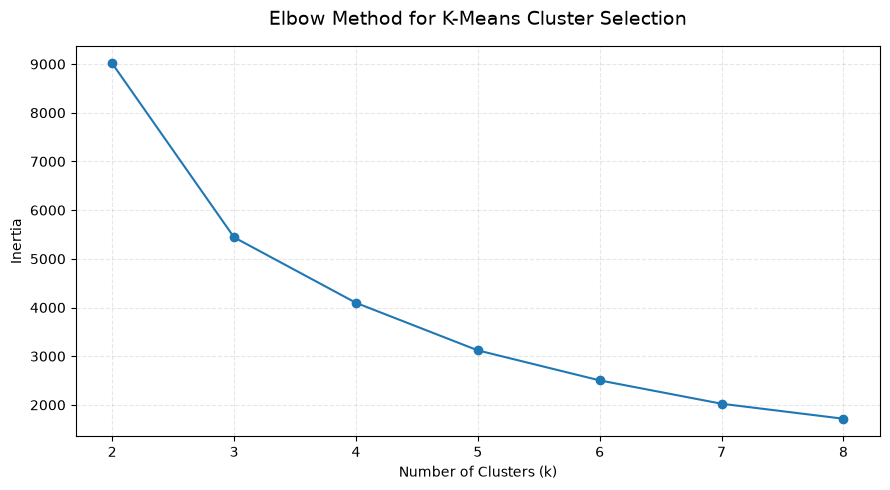

In [105]:
# Visualise cluster evaluation results

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    cluster_evaluation["Clusters (k)"],
    cluster_evaluation["Inertia"],
    marker="o"
)

ax.set_title(
    "Elbow Method for K-Means Cluster Selection",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia")

ax.grid(
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

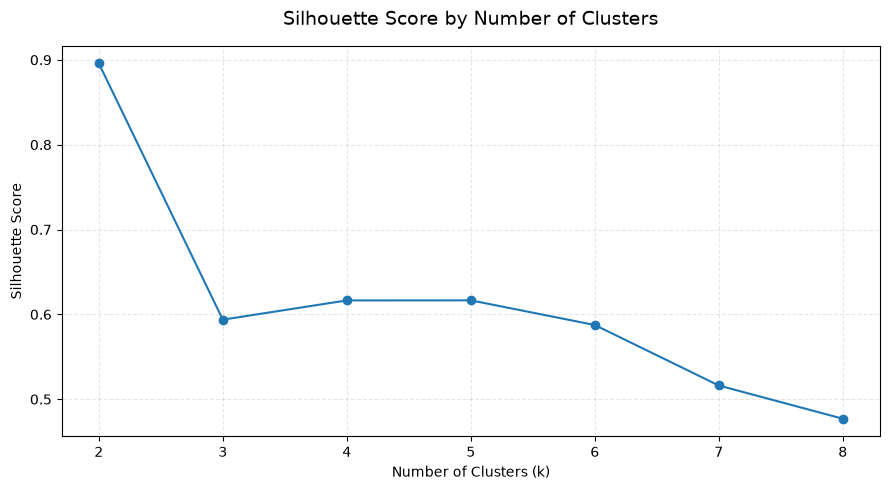

In [106]:
# Visualise silhouette scores

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    cluster_evaluation["Clusters (k)"],
    cluster_evaluation["Silhouette Score"],
    marker="o"
)

ax.set_title(
    "Silhouette Score by Number of Clusters",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Silhouette Score")

ax.set_xticks(
    cluster_evaluation["Clusters (k)"]
)

ax.grid(
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [107]:
# Compare cluster sizes for the main candidate solutions

candidate_k_values = [2, 4, 5]

cluster_size_results = []

for k in candidate_k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        cluster_features_scaled
    )

    cluster_counts = pd.Series(labels).value_counts().sort_index()

    for cluster, customers in cluster_counts.items():
        cluster_size_results.append({
            "k": k,
            "Cluster": cluster,
            "Customers": customers,
            "Share (%)": customers / len(cluster_features_scaled) * 100
        })

cluster_size_comparison = pd.DataFrame(
    cluster_size_results
)

display(
    cluster_size_comparison.style
    .format({
        "Customers": "{:,.0f}",
        "Share (%)": "{:.2f}%"
    })
    .hide(axis="index")
)

k,Cluster,Customers,Share (%)
2,0,"4,312",99.40%
2,1,26,0.60%
4,0,"3,060",70.54%
4,1,"1,061",24.46%
4,2,13,0.30%
4,3,204,4.70%
5,0,"3,050",70.31%
5,1,"1,061",24.46%
5,2,8,0.18%
5,3,213,4.91%


#### Cluster Selection

Although the two-cluster solution produced the highest silhouette score (0.896), its distribution was highly unbalanced: 99.40% of customers were assigned to one cluster and only 0.60% to the other. This suggests that the model was mainly separating a small group of extreme customer profiles from the rest of the customer base.

The four- and five-cluster solutions provided more informative structures, with very similar silhouette scores of 0.616 and 0.617 respectively. The five-cluster solution, however, introduced two very small clusters containing only eight and six customers. For this reason, four clusters were selected as a more practical balance between statistical separation and interpretability. This choice was made independently of the six business-defined RFM segments.

### 5.6.3 K-Means Clustering

Based on the cluster evaluation, the final K-Means model was fitted using four clusters. Cluster assignments were added to a separate analytical copy of the RFM dataset so that the original business segmentation remained unchanged.

In [108]:
# Fit the final K-Means model using the selected number of clusters

selected_k = 4

kmeans_final = KMeans(
    n_clusters=selected_k,
    random_state=42,
    n_init=10
)

final_cluster_labels = kmeans_final.fit_predict(
    cluster_features_scaled
)

# Preserve the original RFM dataset and add cluster assignments
# to a separate analytical copy

rfm_clustered = rfm.copy()
rfm_clustered["Cluster"] = final_cluster_labels

# Review final cluster distribution

final_cluster_distribution = (
    rfm_clustered["Cluster"]
    .value_counts()
    .sort_index()
    .rename("Customers")
    .to_frame()
)

final_cluster_distribution["Share (%)"] = (
    final_cluster_distribution["Customers"]
    / len(rfm_clustered)
    * 100
)

display(
    final_cluster_distribution.style
    .format({
        "Customers": "{:,.0f}",
        "Share (%)": "{:.2f}%"
    })
)

,Customers,Share (%)
Cluster,,
0,"3,060",70.54%
1,"1,061",24.46%
2,13,0.30%
3,204,4.70%


### 5.6.4 Cluster Profile and RFM Comparison

The cluster labels produced by K-Means are numerical identifiers and do not carry an inherent business meaning. To interpret the four groups, their average Recency, Frequency, and Monetary values are compared together with the number and share of customers assigned to each cluster.

The resulting profiles provide a data-driven view of customer behaviour that can then be compared with the business-defined RFM segments.

In [109]:
# Profile the final K-Means clusters using the original RFM values

cluster_profile = (
    rfm_clustered
    .groupby("Cluster")
    .agg(
        Customers=("Cluster", "size"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean")
    )
    .reset_index()
)

cluster_profile["Share (%)"] = (
    cluster_profile["Customers"]
    / len(rfm_clustered)
    * 100
)

# Reorder columns for easier interpretation

cluster_profile = cluster_profile[
    [
        "Cluster",
        "Customers",
        "Share (%)",
        "Avg_Recency",
        "Avg_Frequency",
        "Avg_Monetary"
    ]
]

display(
    cluster_profile.style
    .format({
        "Customers": "{:,.0f}",
        "Share (%)": "{:.2f}%",
        "Avg_Recency": "{:.2f}",
        "Avg_Frequency": "{:.2f}",
        "Avg_Monetary": "£{:,.2f}"
    })
    .hide(axis="index")
)

Cluster,Customers,Share (%),Avg_Recency,Avg_Frequency,Avg_Monetary
0,"3,060",70.54%,44.43,3.68,"£1,352.75"
1,"1,061",24.46%,249.17,1.55,£476.42
2,13,0.30%,7.62,82.54,"£127,187.96"
3,204,4.70%,15.96,22.33,"£12,690.50"


In [110]:
# Compare K-Means clusters with the business-defined RFM segments

cluster_segment_comparison = pd.crosstab(
    rfm_clustered["Cluster"],
    rfm_clustered["Segment"]
)

display(
    cluster_segment_comparison.style
    .format("{:,.0f}")
)

Segment,At Risk,Champions,Hibernating,Loyal Customers,Needs Attention,Potential Loyalists
Cluster,,,,,,
0,434,345,9,892,650,730
1,124,0,937,0,0,0
2,0,10,0,2,0,1
3,7,168,1,28,0,0


#### Interpretation

The comparison shows that the K-Means solution captures several behavioural patterns that are also visible in the business-defined RFM segmentation, although the two approaches do not produce identical groups. Cluster 1 is dominated by Hibernating customers (937 of 1,061), while Cluster 3 contains mainly Champions (168 of 204) and a smaller group of Loyal Customers. The 13 customers in Cluster 2 form an extreme high-value group, with 10 classified as Champions. Cluster 0 contains most of the remaining customer base and spans several RFM segments.

This difference is useful rather than contradictory. K-Means provides an independent, data-driven grouping based only on the three standardized RFM variables, whereas the rule-based segmentation separates customers into more detailed categories that are easier to connect with specific marketing actions. In this analysis, clustering highlights distinct inactive and unusually high-value customer groups, while the six RFM segments provide greater business granularity across the broader customer base.

The very small high-value cluster was reviewed separately because its Monetary and Frequency values were substantially above the wider customer distribution. Transaction-level totals for all 13 customers were reconstructed from the cleaned RFM input data and matched the aggregated Monetary values exactly. These observations were therefore retained as genuine high-value customer behaviour rather than removed solely because they were statistical outliers.

## 6. Visual Analysis of Customer Segments

The RFM analysis identified six customer segments with different purchasing patterns. The following visual analysis explores how these segments differ in size, customer behaviour and monetary contribution. The purpose is not only to compare the number of customers in each group, but also to examine whether their commercial importance is proportional to their size.

### 6.1 Customer Distribution by Segment

The number of customers in each segment is compared to provide an initial view of the customer base. This makes it easier to identify the largest behavioural groups and provides context for the financial comparisons that follow.

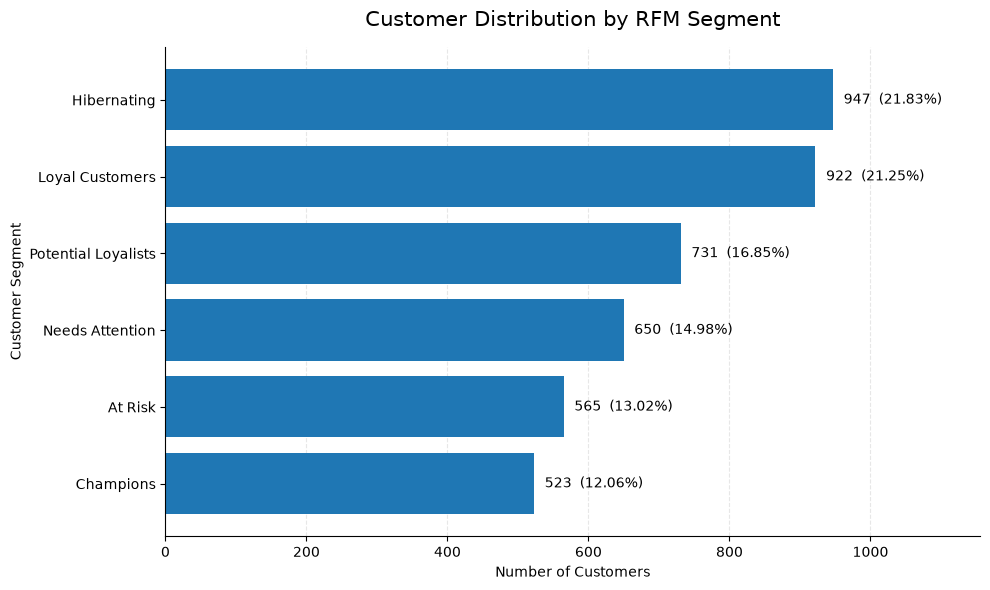

In [111]:
# Prepare segment distribution for visualisation
segment_plot = (
    rfm["Segment"]
    .value_counts()
    .rename("Customers")
    .to_frame()
)

segment_plot["Percentage"] = (
    segment_plot["Customers"] / len(rfm) * 100
).round(2)

# Sort from smallest to largest for horizontal plotting
segment_plot = segment_plot.sort_values("Customers")

# Create chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    segment_plot.index,
    segment_plot["Customers"]
)

# Add customer count and percentage labels
for bar, customers, percentage in zip(
    bars,
    segment_plot["Customers"],
    segment_plot["Percentage"]
):
    ax.text(
        bar.get_width() + 15,
        bar.get_y() + bar.get_height() / 2,
        f"{customers:,}  ({percentage:.2f}%)",
        va="center",
        fontsize=10
    )

# Titles and labels
ax.set_title(
    "Customer Distribution by RFM Segment",
    fontsize=15,
    pad=15
)

ax.set_xlabel("Number of Customers")
ax.set_ylabel("Customer Segment")

# Improve visual appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

# Leave space for labels
ax.set_xlim(
    0,
    segment_plot["Customers"].max() * 1.22
)

plt.tight_layout()
plt.show()

### 6.2 Monetary Value by RFM Segment

Customer count alone does not indicate the commercial importance of each segment. The total Monetary value generated by each RFM segment is therefore compared to show how customer value is distributed across the customer base.

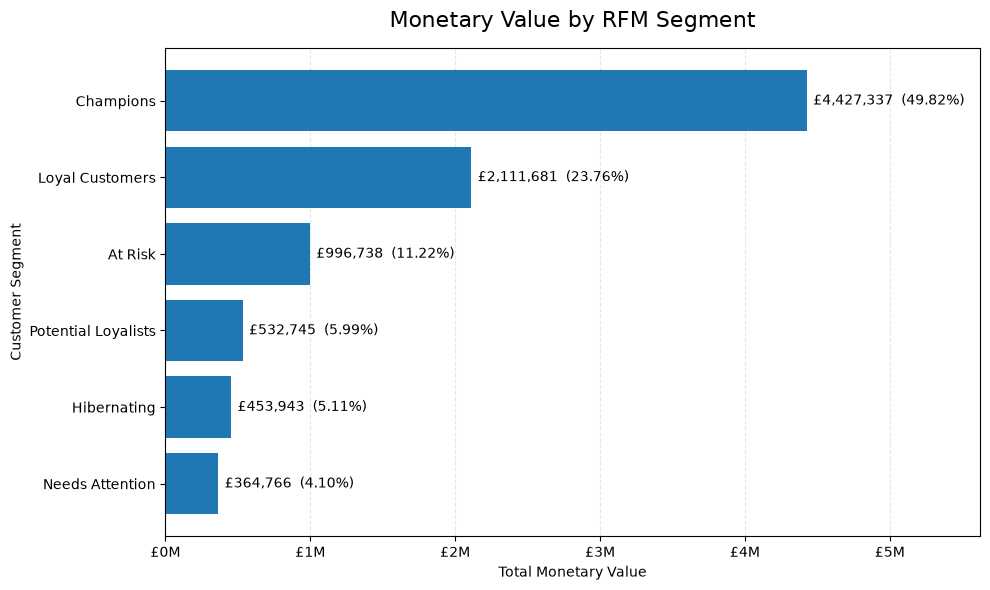

In [112]:
# Prepare segment monetary values
monetary_by_segment = (
    rfm.groupby("Segment")
    .agg(
        TotalMonetary=("Monetary", "sum")
    )
    .sort_values(
        "TotalMonetary",
        ascending=True
    )
)

# Calculate percentage contribution
monetary_by_segment["Percentage"] = (
    monetary_by_segment["TotalMonetary"]
    / monetary_by_segment["TotalMonetary"].sum()
    * 100
)

# Create chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    monetary_by_segment.index,
    monetary_by_segment["TotalMonetary"]
)

# Add value and percentage labels
for bar, value, percentage in zip(
    bars,
    monetary_by_segment["TotalMonetary"],
    monetary_by_segment["Percentage"]
):
    ax.text(
        value + monetary_by_segment["TotalMonetary"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"£{value:,.0f}  ({percentage:.2f}%)",
        va="center"
    )

# Format x-axis in millions
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"£{x / 1_000_000:.0f}M")
)

# Titles and labels
ax.set_title(
    "Monetary Value by RFM Segment",
    fontsize=16,
    pad=15
)

ax.set_xlabel("Total Monetary Value")
ax.set_ylabel("Customer Segment")

# Grid and layout
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

# Add space for labels
ax.set_xlim(
    0,
    monetary_by_segment["TotalMonetary"].max() * 1.27
)

plt.tight_layout()
plt.show()

### 6.3 Customer Share vs Monetary Share

The customer share and monetary share of each RFM segment are compared directly to highlight differences between segment size and commercial contribution.

This comparison helps identify segments that generate disproportionately high or low monetary value relative to their share of the customer base.

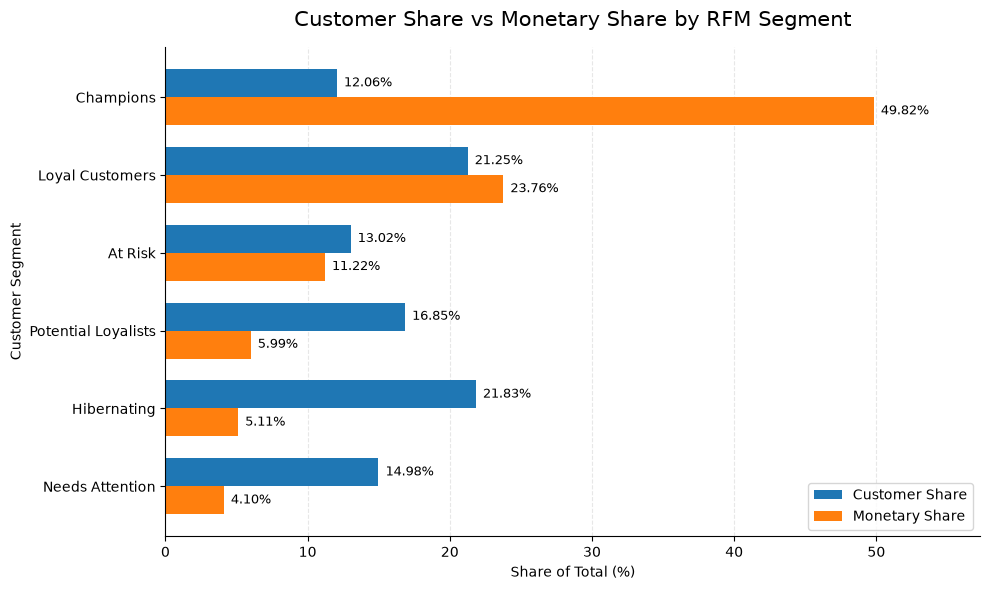

In [113]:
# Prepare comparison dataframe
segment_comparison = (
    rfm.groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        TotalMonetary=("Monetary", "sum")
    )
)

segment_comparison["CustomerShare"] = (
    segment_comparison["Customers"]
    / segment_comparison["Customers"].sum()
    * 100
)

segment_comparison["MonetaryShare"] = (
    segment_comparison["TotalMonetary"]
    / segment_comparison["TotalMonetary"].sum()
    * 100
)

# Sort by monetary share for clearer comparison
segment_comparison = segment_comparison.sort_values(
    "MonetaryShare",
    ascending=False
)

# Create chart
fig, ax = plt.subplots(figsize=(10, 6))

y_positions = range(len(segment_comparison))
bar_height = 0.36

ax.barh(
    [y - bar_height / 2 for y in y_positions],
    segment_comparison["CustomerShare"],
    height=bar_height,
    label="Customer Share"
)

ax.barh(
    [y + bar_height / 2 for y in y_positions],
    segment_comparison["MonetaryShare"],
    height=bar_height,
    label="Monetary Share"
)

# Add percentage labels
for i, (_, row) in enumerate(segment_comparison.iterrows()):
    ax.text(
        row["CustomerShare"] + 0.5,
        i - bar_height / 2,
        f"{row['CustomerShare']:.2f}%",
        va="center",
        fontsize=9
    )

    ax.text(
        row["MonetaryShare"] + 0.5,
        i + bar_height / 2,
        f"{row['MonetaryShare']:.2f}%",
        va="center",
        fontsize=9
    )

# Labels and title
ax.set_yticks(list(y_positions))
ax.set_yticklabels(segment_comparison.index)

ax.set_title(
    "Customer Share vs Monetary Share by RFM Segment",
    fontsize=15,
    pad=15
)

ax.set_xlabel("Share of Total (%)")
ax.set_ylabel("Customer Segment")

ax.legend()

# Improve visual appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

ax.set_xlim(
    0,
    segment_comparison[
        ["CustomerShare", "MonetaryShare"]
    ].max().max() * 1.15
)

# Keep highest monetary contribution at the top
ax.invert_yaxis()

plt.tight_layout()
plt.show()

### 6.4 RFM Behaviour by Customer Segment

The behavioural characteristics of each segment are compared using average Recency, Frequency and Monetary value. This provides a more detailed view of how the segments differ beyond their relative size and total financial contribution.

Because the three RFM measures use different scales, the results are presented as a summary table rather than combined directly in a single chart. This keeps the original values visible and makes the differences between customer groups easier to interpret.

In [114]:
segment_behaviour = (
    rfm.groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        AvgRecency=("Recency", "mean"),
        AvgFrequency=("Frequency", "mean"),
        AvgMonetary=("Monetary", "mean"),
        TotalMonetary=("Monetary", "sum")
    )
)

segment_behaviour["CustomerShare"] = (
    segment_behaviour["Customers"]
    / segment_behaviour["Customers"].sum()
    * 100
)

segment_behaviour["MonetaryShare"] = (
    segment_behaviour["TotalMonetary"]
    / segment_behaviour["TotalMonetary"].sum()
    * 100
)

# Sort segments by average monetary value
segment_behaviour = segment_behaviour.sort_values(
    "AvgMonetary",
    ascending=False
)

# Format values for presentation
segment_behaviour_display = segment_behaviour.copy()

segment_behaviour_display["AvgRecency"] = (
    segment_behaviour_display["AvgRecency"].round(1)
)

segment_behaviour_display["AvgFrequency"] = (
    segment_behaviour_display["AvgFrequency"].round(1)
)

segment_behaviour_display["AvgMonetary"] = (
    segment_behaviour_display["AvgMonetary"].map(
        lambda x: f"£{x:,.2f}"
    )
)

segment_behaviour_display["TotalMonetary"] = (
    segment_behaviour_display["TotalMonetary"].map(
        lambda x: f"£{x:,.2f}"
    )
)

segment_behaviour_display["CustomerShare"] = (
    segment_behaviour_display["CustomerShare"].map(
        lambda x: f"{x:.2f}%"
    )
)

segment_behaviour_display["MonetaryShare"] = (
    segment_behaviour_display["MonetaryShare"].map(
        lambda x: f"{x:.2f}%"
    )
)

segment_behaviour_display

,Customers,AvgRecency,AvgFrequency,AvgMonetary,TotalMonetary,CustomerShare,MonetaryShare
Segment,,,,,,,
Champions,523,7.9,15.1,"£8,465.27","£4,427,336.79",12.06%,49.82%
Loyal Customers,922,23.7,5.3,"£2,290.33","£2,111,681.07",21.25%,23.76%
At Risk,565,113.4,4.5,"£1,764.14","£996,737.72",13.02%,11.22%
Potential Loyalists,731,25.1,1.5,£728.79,"£532,744.73",16.85%,5.99%
Needs Attention,650,84.8,1.4,£561.18,"£364,766.02",14.98%,4.10%
Hibernating,947,253.6,1.2,£479.35,"£453,942.56",21.83%,5.11%


### 6.5 Segment-Based Business Recommendations

The RFM results provide a basis for translating customer behaviour into practical marketing decisions. Rather than treating all customers in the same way, the observed differences in Recency, Frequency and Monetary contribution can be used to identify different business priorities across the customer base.

The recommendations below are managerial interpretations derived from the behavioural characteristics observed in each RFM segment. They should therefore be understood as decision-support recommendations rather than predictions of future customer behaviour. The analytical model identifies which customer groups may deserve attention, while the final marketing action remains a business decision.

In [115]:
# Define business objectives and recommended actions for each RFM segment

segment_recommendations = {
    "Champions": {
        "Business Objective": "Retain and reward",
        "Recommended Action": (
            "Prioritise retention through loyalty benefits "
            "and personalised offers"
        )
    },
    "Loyal Customers": {
        "Business Objective": "Maintain loyalty",
        "Recommended Action": (
            "Use personalised offers and cross-selling opportunities "
            "to maintain engagement"
        )
    },
    "Potential Loyalists": {
        "Business Objective": "Develop loyalty",
        "Recommended Action": (
            "Encourage repeat purchasing through targeted "
            "follow-up offers"
        )
    },
    "At Risk": {
        "Business Objective": "Re-engage valuable customers",
        "Recommended Action": (
            "Use targeted re-engagement campaigns based on "
            "previous purchasing behaviour"
        )
    },
    "Needs Attention": {
        "Business Objective": "Increase engagement",
        "Recommended Action": (
            "Use relevant promotional offers to encourage "
            "renewed purchasing"
        )
    },
    "Hibernating": {
        "Business Objective": "Reactivate selectively",
        "Recommended Action": (
            "Prioritise low-cost reactivation initiatives, particularly "
            "for customers with stronger historical value"
        )
    }
}

# Build the recommendation table from the segment results

recommendation_table = (
    segment_profile
    .reset_index()
    [
        [
            "Segment",
            "Customers",
            "CustomerPercentage",
            "MonetaryPercentage"
        ]
    ]
    .copy()
)

# Add business recommendations

recommendation_table["Business Objective"] = (
    recommendation_table["Segment"]
    .map(lambda x: segment_recommendations[x]["Business Objective"])
)

recommendation_table["Recommended Action"] = (
    recommendation_table["Segment"]
    .map(lambda x: segment_recommendations[x]["Recommended Action"])
)

# Rename columns for clearer presentation

recommendation_table = recommendation_table.rename(
    columns={
        "CustomerPercentage": "Customer Share",
        "MonetaryPercentage": "Monetary Share"
    }
)

# Display without the DataFrame index

(
    recommendation_table.style
    .format({
        "Customer Share": "{:.2f}%",
        "Monetary Share": "{:.2f}%"
    })
    .hide(axis="index")
)

Segment,Customers,Customer Share,Monetary Share,Business Objective,Recommended Action
Champions,523,12.06%,49.82%,Retain and reward,Prioritise retention through loyalty benefits and personalised offers
Loyal Customers,922,21.25%,23.76%,Maintain loyalty,Use personalised offers and cross-selling opportunities to maintain engagement
At Risk,565,13.02%,11.22%,Re-engage valuable customers,Use targeted re-engagement campaigns based on previous purchasing behaviour
Potential Loyalists,731,16.85%,5.99%,Develop loyalty,Encourage repeat purchasing through targeted follow-up offers
Hibernating,947,21.83%,5.11%,Reactivate selectively,"Prioritise low-cost reactivation initiatives, particularly for customers with stronger historical value"
Needs Attention,650,14.98%,4.10%,Increase engagement,Use relevant promotional offers to encourage renewed purchasing


### 6.6 Geographic Profile of Customer Segments

The geographic composition of the RFM segments is examined to determine whether customer behaviour differs between the United Kingdom and international markets. Earlier analysis showed that international customers represent a relatively small share of the customer base but account for a larger proportion of transaction value.

Before assigning a country to each customer, the consistency of the Country field is checked at customer level. This avoids assigning a geographic profile where the same CustomerID may be associated with multiple countries in the transactional data.

#### 6.6.1 Customer Country Consistency

The number of distinct countries associated with each CustomerID is examined before geographic information is added to the customer-level RFM table. Customers appearing in more than one country are identified separately so that the geographic classification is not based on an unsupported assumption.

In [116]:
# Count the number of distinct countries associated with each customer
customer_country_count = (
    df_rfm_base
    .groupby("CustomerID")["Country"]
    .nunique()
)

customers_one_country = (
    customer_country_count == 1
).sum()

customers_multiple_countries = (
    customer_country_count > 1
).sum()

print(
    f"Customers associated with one country: "
    f"{customers_one_country:,}"
)

print(
    f"Customers associated with multiple countries: "
    f"{customers_multiple_countries:,}"
)

print(
    f"Total customers checked: "
    f"{len(customer_country_count):,}"
)

Customers associated with one country: 4,330
Customers associated with multiple countries: 8
Total customers checked: 4,338


In [117]:
# Identify customers associated with more than one country
multi_country_customers = customer_country_count[
    customer_country_count > 1
].index

multi_country_details = (
    df_rfm_base[
        df_rfm_base["CustomerID"].isin(multi_country_customers)
    ]
    .groupby(["CustomerID", "Country"])
    .agg(
        Records=("InvoiceNo", "size"),
        UniqueInvoices=("InvoiceNo", "nunique"),
        TransactionValue=("TransactionValue", "sum")
    )
    .reset_index()
    .sort_values(
        ["CustomerID", "TransactionValue"],
        ascending=[True, False]
    )
)

multi_country_details["TransactionValue"] = (
    multi_country_details["TransactionValue"].round(2)
)

# Remove decimal notation from CustomerID for display
multi_country_details["CustomerID"] = (
    multi_country_details["CustomerID"].astype("Int64")
)

multi_country_details

,CustomerID,Country,Records,UniqueInvoices,TransactionValue
1,12370,Cyprus,158,3,3264.74
0,12370,Austria,8,1,277.20
3,12394,Denmark,6,1,891.40
2,12394,Belgium,21,1,381.08
4,12417,Belgium,169,8,3212.80
5,12417,Spain,23,1,436.30
7,12422,Switzerland,18,1,417.36
6,12422,Australia,21,2,386.20
9,12429,Denmark,76,3,3312.42
8,12429,Austria,21,1,437.98


#### 6.6.2 Assigning Customer Country

Most customers are associated with a single country, while only eight customers appear across more than one market. For these cases, the country generating the highest transaction value is used as the customer's primary market. This provides a consistent customer-level geographic classification while retaining all customers in the RFM analysis.

In [118]:
# Calculate customer activity by country
customer_country_value = (
    df_rfm_base
    .groupby(["CustomerID", "Country"])
    .agg(
        TransactionValue=("TransactionValue", "sum"),
        UniqueInvoices=("InvoiceNo", "nunique")
    )
    .reset_index()
)

# Assign the country with the highest transaction value
# UniqueInvoices acts as a secondary criterion in case of a tie
primary_country = (
    customer_country_value
    .sort_values(
        ["CustomerID", "TransactionValue", "UniqueInvoices"],
        ascending=[True, False, False]
    )
    .drop_duplicates("CustomerID")
    [["CustomerID", "Country"]]
)

# Add the primary country to the customer-level RFM table
rfm = rfm.merge(
    primary_country,
    on="CustomerID",
    how="left"
)

print(f"Customers in RFM table: {len(rfm):,}")
print(f"Customers with assigned country: {rfm['Country'].notna().sum():,}")
print(f"Customers without assigned country: {rfm['Country'].isna().sum():,}")
print(f"Countries represented: {rfm['Country'].nunique():,}")

Customers in RFM table: 4,338
Customers with assigned country: 4,338
Customers without assigned country: 0
Countries represented: 37


#### 6.6.3 UK vs International RFM Profile

The geographic analysis is first considered at market level by separating United Kingdom customers from international customers. This provides a more useful comparison than examining individual countries immediately, since the customer base is strongly concentrated in the United Kingdom while international customers still represent a meaningful share of transaction value.

The comparison examines customer distribution, average RFM characteristics and monetary contribution across the two markets.

In [119]:
# Classify customers into UK and International markets
rfm["Market"] = rfm["Country"].apply(
    lambda x: "United Kingdom"
    if x == "United Kingdom"
    else "International"
)

# Summarise RFM characteristics by market
market_profile = (
    rfm
    .groupby("Market")
    .agg(
        Customers=("CustomerID", "nunique"),
        AvgRecency=("Recency", "mean"),
        AvgFrequency=("Frequency", "mean"),
        AvgMonetary=("Monetary", "mean"),
        TotalMonetary=("Monetary", "sum")
    )
)

# Calculate customer share
market_profile["CustomerShare"] = (
    market_profile["Customers"]
    / market_profile["Customers"].sum()
    * 100
)

# Calculate monetary share
market_profile["MonetaryShare"] = (
    market_profile["TotalMonetary"]
    / market_profile["TotalMonetary"].sum()
    * 100
)

# Rename columns for clearer presentation
market_profile_display = (
    market_profile
    .rename(
        columns={
            "AvgRecency": "Avg Recency",
            "AvgFrequency": "Avg Frequency",
            "AvgMonetary": "Avg Monetary",
            "TotalMonetary": "Total Monetary",
            "CustomerShare": "Customer Share",
            "MonetaryShare": "Monetary Share"
        }
    )
    .reset_index()
    .copy()
)

# Format averages with two decimal places
market_profile_display["Avg Recency"] = (
    market_profile_display["Avg Recency"]
    .map(lambda x: f"{x:.2f}")
)

market_profile_display["Avg Frequency"] = (
    market_profile_display["Avg Frequency"]
    .map(lambda x: f"{x:.2f}")
)

# Format monetary values
market_profile_display["Avg Monetary"] = (
    market_profile_display["Avg Monetary"]
    .map(lambda x: f"£{x:,.2f}")
)

market_profile_display["Total Monetary"] = (
    market_profile_display["Total Monetary"]
    .map(lambda x: f"£{x:,.2f}")
)

# Format percentages
market_profile_display["Customer Share"] = (
    market_profile_display["Customer Share"]
    .map(lambda x: f"{x:.2f}%")
)

market_profile_display["Monetary Share"] = (
    market_profile_display["Monetary Share"]
    .map(lambda x: f"{x:.2f}%")
)

# Display without the DataFrame index
market_profile_display.style.hide(axis="index")

Market,Customers,Avg Recency,Avg Frequency,Avg Monetary,Total Monetary,Customer Share,Monetary Share
International,418,96.04,4.51,"£3,832.98","£1,602,184.25",9.64%,18.03%
United Kingdom,3920,92.74,4.25,"£1,858.42","£7,285,024.64",90.36%,81.97%


#### 6.6.4 International Market Profile

The international customer base is examined in greater detail to identify which markets contribute most strongly to customer activity and monetary value outside the United Kingdom. Although international customers represent a relatively small proportion of the overall customer base, their contribution to total monetary value is proportionally higher. Comparing individual international markets helps identify where this value is concentrated and provides additional context for market-level decision support.

In [120]:
# Create a customer-level profile for international markets
international_profile = (
    rfm[
        rfm["Country"] != "United Kingdom"
    ]
    .groupby("Country")
    .agg(
        Customers=("CustomerID", "nunique"),
        AvgRecency=("Recency", "mean"),
        AvgFrequency=("Frequency", "mean"),
        AvgMonetary=("Monetary", "mean"),
        TotalMonetary=("Monetary", "sum")
    )
    .sort_values(
        "TotalMonetary",
        ascending=False
    )
)

# Calculate shares within the international customer base
international_profile["CustomerShare"] = (
    international_profile["Customers"]
    / international_profile["Customers"].sum()
    * 100
)

international_profile["MonetaryShare"] = (
    international_profile["TotalMonetary"]
    / international_profile["TotalMonetary"].sum()
    * 100
)

# Prepare the ten largest international markets for presentation
international_profile_display = (
    international_profile
    .head(10)
    .rename(
        columns={
            "AvgRecency": "Avg Recency",
            "AvgFrequency": "Avg Frequency",
            "AvgMonetary": "Avg Monetary",
            "TotalMonetary": "Total Monetary",
            "CustomerShare": "Customer Share",
            "MonetaryShare": "Monetary Share"
        }
    )
    .reset_index()
    .copy()
)

# Format averages
international_profile_display["Avg Recency"] = (
    international_profile_display["Avg Recency"]
    .map(lambda x: f"{x:.2f}")
)

international_profile_display["Avg Frequency"] = (
    international_profile_display["Avg Frequency"]
    .map(lambda x: f"{x:.2f}")
)

# Format monetary values
international_profile_display["Avg Monetary"] = (
    international_profile_display["Avg Monetary"]
    .map(lambda x: f"£{x:,.2f}")
)

international_profile_display["Total Monetary"] = (
    international_profile_display["Total Monetary"]
    .map(lambda x: f"£{x:,.2f}")
)

# Format percentages
international_profile_display["Customer Share"] = (
    international_profile_display["Customer Share"]
    .map(lambda x: f"{x:.2f}%")
)

international_profile_display["Monetary Share"] = (
    international_profile_display["Monetary Share"]
    .map(lambda x: f"{x:.2f}%")
)

# Display without DataFrame index
international_profile_display.style.hide(axis="index")

Country,Customers,Avg Recency,Avg Frequency,Avg Monetary,Total Monetary,Customer Share,Monetary Share
Netherlands,9,102.56,10.44,"£31,716.26","£285,446.34",2.15%,17.82%
EIRE,3,58.00,86.67,"£88,420.82","£265,262.46",0.72%,16.56%
Germany,94,78.12,4.86,"£2,432.75","£228,678.40",22.49%,14.27%
France,87,90.01,4.47,"£2,401.54","£208,934.31",20.81%,13.04%
Australia,8,101.12,7.12,"£17,380.05","£139,040.39",1.91%,8.68%
Spain,28,77.50,3.04,"£2,155.51","£60,354.30",6.70%,3.77%
Switzerland,21,111.33,2.62,"£2,724.90","£57,222.85",5.02%,3.57%
Belgium,23,97.96,4.17,"£1,751.25","£40,278.78",5.50%,2.51%
Sweden,8,71.62,4.50,"£4,795.98","£38,367.83",1.91%,2.39%
Japan,8,129.12,2.38,"£4,677.05","£37,416.37",1.91%,2.34%


#### 6.6.5 International Customer and Monetary Share

Customer share and monetary share are compared across the leading international markets to examine whether the size of each customer base is proportional to its contribution to international transaction value. Differences between these measures can highlight markets where a relatively small number of customers generate a comparatively large share of monetary value.

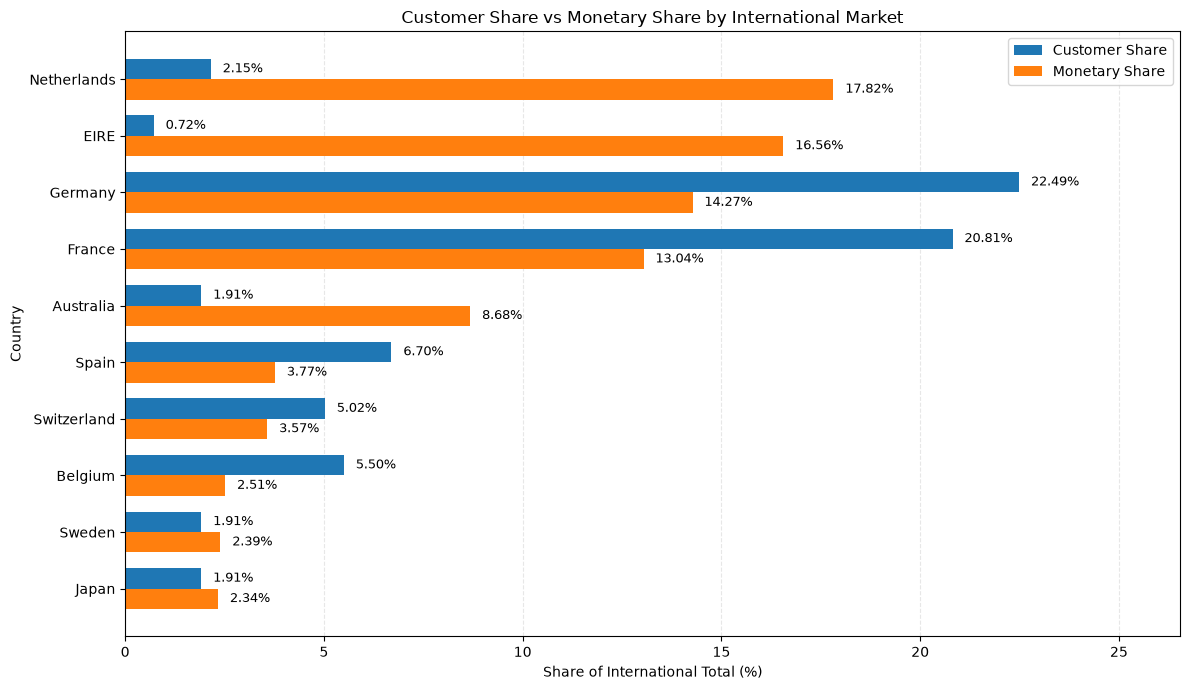

In [121]:
import matplotlib.pyplot as plt
import numpy as np

# Select the leading international markets by total monetary value
international_chart = (
    international_profile
    .head(10)
    .sort_values("TotalMonetary", ascending=True)
    .copy()
)

countries = international_chart.index
customer_share = international_chart["CustomerShare"]
monetary_share = international_chart["MonetaryShare"]

y = np.arange(len(countries))
bar_height = 0.36

fig, ax = plt.subplots(figsize=(12, 7))

bars_customer = ax.barh(
    y + bar_height / 2,
    customer_share,
    height=bar_height,
    label="Customer Share"
)

bars_monetary = ax.barh(
    y - bar_height / 2,
    monetary_share,
    height=bar_height,
    label="Monetary Share"
)

# Add percentage labels
for bar in bars_customer:
    width = bar.get_width()
    ax.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}%",
        va="center",
        fontsize=9
    )

for bar in bars_monetary:
    width = bar.get_width()
    ax.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}%",
        va="center",
        fontsize=9
    )

ax.set_yticks(y)
ax.set_yticklabels(countries)

ax.set_xlabel("Share of International Total (%)")
ax.set_ylabel("Country")
ax.set_title("Customer Share vs Monetary Share by International Market")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)
ax.legend()

# Add space for value labels
ax.set_xlim(
    0,
    max(customer_share.max(), monetary_share.max()) * 1.18
)

plt.tight_layout()
plt.show()

## 6.7 Decision Support Summary

The RFM segmentation results can be consolidated into a decision-support view that connects customer behaviour, commercial value and potential business action. Rather than treating all customers equally, the segmentation provides a structured basis for identifying where retention, development, re-engagement or selective reactivation efforts may be most relevant.

The summary below combines the size and monetary contribution of each customer segment with the business objectives derived from the observed RFM characteristics. These recommendations should be interpreted as decision-support guidance based on historical purchasing behaviour rather than as predictions of future customer behaviour.

### 6.7.1 Consolidated Decision Support Table

The customer segments are consolidated into a single decision-support table combining segment size, average RFM characteristics, monetary contribution and corresponding business objectives. Recommended actions are linked to each segment according to its observed purchasing behaviour and commercial value. This provides a practical interpretation of the RFM results while preserving the underlying analytical measures used to define each customer group.

In [122]:
# Create consolidated decision-support summary from the validated segment profile

decision_support = (
    segment_profile
    .reset_index()
    [
        [
            "Segment",
            "Customers",
            "AvgRecency",
            "AvgFrequency",
            "AvgMonetary",
            "TotalMonetary",
            "CustomerPercentage",
            "MonetaryPercentage"
        ]
    ]
    .copy()
)

# Define business objectives and recommended actions by segment

business_objectives = {
    "Champions": "Retain and reward",
    "Loyal Customers": "Maintain loyalty",
    "Potential Loyalists": "Develop loyalty",
    "At Risk": "Re-engage valuable customers",
    "Needs Attention": "Increase engagement",
    "Hibernating": "Reactivate selectively"
}

recommended_actions = {
    "Champions": (
        "Prioritise retention through loyalty benefits "
        "and personalised offers"
    ),
    "Loyal Customers": (
        "Use personalised offers and cross-selling opportunities "
        "to maintain engagement"
    ),
    "Potential Loyalists": (
        "Encourage repeat purchasing through targeted "
        "follow-up offers"
    ),
    "At Risk": (
        "Use targeted re-engagement campaigns based on "
        "previous purchasing behaviour"
    ),
    "Needs Attention": (
        "Use relevant promotional offers to encourage "
        "renewed purchasing"
    ),
    "Hibernating": (
        "Prioritise low-cost reactivation initiatives, particularly "
        "for customers with stronger historical value"
    )
}

# Map recommendations safely by segment name

decision_support["Business Objective"] = (
    decision_support["Segment"]
    .map(business_objectives)
)

decision_support["Recommended Action"] = (
    decision_support["Segment"]
    .map(recommended_actions)
)

# Rename analytical columns for presentation

decision_support_display = (
    decision_support
    .rename(
        columns={
            "AvgRecency": "Avg Recency",
            "AvgFrequency": "Avg Frequency",
            "AvgMonetary": "Avg Monetary",
            "TotalMonetary": "Total Monetary",
            "CustomerPercentage": "Customer Share",
            "MonetaryPercentage": "Monetary Share"
        }
    )
    .copy()
)

# Format averages

decision_support_display["Avg Recency"] = (
    decision_support_display["Avg Recency"]
    .map(lambda x: f"{x:.2f}")
)

decision_support_display["Avg Frequency"] = (
    decision_support_display["Avg Frequency"]
    .map(lambda x: f"{x:.2f}")
)

# Format monetary values

decision_support_display["Avg Monetary"] = (
    decision_support_display["Avg Monetary"]
    .map(lambda x: f"£{x:,.2f}")
)

decision_support_display["Total Monetary"] = (
    decision_support_display["Total Monetary"]
    .map(lambda x: f"£{x:,.2f}")
)

# Format percentages

decision_support_display["Customer Share"] = (
    decision_support_display["Customer Share"]
    .map(lambda x: f"{x:.2f}%")
)

decision_support_display["Monetary Share"] = (
    decision_support_display["Monetary Share"]
    .map(lambda x: f"{x:.2f}%")
)

# Display without pandas index

decision_support_display.style.hide(axis="index")

Segment,Customers,Avg Recency,Avg Frequency,Avg Monetary,Total Monetary,Customer Share,Monetary Share,Business Objective,Recommended Action
Champions,523,7.88,15.12,"£8,465.27","£4,427,336.79",12.06%,49.82%,Retain and reward,Prioritise retention through loyalty benefits and personalised offers
Loyal Customers,922,23.70,5.33,"£2,290.33","£2,111,681.07",21.25%,23.76%,Maintain loyalty,Use personalised offers and cross-selling opportunities to maintain engagement
At Risk,565,113.41,4.51,"£1,764.14","£996,737.72",13.02%,11.22%,Re-engage valuable customers,Use targeted re-engagement campaigns based on previous purchasing behaviour
Potential Loyalists,731,25.11,1.50,£728.79,"£532,744.73",16.85%,5.99%,Develop loyalty,Encourage repeat purchasing through targeted follow-up offers
Hibernating,947,253.62,1.24,£479.35,"£453,942.56",21.83%,5.11%,Reactivate selectively,"Prioritise low-cost reactivation initiatives, particularly for customers with stronger historical value"
Needs Attention,650,84.78,1.36,£561.18,"£364,766.02",14.98%,4.10%,Increase engagement,Use relevant promotional offers to encourage renewed purchasing


# 7. Decision Support Dashboard

The analytical results developed in the previous sections provide the basis for a business-oriented decision support dashboard. While the Python analysis was used to prepare the data, calculate RFM measures, define customer segments and examine their commercial characteristics, the dashboard provides a visual layer through which these results can be interpreted more efficiently.

The dashboard is designed to summarise the most relevant customer and market indicators identified during the analysis. Particular attention is given to customer segmentation, monetary contribution and geographic distribution, allowing differences in customer value and behaviour to be examined from a business perspective.

The K-Means analysis is retained as a complementary analytical layer rather than used as the primary dashboard segmentation. The six RFM segments provide more interpretable business categories for marketing decision-making, while the clustering results offer an independent data-driven perspective on broader behavioural patterns and unusually high-value customer groups. The dashboard therefore remains centred on the RFM segmentation.

The objective is not to replace managerial judgement or predict future customer behaviour, but to organise the analytical findings into an accessible decision-support view that can assist in identifying customer groups and markets that may require different commercial approaches.

## 7.1 Dashboard Dataset Preparation

A customer-level dataset is prepared to connect the analytical results with the decision support dashboard. Each row represents one identified customer and retains the RFM measures, corresponding scores, customer segment and assigned country developed during the previous stages of the analysis.

A broader market classification is also included to distinguish customers assigned to the United Kingdom from those assigned to international markets. Maintaining the dataset at customer level allows the dashboard to aggregate and filter the results dynamically while preserving consistency with the RFM customer population.

### 7.1.1 Customer-Level Dashboard Dataset

The final analytical variables are combined into a customer-level dataset for use in the decision support dashboard. Each row represents one customer and includes the assigned country and market, the three RFM measures, individual RFM scores, the combined score, and the final customer segment.

In [123]:
# Create customer-level dataset for the decision support dashboard

dashboard_data = rfm[
    [
        "CustomerID",
        "Country",
        "Recency",
        "Frequency",
        "Monetary",
        "R_Score",
        "F_Score",
        "M_Score",
        "RFM_Score",
        "Segment"
    ]
].copy()

# Add broader market classification

dashboard_data["Market"] = np.where(
    dashboard_data["Country"] == "United Kingdom",
    "United Kingdom",
    "International"
)

# Reorder columns for presentation

dashboard_data = dashboard_data[
    [
        "CustomerID",
        "Country",
        "Market",
        "Recency",
        "Frequency",
        "Monetary",
        "R_Score",
        "F_Score",
        "M_Score",
        "RFM_Score",
        "Segment"
    ]
]

# Ensure CustomerID is displayed as an integer

dashboard_data["CustomerID"] = (
    dashboard_data["CustomerID"]
    .astype(int)
)

# Display sample

dashboard_data.head(20).style.hide(axis="index")

CustomerID,Country,Market,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
12346,United Kingdom,United Kingdom,326,1,77183.600000,1,1,4,6,Hibernating
12347,Iceland,International,3,7,4310.000000,4,4,4,12,Champions
12348,Finland,International,76,4,1797.240000,2,3,4,9,At Risk
12349,Italy,International,19,1,1757.550000,3,1,4,8,Potential Loyalists
12350,Norway,International,311,1,334.400000,1,1,2,4,Hibernating
12352,Norway,International,37,8,2506.040000,3,4,4,11,Loyal Customers
12353,Bahrain,International,205,1,89.000000,1,1,1,3,Hibernating
12354,Spain,International,233,1,1079.400000,1,1,3,5,Hibernating
12355,Bahrain,International,215,1,459.400000,1,1,2,4,Hibernating
12356,Portugal,International,23,3,2811.430000,3,3,4,10,Loyal Customers


### 7.1.2 Dashboard Dataset Export

Following validation, the customer-level dataset is exported for use in the decision support dashboard. Numerical measures are retained in their original numeric format so that aggregations, filters and calculations can be performed directly within the dashboard environment. The exported file therefore represents the final analytical dataset connecting the Python-based RFM analysis with the dashboard layer.

In [124]:
# Define export file path

dashboard_file = "../outputs/online_retail_rfm_dashboard.csv"

# Export customer-level dashboard dataset

dashboard_data.to_csv(
    dashboard_file,
    index=False
)

print(
    f"Dashboard dataset exported successfully: {dashboard_file}"
)

print(
    f"Records exported: {len(dashboard_data):,}"
)

print(
    f"Columns exported: {len(dashboard_data.columns)}"
)

Dashboard dataset exported successfully: ../outputs/online_retail_rfm_dashboard.csv
Records exported: 4,338
Columns exported: 11


### 7.1.3 Export Verification

The exported dashboard file is reloaded and compared with the prepared dataset to confirm that the export process preserved the expected number of records and columns. This final verification ensures that the file subsequently used by the dashboard corresponds to the validated analytical dataset.

In [125]:
# Reload exported dashboard dataset

dashboard_check = pd.read_csv(
    dashboard_file
)

print(
    f"Exported records: {len(dashboard_check):,}"
)

print(
    f"Exported columns: {len(dashboard_check.columns)}"
)

print(
    f"Unique customers: "
    f"{dashboard_check['CustomerID'].nunique():,}"
)

print(
    f"Missing values: "
    f"{dashboard_check.isna().sum().sum():,}"
)

print(
    f"Total monetary value: "
    f"£{dashboard_check['Monetary'].sum():,.2f}"
)

Exported records: 4,338
Exported columns: 11
Unique customers: 4,338
Missing values: 0
Total monetary value: £8,887,208.89


## 7.2 Dashboard Design

The dashboard was designed as a visual decision-support layer for the customer-level RFM analysis. Rather than presenting every variable available in the processed dataset, the design focuses on indicators and visualisations that help explain customer value, purchasing behaviour, segment composition, and geographic differences.

The executive view is organised around five key performance indicators: **Total Customers**, **Total Monetary Value**, **Average Monetary Value per Customer**, **Average Purchase Frequency**, and **Average Recency**. These indicators provide an overview of the size, value, purchasing activity, and recency of the customer base before moving into more detailed segment-level analysis.

The analytical area of the dashboard was designed to compare the six RFM segments from different perspectives. Customer distribution provides an indication of segment size, while monetary and behavioural measures show that customer volume alone does not necessarily reflect economic importance. Additional views are used to examine the proportional composition of the customer base, the combined RFM profile of each segment, and geographic differences across customers and markets.

Interactive controls for **Segment**, **Market**, and **Country** are incorporated into the design to allow users to explore the results from different perspectives. The overall layout follows a one-page executive dashboard approach, keeping high-level KPIs visible while supporting more detailed analysis through the visualisations and filters below them.

The dashboard is implemented in Data Studio using the customer-level RFM dataset generated in Python. The following section documents its implementation and validates the dashboard results against the corresponding Python calculations.


## 7.3 Dashboard Implementation

The validated customer-level dataset is connected to Data Studio to implement the interactive decision support dashboard. The implementation begins with data source configuration and field validation before any visual components are created.

This step ensures that identifiers, categorical dimensions, RFM measures and monetary values are interpreted correctly by the dashboard platform. Once the data source has been validated, the dashboard components are added progressively and checked against the results previously obtained in Python.

### 7.3.1 Data Source and Schema Configuration

The exported `online_retail_rfm_dashboard.csv` dataset was connected to Data Studio as the data source for the decision support dashboard. The source contains 4,338 customer records and 11 analytical fields, preserving the customer-level structure produced and validated in Python.

Before creating the dashboard visualizations, the field types and default aggregations were reviewed to ensure consistency with the analytical model. `CustomerID` was configured as a text identifier with no aggregation, while `Country` was assigned the geographic country type. `Market` and `Segment` were retained as text dimensions. `Monetary` was configured as a GBP currency measure using Sum as its default aggregation. The remaining RFM measures and scores (`Recency`, `Frequency`, `R_Score`, `F_Score`, `M_Score`, and `RFM_Score`) were configured as numerical fields using Average where aggregation was required.

This configuration establishes a consistent connection between the Python-based RFM analysis and the Data Studio visualization layer, allowing subsequent dashboard metrics and charts to be validated against the previously calculated results.

### 7.3.2 KPI Scorecards

Five KPI scorecards were created in Data Studio to provide an executive overview of the customer base and its RFM characteristics. The selected indicators summarize customer volume, monetary contribution, purchasing frequency, and recency, allowing the main characteristics of the dataset to be understood before exploring individual customer segments.

The dashboard includes the following KPIs:

- **Total Customers:** number of customers represented in the final RFM dataset.
- **Total Monetary Value:** total monetary value generated by the analyzed customers.
- **Average Monetary Value per Customer:** average monetary value associated with each customer.
- **Average Purchase Frequency (Transactions):** average number of distinct transactions (invoices) completed by each customer during the analyzed period.
- **Average Recency (Days):** average number of days since each customer's most recent purchase relative to the RFM reference date.

To ensure consistency between the analytical and visualization layers, the KPI values displayed in Data Studio were validated against the results calculated in Python.

In [126]:
# Validate Data Studio KPI scorecards against the Python RFM results

# Calculate KPI values dynamically from the RFM dataset
python_kpis = {
    "Total Customers": len(rfm),
    "Total Monetary Value": rfm["Monetary"].sum(),
    "Avg. Monetary Value per Customer": rfm["Monetary"].mean(),
    "Avg. Purchase Frequency (Transactions)": rfm["Frequency"].mean(),
    "Avg. Recency (Days)": rfm["Recency"].mean()
}

# Values manually recorded from the Data Studio scorecards.
# These are independent dashboard observations used for cross-validation.
data_studio_kpis = {
    "Total Customers": 4338,
    "Total Monetary Value": 8887208.89,
    "Avg. Monetary Value per Customer": 2048.69,
    "Avg. Purchase Frequency (Transactions)": 4.27,
    "Avg. Recency (Days)": 93.06
}

kpi_validation = pd.DataFrame({
    "KPI": python_kpis.keys(),
    "Python Result": python_kpis.values(),
    "Data Studio Result": data_studio_kpis.values()
})

# Compare values using the precision displayed in Data Studio
decimal_precision = {
    "Total Customers": 0,
    "Total Monetary Value": 2,
    "Avg. Monetary Value per Customer": 2,
    "Avg. Purchase Frequency (Transactions)": 2,
    "Avg. Recency (Days)": 2
}

kpi_validation["Validation"] = kpi_validation.apply(
    lambda row: (
        "Match"
        if round(
            row["Python Result"],
            decimal_precision[row["KPI"]]
        ) == round(
            row["Data Studio Result"],
            decimal_precision[row["KPI"]]
        )
        else "Check"
    ),
    axis=1
)

# Format values for presentation after validation
# Prepare a separate presentation table
kpi_validation_display = kpi_validation.copy()

# Convert result columns to object type before applying text formatting
kpi_validation_display[
    ["Python Result", "Data Studio Result"]
] = kpi_validation_display[
    ["Python Result", "Data Studio Result"]
].astype(object)

# Format Total Customers
mask = (
    kpi_validation_display["KPI"]
    == "Total Customers"
)

for column in [
    "Python Result",
    "Data Studio Result"
]:
    kpi_validation_display.loc[
        mask,
        column
    ] = kpi_validation_display.loc[
        mask,
        column
    ].map(lambda x: f"{x:,.0f}")

# Format monetary KPIs
for kpi in [
    "Total Monetary Value",
    "Avg. Monetary Value per Customer"
]:
    mask = (
        kpi_validation_display["KPI"]
        == kpi
    )

    for column in [
        "Python Result",
        "Data Studio Result"
    ]:
        kpi_validation_display.loc[
            mask,
            column
        ] = kpi_validation_display.loc[
            mask,
            column
        ].map(lambda x: f"£{x:,.2f}")

# Format average Frequency and Recency
for kpi in [
    "Avg. Purchase Frequency (Transactions)",
    "Avg. Recency (Days)"
]:
    mask = (
        kpi_validation_display["KPI"]
        == kpi
    )

    for column in [
        "Python Result",
        "Data Studio Result"
    ]:
        kpi_validation_display.loc[
            mask,
            column
        ] = kpi_validation_display.loc[
            mask,
            column
        ].map(lambda x: f"{x:.2f}")

display(
    kpi_validation_display.style.hide(axis="index")
)

KPI,Python Result,Data Studio Result,Validation
Total Customers,"4,338","4,338",Match
Total Monetary Value,"£8,887,208.89","£8,887,208.89",Match
Avg. Monetary Value per Customer,"£2,048.69","£2,048.69",Match
Avg. Purchase Frequency (Transactions),4.27,4.27,Match
Avg. Recency (Days),93.06,93.06,Match


The Python validation confirmed that all five KPI scorecards displayed in Data Studio are consistent with the previously validated RFM dataset. The dashboard reports **4,338 customers**, a **total monetary value of £8,887,208.89**, an **average monetary value per customer of £2,048.69**, an **average purchase frequency of 4.27 transactions**, and an **average recency of 93.06 days**.

This cross-validation ensures that the executive dashboard accurately represents the underlying customer-level analysis and provides a reliable basis for subsequent segment-level visualizations and marketing insights.

### 7.3.3 Customer Distribution by RFM Segment

The next component of the Data Studio dashboard presents the distribution of customers across the six RFM segments identified in the Python analysis. A bar chart was used to provide a clear comparison of segment sizes and to show how the 4,338 customers are distributed across different patterns of recency, purchase frequency, and monetary value.

The visualization uses `Segment` as the categorical dimension and customer count as the metric. The segments are ordered by customer count in descending order, while data labels display the exact number of customers in each segment. This allows both the relative size and the absolute customer population of each RFM segment to be interpreted directly from the dashboard.

To ensure consistency between the analytical and visualization layers, the customer counts displayed in Data Studio were validated against the segment distribution calculated in Python.

In [127]:
# Validate Data Studio RFM segment distribution against Python results

segment_validation = (
    rfm["Segment"]
    .value_counts()
    .rename_axis("RFM Segment")
    .reset_index(name="Python Result")
)

data_studio_segments = {
    "Hibernating": 947,
    "Loyal Customers": 922,
    "Potential Loyalists": 731,
    "Needs Attention": 650,
    "At Risk": 565,
    "Champions": 523
}

segment_validation["Data Studio Result"] = (
    segment_validation["RFM Segment"].map(data_studio_segments)
)

segment_validation["Validation"] = (
    segment_validation["Python Result"] ==
    segment_validation["Data Studio Result"]
).map({True: "Match", False: "Check"})

display(segment_validation.style.hide(axis="index"))

RFM Segment,Python Result,Data Studio Result,Validation
Hibernating,947,947,Match
Loyal Customers,922,922,Match
Potential Loyalists,731,731,Match
Needs Attention,650,650,Match
At Risk,565,565,Match
Champions,523,523,Match


The Python validation confirmed that the customer distribution displayed in Data Studio is fully consistent with the RFM segmentation results. The largest segment is **Hibernating with 947 customers**, followed by **Loyal Customers with 922**, **Potential Loyalists with 731**, **Needs Attention with 650**, **At Risk with 565**, and **Champions with 523 customers**. Together, the six segments account for all **4,338 customers** included in the final RFM dataset.

The distribution shows that the customer base is spread across segments with substantially different behavioural profiles. In particular, the relatively large Hibernating population highlights an opportunity for re-engagement, while Loyal Customers and Champions represent important groups for retention and relationship development. Potential Loyalists also form a sizeable group that may provide opportunities for targeted actions aimed at increasing engagement and strengthening customer relationships.

This validation confirms that the segment-level visualization accurately represents the Python analysis and can therefore be used as a reliable component of the decision support dashboard.

### 7.3.4 Total Monetary Value by RFM Segment

To complement the customer distribution analysis, the Data Studio dashboard evaluates the total monetary value associated with each RFM segment. While customer count indicates the relative size of each segment, monetary value provides an additional perspective on its economic importance within the analyzed customer base.

A bar chart was created using `Segment` as the categorical dimension and the sum of `Monetary` as the metric. The segments are ordered by total monetary value in descending order, enabling direct comparison of their contribution to the overall monetary value of the customer base. Data labels are displayed using compact currency notation to improve readability while preserving the underlying values for analytical validation.

The monetary values displayed in Data Studio were subsequently validated against the segment-level calculations performed in Python.

In [128]:
# Validate Data Studio monetary values by RFM segment against Python results

# Calculate monetary values dynamically from the RFM dataset
python_monetary_by_segment = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .round(2)
    .sort_values(ascending=False)
)

# Values manually recorded from the Data Studio chart.
# These are independent dashboard observations used for cross-validation.
data_studio_monetary = {
    "Champions": 4427336.79,
    "Loyal Customers": 2111681.07,
    "At Risk": 996737.72,
    "Potential Loyalists": 532744.73,
    "Hibernating": 453942.56,
    "Needs Attention": 364766.02
}

monetary_validation = (
    python_monetary_by_segment
    .rename("Python Result")
    .to_frame()
)

monetary_validation["Data Studio Result"] = (
    monetary_validation.index
    .map(data_studio_monetary)
)

# Compare monetary values at the same two-decimal precision
# used in Data Studio
monetary_validation["Validation"] = (
    monetary_validation.apply(
        lambda row: (
            "Match"
            if round(row["Python Result"], 2)
            == round(row["Data Studio Result"], 2)
            else "Check"
        ),
        axis=1
    )
)

# Prepare presentation version
monetary_validation_display = (
    monetary_validation
    .reset_index()
    .rename(columns={"Segment": "RFM Segment"})
)

# Format monetary values only after validation
for column in [
    "Python Result",
    "Data Studio Result"
]:
    monetary_validation_display[column] = (
        monetary_validation_display[column]
        .map(lambda x: f"£{x:,.2f}")
    )

display(
    monetary_validation_display.style.hide(axis="index")
)

RFM Segment,Python Result,Data Studio Result,Validation
Champions,"£4,427,336.79","£4,427,336.79",Match
Loyal Customers,"£2,111,681.07","£2,111,681.07",Match
At Risk,"£996,737.72","£996,737.72",Match
Potential Loyalists,"£532,744.73","£532,744.73",Match
Hibernating,"£453,942.56","£453,942.56",Match
Needs Attention,"£364,766.02","£364,766.02",Match


The Python validation confirmed that the total monetary values displayed in Data Studio are fully consistent with the segment-level calculations. **Champions account for £4,427,336.79**, followed by **Loyal Customers with £2,111,681.07**, **At Risk with £996,737.72**, **Potential Loyalists with £532,744.73**, **Hibernating with £453,942.56**, and **Needs Attention with £364,766.02**.

The comparison between customer distribution and monetary value reveals an important difference in the economic contribution of the RFM segments. Although Champions represent only **523 of the 4,338 customers**, they account for approximately **49.8% of the total monetary value**. Loyal Customers contribute a further **23.8%**, meaning that these two segments together represent approximately **73.6% of the total monetary value** despite accounting for only about one-third of the customer base.

This concentration highlights the importance of retaining and strengthening relationships with high-value customers. At the same time, the substantial monetary value associated with the At Risk segment indicates that re-engagement initiatives may help protect customer value that could otherwise be lost. These findings demonstrate how combining RFM segmentation with monetary analysis can support more targeted marketing decisions.

### 7.3.5 Average Purchase Frequency by RFM Segment

The Data Studio dashboard further examines differences in purchasing behaviour across the RFM segments by comparing their average purchase frequency. In the RFM model, `Frequency` represents the number of distinct transactions (invoices) associated with each customer during the analyzed period.

A bar chart was created using `Segment` as the categorical dimension and the average of `Frequency` as the metric. The segments are ordered by average purchase frequency in descending order, while data labels display the average number of transactions per customer. This visualization helps identify differences in purchasing activity across the customer segments and complements the previous analysis of customer distribution and monetary value.

The average purchase frequency values displayed in Data Studio were subsequently validated against the segment-level calculations performed in Python.

In [129]:
# Validate Data Studio average frequency by RFM segment against Python results

# Calculate average frequency dynamically from the RFM dataset
python_frequency_by_segment = (
    rfm.groupby("Segment")["Frequency"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

# Values manually recorded from the Data Studio chart.
# These are independent dashboard observations used for cross-validation.
data_studio_frequency = {
    "Champions": 15.12,
    "Loyal Customers": 5.33,
    "At Risk": 4.51,
    "Potential Loyalists": 1.50,
    "Needs Attention": 1.36,
    "Hibernating": 1.24
}

frequency_validation = (
    python_frequency_by_segment
    .rename("Python Result")
    .to_frame()
)

frequency_validation["Data Studio Result"] = (
    frequency_validation.index
    .map(data_studio_frequency)
)

# Compare values at the same two-decimal precision
# used in Data Studio
frequency_validation["Validation"] = (
    frequency_validation.apply(
        lambda row: (
            "Match"
            if round(row["Python Result"], 2)
            == round(row["Data Studio Result"], 2)
            else "Check"
        ),
        axis=1
    )
)

# Prepare presentation version
frequency_validation_display = (
    frequency_validation
    .reset_index()
    .rename(columns={"Segment": "RFM Segment"})
)

# Apply consistent two-decimal formatting after validation
for column in [
    "Python Result",
    "Data Studio Result"
]:
    frequency_validation_display[column] = (
        frequency_validation_display[column]
        .map(lambda x: f"{x:.2f}")
    )

display(
    frequency_validation_display.style.hide(axis="index")
)

RFM Segment,Python Result,Data Studio Result,Validation
Champions,15.12,15.12,Match
Loyal Customers,5.33,5.33,Match
At Risk,4.51,4.51,Match
Potential Loyalists,1.50,1.50,Match
Needs Attention,1.36,1.36,Match
Hibernating,1.24,1.24,Match


The Python validation confirmed that the average purchase frequency values displayed in Data Studio are fully consistent with the segment-level calculations. **Champions record the highest average purchase frequency at 15.12 transactions per customer**, substantially exceeding **Loyal Customers at 5.33** and **At Risk customers at 4.51**. The remaining segments show considerably lower purchasing activity, with **Potential Loyalists at 1.50**, **Needs Attention at 1.36**, and **Hibernating customers at 1.24 transactions per customer**.

The results provide additional context for the monetary differences observed across the RFM segments. Champions combine high purchasing frequency with the highest total monetary value, reinforcing their importance as a high-value customer group. Loyal Customers also demonstrate relatively strong purchasing activity, while the At Risk segment remains particularly relevant because its customers have historically purchased relatively frequently despite being classified as at risk.

In contrast, Potential Loyalists, Needs Attention, and Hibernating customers show substantially lower average purchase frequency. This behavioural differentiation supports the use of segment-specific marketing strategies rather than applying the same engagement approach across the entire customer base.

### 7.3.6 Customer Share by RFM Segment

To complement the absolute customer counts presented previously, the Data Studio dashboard includes a donut chart showing the relative share of each RFM segment within the total customer base. This visualization provides a proportional perspective on the composition of the 4,338 customers and allows the relative size of each segment to be interpreted directly.

The chart uses `Segment` as the categorical dimension and customer count as the metric, with each segment displayed as a percentage of the total customer population. Consistent colors were assigned to the segment categories to improve visual identification, with the same segment-color association intended to be maintained where applicable throughout the dashboard.

The customer shares displayed in Data Studio were validated against percentages calculated from the Python RFM segmentation results.

In [130]:
# Validate Data Studio customer share by RFM segment against Python results

# Calculate customer share dynamically from the RFM dataset
python_customer_share = (
    rfm["Segment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

# Values manually recorded from the Data Studio chart.
# These are independent dashboard observations used for cross-validation.
data_studio_customer_share = {
    "Hibernating": 21.83,
    "Loyal Customers": 21.25,
    "Potential Loyalists": 16.85,
    "Needs Attention": 14.98,
    "At Risk": 13.02,
    "Champions": 12.06
}

customer_share_validation = (
    python_customer_share
    .rename("Python Result")
    .to_frame()
)

customer_share_validation["Data Studio Result"] = (
    customer_share_validation.index
    .map(data_studio_customer_share)
)

# Compare percentages at the same two-decimal precision
# used in Data Studio
customer_share_validation["Validation"] = (
    customer_share_validation.apply(
        lambda row: (
            "Match"
            if round(row["Python Result"], 2)
            == round(row["Data Studio Result"], 2)
            else "Check"
        ),
        axis=1
    )
)

# Prepare presentation version
customer_share_validation_display = (
    customer_share_validation
    .reset_index()
    .rename(columns={"Segment": "RFM Segment"})
)

# Apply percentage formatting only after validation
for column in [
    "Python Result",
    "Data Studio Result"
]:
    customer_share_validation_display[column] = (
        customer_share_validation_display[column]
        .map(lambda x: f"{x:.2f}%")
    )

display(
    customer_share_validation_display.style.hide(axis="index")
)

RFM Segment,Python Result,Data Studio Result,Validation
Hibernating,21.83%,21.83%,Match
Loyal Customers,21.25%,21.25%,Match
Potential Loyalists,16.85%,16.85%,Match
Needs Attention,14.98%,14.98%,Match
At Risk,13.02%,13.02%,Match
Champions,12.06%,12.06%,Match


The Python validation confirmed that the customer shares displayed in Data Studio are fully consistent with the RFM segmentation results. **Hibernating customers represent 21.8% of the customer base**, followed closely by **Loyal Customers at 21.3%**. **Potential Loyalists account for 16.9%**, **Needs Attention for 15.0%**, **At Risk for 13.0%**, and **Champions for 12.1%**.

The proportional view complements the absolute customer counts by showing that no single segment dominates the entire customer base. However, when considered together with the monetary analysis, the relatively small share of Champions becomes particularly significant because this group represents only **12.1% of customers** while contributing approximately **49.8% of total monetary value**.

This contrast between customer share and monetary contribution further demonstrates the importance of segment-specific decision making. Customer volume alone does not indicate economic importance, and the combination of proportional, behavioural, and monetary indicators provides a more complete basis for targeted marketing actions.

### 7.3.7 RFM Segment Profile

A heatmap table was added to compare the three RFM dimensions across the six customer segments in a single view. For each segment, the table reports **average Recency in days, average purchase Frequency in transactions, and average Monetary value per customer**. The heatmap uses separate colour intensities for the three measures, making differences between segment profiles easier to identify.

Recency should be interpreted differently from the other two measures: a lower value indicates a more recent purchase, whereas higher Frequency and Monetary values indicate greater purchasing activity and customer value. The figures shown in Data Studio were cross-checked against the corresponding segment averages calculated in Python.

In [131]:
# Validate Data Studio RFM segment profile against Python results

# Calculate segment averages dynamically from the RFM dataset
python_segment_profile = (
    rfm.groupby("Segment")[
        ["Recency", "Frequency", "Monetary"]
    ]
    .mean()
    .round(2)
)

# Values manually recorded from the Data Studio segment profile.
# These are independent dashboard observations used for cross-validation.
data_studio_segment_profile = {
    "Champions": {
        "Recency": 7.88,
        "Frequency": 15.12,
        "Monetary": 8465.27
    },
    "Loyal Customers": {
        "Recency": 23.70,
        "Frequency": 5.33,
        "Monetary": 2290.33
    },
    "At Risk": {
        "Recency": 113.41,
        "Frequency": 4.51,
        "Monetary": 1764.14
    },
    "Potential Loyalists": {
        "Recency": 25.11,
        "Frequency": 1.50,
        "Monetary": 728.79
    },
    "Hibernating": {
        "Recency": 253.62,
        "Frequency": 1.24,
        "Monetary": 479.35
    },
    "Needs Attention": {
        "Recency": 84.78,
        "Frequency": 1.36,
        "Monetary": 561.18
    }
}

data_studio_profile = (
    pd.DataFrame
    .from_dict(
        data_studio_segment_profile,
        orient="index"
    )
)

# Align Data Studio observations with the Python segment order
data_studio_profile = data_studio_profile.reindex(
    python_segment_profile.index
)

# Build validation table
profile_validation = pd.DataFrame({
    "Avg Recency - Python":
        python_segment_profile["Recency"],

    "Avg Recency - Data Studio":
        data_studio_profile["Recency"],

    "Avg Frequency - Python":
        python_segment_profile["Frequency"],

    "Avg Frequency - Data Studio":
        data_studio_profile["Frequency"],

    "Avg Monetary - Python":
        python_segment_profile["Monetary"],

    "Avg Monetary - Data Studio":
        data_studio_profile["Monetary"]
})

# Validate all three measures dynamically
profile_validation["Validation"] = (
    profile_validation.apply(
        lambda row: (
            "Match"
            if (
                round(row["Avg Recency - Python"], 2)
                == round(row["Avg Recency - Data Studio"], 2)
                and
                round(row["Avg Frequency - Python"], 2)
                == round(row["Avg Frequency - Data Studio"], 2)
                and
                round(row["Avg Monetary - Python"], 2)
                == round(row["Avg Monetary - Data Studio"], 2)
            )
            else "Check"
        ),
        axis=1
    )
)

# Prepare presentation version
profile_validation_display = (
    profile_validation
    .reset_index()
    .rename(columns={"Segment": "RFM Segment"})
)

# Format averages consistently
for column in [
    "Avg Recency - Python",
    "Avg Recency - Data Studio",
    "Avg Frequency - Python",
    "Avg Frequency - Data Studio"
]:
    profile_validation_display[column] = (
        profile_validation_display[column]
        .map(lambda x: f"{x:.2f}")
    )

for column in [
    "Avg Monetary - Python",
    "Avg Monetary - Data Studio"
]:
    profile_validation_display[column] = (
        profile_validation_display[column]
        .map(lambda x: f"£{x:,.2f}")
    )

display(
    profile_validation_display.style.hide(axis="index")
)

RFM Segment,Avg Recency - Python,Avg Recency - Data Studio,Avg Frequency - Python,Avg Frequency - Data Studio,Avg Monetary - Python,Avg Monetary - Data Studio,Validation
At Risk,113.41,113.41,4.51,4.51,"£1,764.14","£1,764.14",Match
Champions,7.88,7.88,15.12,15.12,"£8,465.27","£8,465.27",Match
Hibernating,253.62,253.62,1.24,1.24,£479.35,£479.35,Match
Loyal Customers,23.70,23.70,5.33,5.33,"£2,290.33","£2,290.33",Match
Needs Attention,84.78,84.78,1.36,1.36,£561.18,£561.18,Match
Potential Loyalists,25.11,25.11,1.50,1.50,£728.79,£728.79,Match


The segment profiles show clear differences across all three RFM dimensions. **Champions have the lowest average Recency at 7.88 days, the highest average Frequency at 15.12 transactions, and the highest average Monetary value at £8,465.27 per customer.** Loyal Customers also show relatively recent and frequent purchasing behaviour, while Hibernating customers present the opposite pattern, with an average Recency of 253.62 days, only 1.24 transactions, and £479.35 in average Monetary value. All 18 values displayed in the heatmap were matched with the corresponding Python calculations.

The At Risk segment is particularly noteworthy. Despite an average Recency of 113.41 days, these customers still average 4.51 transactions and £1,764.14 in Monetary value, indicating meaningful historical purchasing activity. Rather than treating all inactive customers in the same way, this profile suggests that At Risk customers may deserve greater re-engagement priority than lower-frequency groups such as Hibernating or Needs Attention.

### 7.3.8 Geographic Customer Distribution

Geographic customer distribution was examined using two complementary views. A horizontal bar chart displays the ten countries with the largest customer bases, allowing differences in customer count to be compared directly. A filled geographic map provides the spatial context and shows how the customer base extends beyond the main market.

Both views use **Country** as the geographic dimension and customer count as the measure. The country-level values displayed in Data Studio were subsequently compared with customer counts calculated from the Python RFM dataset.

In [132]:
# Validate Data Studio top countries against Python results

# Calculate customer counts dynamically from the final RFM dataset
python_top_countries = (
    rfm.groupby("Country")["CustomerID"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

# Values manually recorded from the Data Studio country chart/table.
# These are independent dashboard observations used for cross-validation.
data_studio_top_countries = {
    "United Kingdom": 3920,
    "Germany": 94,
    "France": 87,
    "Spain": 28,
    "Belgium": 23,
    "Switzerland": 21,
    "Portugal": 19,
    "Italy": 14,
    "Finland": 12,
    "Norway": 10
}

country_validation = (
    python_top_countries
    .rename("Python Result")
    .to_frame()
)

country_validation["Data Studio Result"] = (
    country_validation.index
    .map(data_studio_top_countries)
)

# Validate only where a Data Studio observation is available
country_validation["Validation"] = (
    country_validation.apply(
        lambda row: (
            "Missing Data Studio value"
            if pd.isna(row["Data Studio Result"])
            else (
                "Match"
                if row["Python Result"] == row["Data Studio Result"]
                else "Check"
            )
        ),
        axis=1
    )
)

# Prepare presentation version
country_validation_display = (
    country_validation
    .reset_index()
)

# Format counts safely
country_validation_display["Python Result"] = (
    country_validation_display["Python Result"]
    .map(lambda x: f"{int(x):,}")
)

country_validation_display["Data Studio Result"] = (
    country_validation_display["Data Studio Result"]
    .map(
        lambda x: (
            f"{int(x):,}"
            if pd.notna(x)
            else "Not recorded"
        )
    )
)

display(
    country_validation_display.style.hide(axis="index")
)

Country,Python Result,Data Studio Result,Validation
United Kingdom,"3,920","3,920",Match
Germany,94,94,Match
France,87,87,Match
Spain,28,28,Match
Belgium,23,23,Match
Switzerland,21,21,Match
Portugal,19,19,Match
Italy,14,14,Match
Finland,12,12,Match
Norway,10,10,Match


The geographic analysis shows a highly concentrated customer base. The **United Kingdom accounts for 3,920 of the 4,338 customers**, while the next largest markets are Germany with 94 customers and France with 87. The remaining countries in the Top 10 each contain fewer than 30 customers.

This concentration explains why the filled map provides useful geographic context but less detail for comparing smaller markets. The horizontal bar chart makes the imbalance more visible and shows that the dataset is overwhelmingly UK-based, with international customers representing only a small share of the total customer population.

### 7.3.9 Interactive Dashboard Controls

Three interactive controls were added to the dashboard for **RFM Segment**, **Market**, and **Country**. These filters allow the same KPIs and visualisations to be explored for different parts of the customer base without creating separate dashboard views.

The controls were tested individually and in combination. For example, selecting **Champions** reduced the dashboard to 523 customers and returned the same segment-level values previously validated in Python, including an average frequency of 15.12 transactions and an average monetary value of £8,465.27 per customer. Combining **Champions** with the **International** market further reduced the view to 44 customers, confirming that multiple filters can be applied simultaneously.

This interactivity makes the dashboard more useful for decision support, as users can move from an overall customer view to specific segments, markets, or countries and compare their behavioural and monetary characteristics.

### 7.3.10 Final Dashboard and Key Insights

The final dashboard combines the validated RFM metrics, customer segment analysis, geographic information, and interactive controls in a single decision-support view.

**Figure 7. Final customer segmentation dashboard – RFM overview, KPIs, and interactive controls.**

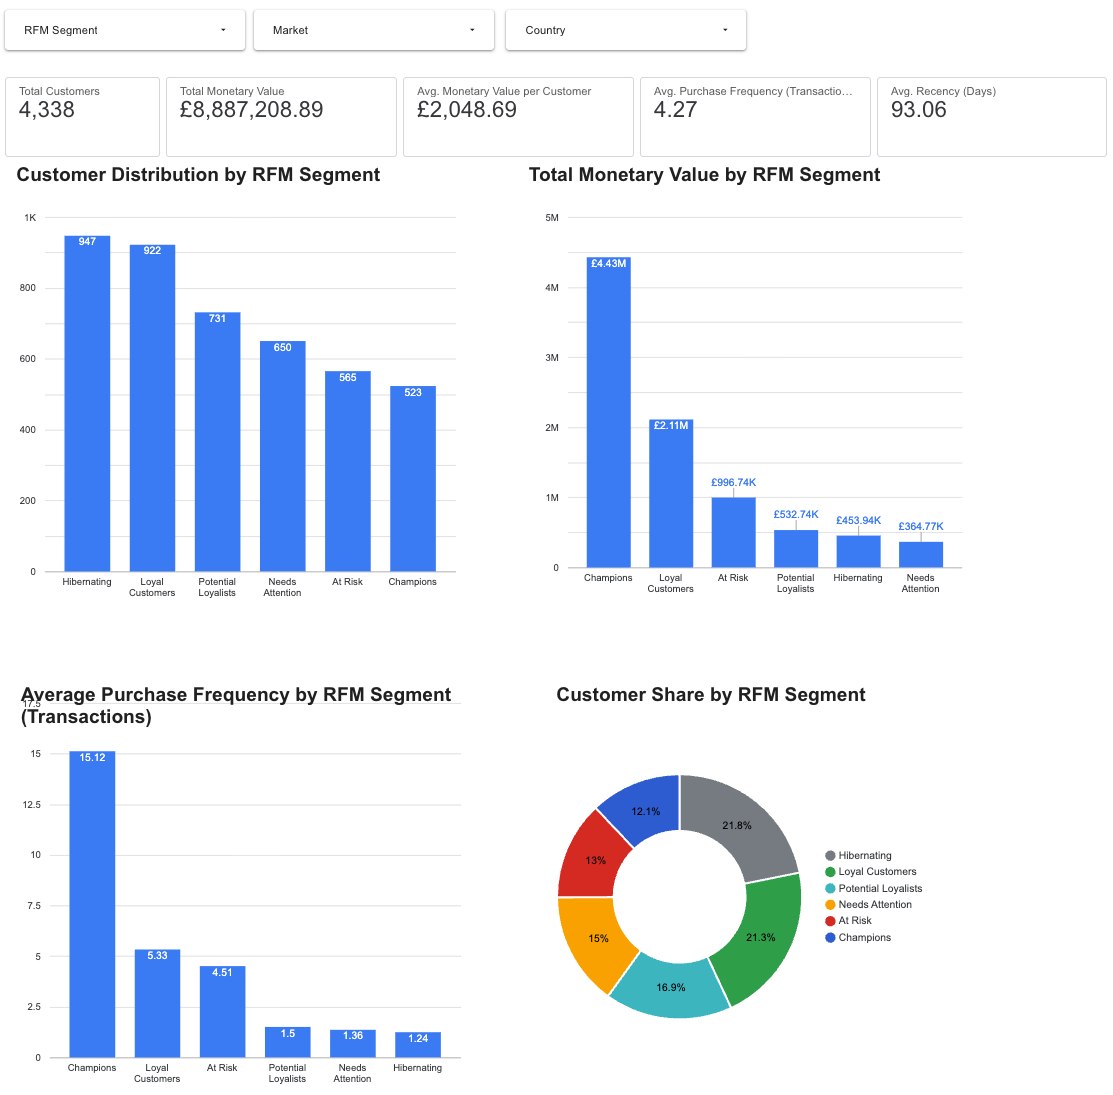

**Figure 8. Final customer segmentation dashboard – segment profiles and geographic customer distribution.**

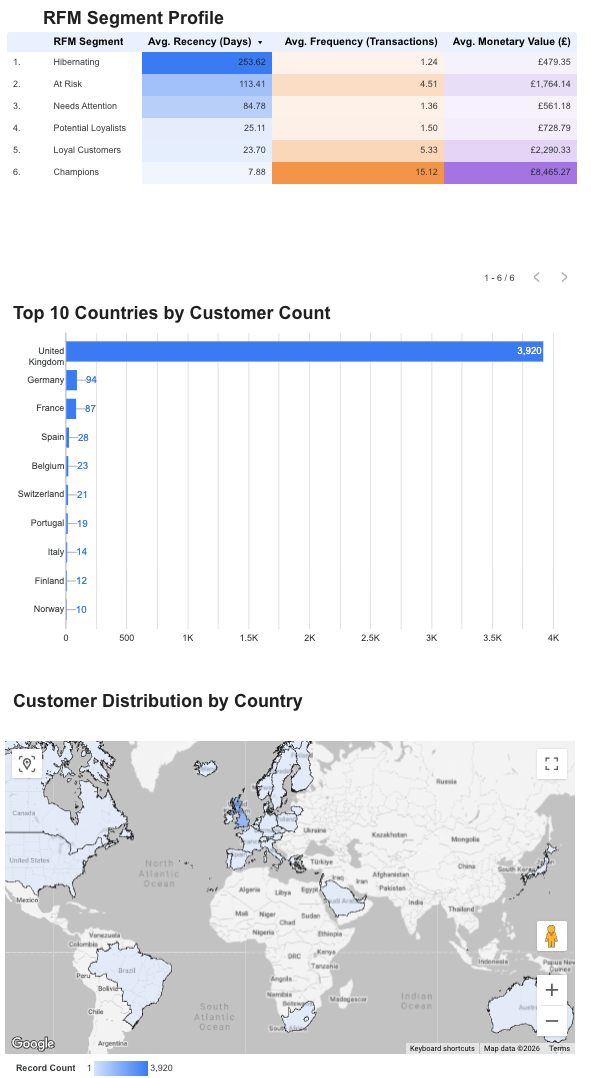

The completed dashboard brings together the main results of the RFM analysis in a format that can be explored from both a customer-value and behavioural perspective. The segment profiles show a clear contrast between customer volume and economic contribution. Champions account for 523 customers but generate approximately £4.43 million in monetary value, with the highest average purchase frequency at 15.12 transactions. In comparison, Hibernating is the largest segment with 947 customers, yet its average frequency is only 1.24 transactions and its average monetary value is £479.35 per customer.

Geographic distribution is similarly concentrated. Of the 4,338 customers represented in the dashboard, 3,920 are located in the United Kingdom, while Germany and France are the next largest markets with 94 and 87 customers respectively. The combination of the country ranking and geographic map makes this imbalance visible while retaining the broader international context.

Rather than treating these results as static outputs, the dashboard allows the analysis to be narrowed by RFM segment, market, and country. This provides a practical link between the analytical work and marketing decision-making, since customer groups with different purchasing patterns and levels of value can be examined separately. These differences form the basis for the marketing recommendations developed in the next section.

**Interactive Dashboard:** [Open the Data Studio Customer Segmentation Dashboard](https://datastudio.google.com/reporting/324f4900-d9ae-4bcd-a2e3-67e738de0c4f/page/K105F)

# 8. Marketing Recommendations

The RFM analysis identified customer groups with substantially different levels of recency, purchase frequency, and monetary value. These differences suggest that a single marketing approach would not be equally appropriate across the customer base. The recommendations below therefore use the segment profiles identified in the analysis to define different priorities for retention, customer development, and reactivation.

The proposed actions should be treated as decision-support recommendations rather than measured campaign outcomes. The transactional dataset shows how customers have behaved, but it does not contain campaign response data that would demonstrate which intervention will be most effective. The proposed strategies would therefore need to be tested and monitored after implementation.

### 8.1 Retention and Value Protection

**Champions** are the strongest value segment in the analysis. The 523 customers in this group generated approximately £4.43 million and recorded an average purchase frequency of 15.12 transactions, considerably above every other segment. Their average recency of 7.88 days also indicates very recent activity. The marketing priority for this group should therefore be retention rather than aggressive discounting. Early access to new products, recognition benefits, exclusive offers, and personalized product recommendations could reinforce the relationship while protecting the value already generated by these customers.

**Loyal Customers** represent a broader retention opportunity. This group contains 922 customers, contributes approximately £2.11 million, and averages 5.33 transactions per customer. A loyalty programme based on repeat purchasing, together with relevant cross-selling recommendations, could encourage continued engagement and potentially move some of these customers towards Champion behaviour. Promotions for this group should reward continued activity without relying unnecessarily on broad price reductions.

### 8.2 Customer Development

The **Potential Loyalists** segment contains 731 customers with relatively recent purchasing activity, averaging 25.11 days since their last purchase. However, their average frequency remains low at 1.50 transactions and their average monetary value is £728.79. This combination suggests an opportunity to encourage a second or subsequent purchase. Personalized recommendations based on previous purchases, complementary product suggestions, and limited follow-up offers could be used to increase repeat activity.

**Needs Attention** requires a different approach. Its 650 customers show an average recency of 84.78 days, frequency of 1.36 transactions, and monetary value of £561.18 per customer. Rather than investing heavily in this entire group, marketing activity could focus on reminding customers of relevant products or categories and testing modest incentives to determine whether engagement can be restored. Customer response should then be used to distinguish those who still have development potential from those moving towards inactivity.

### 8.3 Reactivation and Win-Back

The **At Risk** segment deserves particular attention because its customers still represent meaningful historical value. The group contains 565 customers, contributes approximately £996.74K, and averages 4.51 transactions per customer, but the average recency has increased to 113.41 days. A focused win-back campaign could use time-limited incentives, reminders based on previous purchasing behaviour, or personalized re-engagement messages. Because these customers were previously more active than several other segments, recovering even part of this group may be more valuable than treating all inactive customers equally.

**Hibernating** is the largest segment by customer count, with 947 customers, but it has the weakest behavioural profile: average recency is 253.62 days, frequency is 1.24 transactions, and monetary value is £479.35 per customer. This makes intensive retention spending difficult to justify across the entire segment. A lower-cost reactivation approach, such as automated email campaigns or occasional targeted offers, would be more proportionate. Customers who remain unresponsive could subsequently receive less frequent marketing communication, allowing resources to be concentrated on segments with stronger evidence of current or recoverable value.

### 8.4 Recommendation Priorities

The segment analysis suggests that marketing resources should not be distributed according to customer volume alone. **Champions and Loyal Customers** should receive the strongest retention focus because they currently account for the greatest customer value. **Potential Loyalists** provide a clear development opportunity, while **At Risk** customers justify targeted win-back activity because of their previous purchasing frequency and monetary contribution.

Needs Attention and Hibernating customers should be approached more selectively. Their lower current engagement makes lower-cost testing more appropriate before additional resources are committed. This prioritisation creates a direct link between the RFM decision-support system and the allocation of marketing effort.

# 9. Implementation Plan

The marketing recommendations can be introduced through a phased six-month implementation plan. Rather than activating all initiatives at once, the proposed sequence gives priority to the customer groups that currently contribute the greatest value, followed by development and reactivation activities for segments with different behavioural profiles. This also allows campaign-response data to be collected and used to refine later decisions.

The plan should be treated as a proposed business implementation rather than a prediction of future performance. The Online Retail dataset does not contain campaign costs or response data, so the timeline, budget allocation, and expected outcomes presented in this section represent planning assumptions informed by the RFM findings.

### 9.1 Marketing Initiatives, Timeline and Expected Outcomes

| Phase | Timing | Priority Segment(s) | Marketing Initiative | Expected Outcome |
|---|---|---|---|---|
| **1. Retention** | Month 1 | Champions and Loyal Customers | Introduce recognition and loyalty initiatives, personalized product recommendations, early-access offers, and relevant cross-selling communications. | Maintain engagement and customer value among the strongest-performing segments while encouraging continued repeat purchasing. |
| **2. Customer Development** | Months 2–3 | Potential Loyalists | Use personalized follow-up communications, complementary product recommendations, and selected incentives to encourage another purchase. | Increase repeat purchasing and support progression towards more loyal customer behaviour. |
| **3. Selective Engagement** | Months 2–3 | Needs Attention | Test targeted reminders and modest incentives with selected customers rather than applying high-cost promotions across the entire segment. | Identify customers who can be re-engaged before committing additional marketing resources. |
| **4. Win-Back** | Months 3–4 | At Risk | Run targeted reactivation campaigns using personalized messages, previous purchasing behaviour, and controlled time-limited incentives. | Recover customers with meaningful previous purchasing activity and reduce further movement towards inactivity. |
| **5. Low-Cost Reactivation** | Months 4–5 | Hibernating | Use automated re-engagement communications and occasional targeted offers, with reduced communication for customers who remain inactive. | Test whether inactive customers can be recovered while controlling the cost of reactivation activity. |
| **6. Evaluation and Refinement** | Month 6 | All Segments | Compare campaign responses and changes in purchasing behaviour across segments and review the targeting rules used in the RFM decision-support system. | Identify the initiatives that justify continued investment and use the resulting evidence to refine future campaigns and resource allocation. |

The sequence does not imply that marketing activity for one segment must stop when the next phase begins. Instead, the phases indicate when each initiative would be introduced and evaluated. Retention activity starts with Champions and Loyal Customers because they currently provide the strongest monetary contribution, while more selective and lower-cost approaches are used for segments showing weaker current engagement.

The six-month pilot would also address an important limitation of the present analysis. The transactional data can identify differences in customer behaviour, but it cannot show how customers will respond to a particular marketing intervention. Recording campaign exposure and subsequent customer behaviour during implementation would provide the additional evidence needed to evaluate and improve these strategies.

### 9.2 Budget Allocation

As the dataset provides no information on marketing costs or an available campaign budget, the implementation plan uses a percentage allocation rather than assuming a monetary amount. The proposed distribution reflects both the current value of each segment and the type of intervention recommended.

| Marketing Priority | Segment(s) | Proposed Budget Allocation | Rationale |
|---|---|---:|---|
| **Retention and Value Protection** | Champions and Loyal Customers | **40%** | These segments currently make the strongest monetary contribution. Investment should focus on retention, loyalty, personalization, and maintaining repeat purchasing. |
| **Customer Development** | Potential Loyalists | **20%** | Recent purchasing behaviour provides an opportunity to encourage additional transactions and develop longer-term loyalty. |
| **Win-Back** | At Risk | **20%** | These customers have meaningful previous purchasing activity, making targeted reactivation a potentially valuable use of marketing resources. |
| **Selective Engagement** | Needs Attention | **10%** | Lower current engagement supports a more controlled approach in which campaigns are tested before further investment is committed. |
| **Low-Cost Reactivation** | Hibernating | **5%** | Despite being the largest segment by customer count, its weak recency and frequency profile does not support intensive marketing expenditure. |
| **Testing and Measurement Reserve** | All Segments | **5%** | Reserved for campaign testing, performance measurement, and refinement of targeting decisions during the pilot. |
| **Total** |  | **100%** |  |

This allocation deliberately does not follow customer volume. Hibernating contains the largest number of customers, whereas Champions and Loyal Customers receive the greatest share of the proposed budget because their purchasing behaviour and monetary contribution indicate considerably higher current value. The allocation therefore uses the RFM results to guide where marketing resources may have greater strategic importance.

The percentages are planning assumptions rather than an optimized budget derived from campaign-response data. During the six-month pilot, actual campaign costs and results should be recorded so that future allocation decisions can be based on measured performance rather than the initial RFM profiles alone.

### 9.3 Performance Measurement

The expected outcomes defined in the implementation plan should be evaluated using measures that can be compared across the RFM segments. The current analysis provides a baseline for recency, frequency, monetary value, and customer counts, while the implementation phase would add campaign-response data that is not available in the original dataset.

| Strategy | Main KPI(s) | What Would Be Evaluated |
|---|---|---|
| **Retention and Value Protection** | Repeat purchase rate, purchase frequency, monetary value | Whether Champions and Loyal Customers remain active and continue to generate strong customer value. |
| **Customer Development** | Repeat purchase rate, purchase frequency, segment movement | Whether Potential Loyalists make additional purchases and progress towards stronger RFM profiles. |
| **Selective Engagement** | Reactivation rate, recency, campaign response rate | Whether Needs Attention customers respond to targeted interventions and return to purchasing activity. |
| **Win-Back** | Reactivation rate, recency, recovered monetary value | Whether At Risk customers return after the campaign and generate subsequent purchasing value. |
| **Low-Cost Reactivation** | Reactivation rate, campaign cost per reactivated customer | Whether Hibernating customers can be recovered at a cost that justifies continued marketing activity. |
| **Overall Programme** | Segment distribution, monetary value by segment, campaign return on investment (once campaign cost data are available) | Whether the combined initiatives improve the composition and value of the customer base relative to the initial RFM baseline. |

Performance should be reviewed throughout the six-month pilot rather than only at its conclusion. Campaign exposure and response should be recorded at customer level where appropriate, allowing subsequent purchases to be compared with the original RFM baseline. The dashboard could then be refreshed periodically to show whether customers are becoming more active, moving between segments, or remaining inactive.

No numerical improvement targets are assigned at this stage because the dataset contains historical transactions but no previous campaign-response or marketing-cost data from which defensible targets could be estimated. Initial campaign results would provide a basis for establishing future benchmarks and adjusting both the strategies and their budget allocation.

### 9.4 Ethical, Privacy and Responsible Use Considerations

The segmentation developed in this project uses purchasing behaviour and geographic information to support marketing decisions. Although customers are represented by CustomerID rather than by name, the resulting profiles still describe individual purchasing behaviour. In a real business environment, access to this information should therefore be limited to legitimate purposes, while unnecessary personal data should be excluded from the analytical process. The use and retention of customer-level information would also need to follow the organisation's data protection policies and any applicable privacy requirements.

There are also limitations to how the analytical results should be used. RFM segments and K-Means clusters describe patterns found in historical transactions, but they do not explain why a customer behaved in a particular way or guarantee how that customer will respond to a future campaign. For this reason, the segmentation should support marketing decisions rather than make them automatically. Human review remains important when deciding how different groups are approached, particularly where a campaign could result in customers receiving substantially different treatment. The dataset also contains no demographic attributes that would support a broader assessment of fairness across customer groups. Monitoring segment performance and campaign outcomes over time would therefore be an important part of responsible use if the proposed decision-support system were implemented.

# 10. Conclusion

This project examined how transactional retail data can be transformed into customer-level information that supports marketing decisions. After preparing and validating the Online Retail dataset, RFM analysis was used to distinguish customers according to how recently they purchased, how frequently they returned, and how much monetary value they generated. The resulting segmentation identified six customer groups with clearly different behavioural and economic profiles. An unsupervised K-Means analysis was then applied to the same RFM variables as a separate data-driven perspective. The four-cluster solution distinguished inactive, broader mainstream, high-value active, and extreme high-value customer patterns, while the rule-based RFM segments retained greater granularity for marketing decisions.

One of the most important findings is that customer volume does not necessarily reflect customer value. Champions represent 523 customers but contribute approximately £4.43 million in monetary value and show the highest average purchase frequency, while Hibernating is the largest segment with 947 customers but displays much weaker recency, frequency, and monetary characteristics. The geographic analysis also revealed a strong concentration in the United Kingdom, which accounts for 3,920 of the 4,338 customers in the final customer-level dataset.

The Data Studio dashboard turns these results into an interactive decision-support view rather than leaving the analysis as a collection of Python outputs. Segment, market, and country filters allow different customer groups to be examined separately, while the RFM profiles provide a basis for prioritising retention, customer development, and reactivation initiatives. The proposed implementation plan extends this analysis into a six-month marketing pilot with differentiated initiatives, budget priorities, and performance measures.

There are limitations to what can be concluded from the available data. The dataset describes historical purchasing behaviour but does not include campaign exposure, marketing costs, customer demographics, or response data. This also limits the business measures that can be estimated reliably. Customer lifetime value would require assumptions about future purchasing behaviour and retention, while a formal churn rate would require a defined observation and inactivity period. Similarly, the revenue impact of targeted campaigns cannot be measured without campaign exposure, response, and cost data. The decision-support dashboard therefore focuses on directly observable measures such as recency, purchase frequency, monetary value, and customer segment composition. The proposed marketing actions remain recommendations to be tested rather than demonstrated outcomes, and future campaign results could be incorporated into the decision-support process to evaluate which interventions generate measurable customer and business value.

Overall, the project demonstrates how customer analytics, unsupervised machine learning, and interactive visualisation can be combined to support marketing decision-making. RFM does not explain every aspect of customer behaviour, but in this case it provides a practical foundation for distinguishing customer priorities and directing marketing resources more selectively.